# Machine Learning surpervisé KNN : Song to Song

# **Import de librairies**

In [14]:
# Importation de la bibliothèque pandas sous l'alias 'pd'
# pandas permet de manipuler des structures de données comme les DataFrames (tableaux de données)
import pandas as pd

# Importation de la bibliothèque numpy sous l'alias 'np'
# numpy est utilisée pour effectuer des opérations numériques efficaces sur des tableaux et matrices
import numpy as np

# Importation de la bibliothèque matplotlib.pyplot sous l'alias 'plt'
# matplotlib.pyplot sert à créer des graphiques et des visualisations simples (courbes, histogrammes, etc.)
import matplotlib.pyplot as plt

# Importation de la bibliothèque seaborn sous l'alias 'sns'
# seaborn permet de réaliser des visualisations statistiques avancées et est basée sur matplotlib
import seaborn as sns

# Importation de la bibliothèque requests
# requests est utilisée pour effectuer des requêtes HTTP (par exemple, pour récupérer des données depuis internet)
import requests

# Importation de la fonction tqdm depuis le module tqdm
# tqdm permet d'afficher une barre de progression lors de l'exécution de boucles, utile pour le suivi de tâches longues
from tqdm import tqdm

import time


"""
Raisonnement et méthode :
- On importe ici les principales bibliothèques utilisées en data science et data visualisation en Python.
- pandas (pd) : pour manipuler et analyser des données tabulaires (DataFrames).
- numpy (np) : pour gérer des calculs numériques rapides sur des tableaux multidimensionnels.
- matplotlib.pyplot (plt) : pour créer des visualisations de base (graphiques, courbes, etc.).
- seaborn (sns) : pour des visualisations statistiques plus avancées, avec une syntaxe simplifiée, basée sur matplotlib.
- requests : pour effectuer des requêtes HTTP, souvent utilisé pour récupérer des données depuis des API ou des sites web.
- tqdm : pour afficher des barres de progression lors de l'exécution de boucles, ce qui améliore le suivi de l'avancement lors du traitement de grandes quantités de données.

Fonctionnement des fonctions utilisées :
- import ... as ... : permet d'importer une bibliothèque et de lui donner un alias pour simplifier son utilisation dans le code.
- from ... import ... : permet d'importer une fonction ou une classe spécifique depuis un module, ici tqdm depuis tqdm, pour l'utiliser directement sans préfixe.

Respect de la norme PEP-8 :
- Les imports sont regroupés et organisés par ordre logique (bibliothèques standards, puis tierces).
- Les alias utilisés (pd, np, plt, sns) sont conventionnels et facilitent la lecture du code.
- Les commentaires sont clairs, concis et explicatifs pour chaque import.
"""


"\nRaisonnement et méthode :\n- On importe ici les principales bibliothèques utilisées en data science et data visualisation en Python.\n- pandas (pd) : pour manipuler et analyser des données tabulaires (DataFrames).\n- numpy (np) : pour gérer des calculs numériques rapides sur des tableaux multidimensionnels.\n- matplotlib.pyplot (plt) : pour créer des visualisations de base (graphiques, courbes, etc.).\n- seaborn (sns) : pour des visualisations statistiques plus avancées, avec une syntaxe simplifiée, basée sur matplotlib.\n- requests : pour effectuer des requêtes HTTP, souvent utilisé pour récupérer des données depuis des API ou des sites web.\n- tqdm : pour afficher des barres de progression lors de l'exécution de boucles, ce qui améliore le suivi de l'avancement lors du traitement de grandes quantités de données.\n\nFonctionnement des fonctions utilisées :\n- import ... as ... : permet d'importer une bibliothèque et de lui donner un alias pour simplifier son utilisation dans le cod

# **Chargement du dataset**

In [15]:
# Import des bibliothèques nécessaires
import pandas as pd
from pathlib import Path

# =============================================================================
# SOLUTION 4 : Avec gestion des erreurs (PLUS ROBUSTE)
# =============================================================================

def charger_dataset_spotify():
    """
    Charge le dataset Spotify en testant plusieurs emplacements possibles.
    
    Returns:
        pd.DataFrame: DataFrame contenant les données Spotify
    
    Raises:
        FileNotFoundError: Si aucun fichier n'est trouvé dans les emplacements testés
    """
    
    # Liste des chemins possibles à tester
    # Path.cwd() retourne le répertoire de travail actuel (où se trouve le script)
    # Path.home() retourne le répertoire utilisateur (/Users/username sur tous les systèmes)
    # L'opérateur "/" avec pathlib fonctionne sur tous les systèmes d'exploitation
    chemins_possibles = [
        # Chemin relatif depuis le script Python courant
        Path.cwd() / "Datasets" / "df_concat_tagged.csv",
        
        # Chemin depuis le répertoire parent du script
        # .parent remonte d'un niveau dans l'arborescence
        Path.cwd().parent / "Datasets" / "df_concat_tagged.csv",
        
        # Chemin absolu depuis le répertoire utilisateur (Mac)
        Path.home() / "Documents" / "Cours" / "Wild_Code_School" / "Semaine_8_Visualisation_interactive_et_Pandas_approfondi" / "Projet_2" / "Projet_2_local" / "Datasets" / "df_concat_tagged.csv",
        
        # Chemin absolu alternatif pour différentes configurations
        Path.home() / "Documents" / "Cours" / "Wild_Code_School" / "Semaine_8_Visualisation_interactive_&_Pandas_approfondi" / "Projet_2" / "Projet_2_local" / "Datasets" / "df_concat_tagged.csv",
    ]
    
    # Parcours séquentiel des chemins jusqu'à trouver le fichier
    for chemin in chemins_possibles:
        # Path.exists() retourne True si le fichier existe, False sinon
        if chemin.exists():
            try:
                # pd.read_csv() charge le fichier CSV en DataFrame pandas
                # Paramètre chemin : Path object ou string du fichier à charger
                df = pd.read_csv(chemin)
                
                # Affichage du succès avec le chemin utilisé
                print(f"✅ Dataset chargé avec succès depuis : {chemin}")
                
                # Retour du DataFrame chargé
                return df
                
            except Exception as e:
                # Capture de toute exception lors de la lecture du fichier
                # (erreurs de format, permissions, corruption, etc.)
                print(f"❌ Erreur lors du chargement de {chemin}: {e}")
                
                # continue passe à l'itération suivante de la boucle
                continue
    
    # Si aucun fichier n'a été trouvé dans tous les chemins testés
    # raise lève une exception personnalisée
    raise FileNotFoundError("❌ Aucun dataset Spotify trouvé dans les emplacements testés")


# =============================================================================
# UTILISATION DE LA FONCTION
# =============================================================================

# try/except pour gérer l'exception potentielle de la fonction
try:
    # Appel de la fonction qui retourne le DataFrame chargé
    df = charger_dataset_spotify()
    
    # Vérification optionnelle : affichage des informations du DataFrame
    print(f"📊 Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")
    
except FileNotFoundError as e:
    # Gestion spécifique de l'erreur de fichier non trouvé
    print(e)
    
    # Arrêt du programme ou définition d'un DataFrame vide selon vos besoins
    df = None

except Exception as e:
    # Gestion de toute autre exception non prévue
    print(f"❌ Erreur inattendue : {e}")
    df = None


✅ Dataset chargé avec succès depuis : c:\Users\beber\Documents\Cours\Wild_Code_School\Semaine_8_Visualisation_interactive_&_Pandas_approfondi\Projet_2\Projet_2_local\Datasets\df_concat_tagged.csv
📊 Dataset chargé : 5403 lignes, 18 colonnes


In [16]:
df.head()

,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,time_signature,valence,genre,tags_humeur,tags_activité
0,Manu Chao,Bongo Bong,00SmB7n85SKROGjybsyq5i,68,0.944000,0.755,158427,0.545,0.000118,0.1440,-10.027,0.0646,149.807,4/4,0.964,variété française,#joyeux,#dance/#fête
1,Mylène Farmer,Désenchantée,01ugCDMaqFgnjKtXl0O2CE,34,0.001900,0.614,322760,0.655,0.126000,0.0844,-11.744,0.0297,125.905,4,0.342,variété française,#energique,#dance/#fête
2,Daft Punk,Superheroes / Human After All / Rock'n Roll,029O4HWI1pVXLfFdfQd1Jb,45,0.000045,0.487,341107,0.723,0.383000,0.8190,-11.148,0.1430,138.007,4/4,0.391,variété française,#energique,#sport/#cardio
3,Daniel Lavoie,À boire ! - Live,039VlTNI7azq5YaNTehzdp,8,0.840000,0.322,93627,0.188,0.001750,0.1150,-16.733,0.0395,65.949,4/4,0.276,variété française,#energique,#meditation/#yoga
4,Georges Brassens,Chanson pour l'auvergnat,03i4HQaxKuef4sNUTB3txK,32,0.895000,0.576,184267,0.151,0.000000,0.1180,-13.329,0.2620,200.772,3/4,0.744,variété française,#energique,#dance/#fête


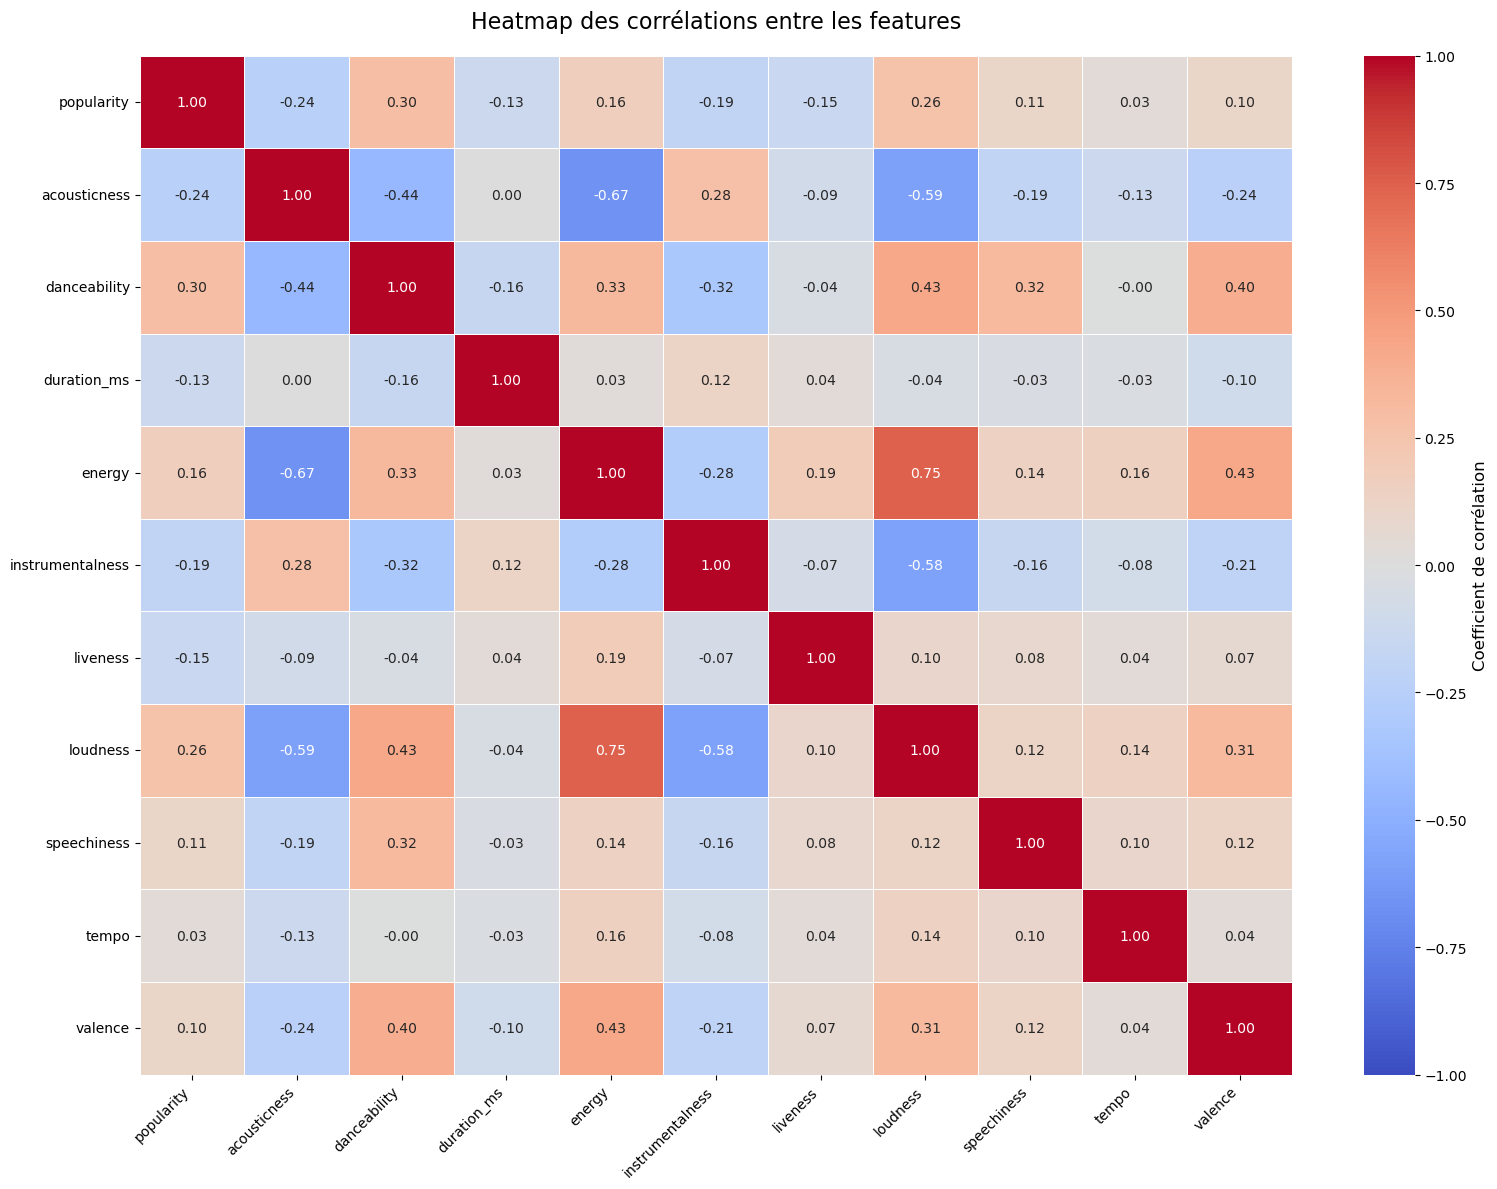

In [17]:

# Sélection uniquement des colonnes numériques pour la corrélation
# Cela exclut les colonnes de texte qui ne peuvent pas être corrélées numériquement
df_numeric = df.select_dtypes(include=['float64', 'int64'])

# Calcul de la matrice de corrélation
# La méthode .corr() calcule les coefficients de corrélation de Pearson par défaut
correlation_matrix = df_numeric.corr()

# Configuration de la figure matplotlib avec une taille appropriée
plt.figure(figsize=(16, 12))  # Ajustez la taille selon le nombre de variables

# Création de la heatmap avec seaborn
# vmin et vmax définissent l'échelle de couleurs (typiquement -1 à 1 pour des corrélations)
# annot=True affiche les valeurs de corrélation dans chaque cellule
# cmap définit la palette de couleurs (ici 'coolwarm' montre les corrélations négatives en bleu et positives en rouge)
# fmt='.2f' limite l'affichage à 2 décimales
# linewidths ajoute une fine ligne blanche entre les cellules pour améliorer la lisibilité
heatmap = sns.heatmap(correlation_matrix, 
                      annot=True,  # Afficher les valeurs
                      fmt='.2f',  # Format à 2 décimales
                      cmap='coolwarm',  # Palette de couleurs
                      linewidths=0.5,  # Lignes blanches entre les cellules
                      vmin=-1,  # Valeur minimale de l'échelle
                      vmax=1)  # Valeur maximale de l'échelle

# Ajout de titres et ajustements
plt.title('Heatmap des corrélations entre les features', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)  # Rotation des étiquettes x pour éviter le chevauchement
plt.yticks(fontsize=10)

# Ajout d'une barre de couleur qui explique l'échelle
cbar = heatmap.collections[0].colorbar
cbar.ax.set_ylabel('Coefficient de corrélation', fontsize=12)

# Ajustement automatique pour que tout soit visible
plt.tight_layout()

# Affichage de la heatmap
plt.show()

# Si vous souhaitez enregistrer l'image
# plt.savefig('heatmap_correlation.png', dpi=300, bbox_inches='tight')


In [18]:
# Corrélations :

# HUMEUR

    # Valence :
        # Valence/energy : 0,44

    # acoustisness :
        # acoustisness/energy : -0,66
        # acoustiness/loudness : -0,59

    # loudness :
        #loudness/acoustisness : -0,59
        #loudness/energy : 0.76 
        #loudness/instrumentalness : -0,68

# ACTIVITE

    # danceabily:
        # danceabilty/acoustisness : -0,45
        # danceabilty/loudness : 0,43

    # energy :
        #energy/acoustisness : -0,66
        #energy/loudness : 0,76
        #energy/valence : 0,44

    #instrumentalness :
        #instrumentalness/loudness : -0,68
    
    #tempo : 
        #tempo/energy : 0,15



# TOP corrélation : 
    #loudness/energy : 0.76
    #energy/loudness : 0,76
    #loudness/instrumentalness : -0,68
    #instrumentalness/loudness : -0,68
    # acoustiness/loudness : -0,59
    #loudness/acoustisness : -0,59

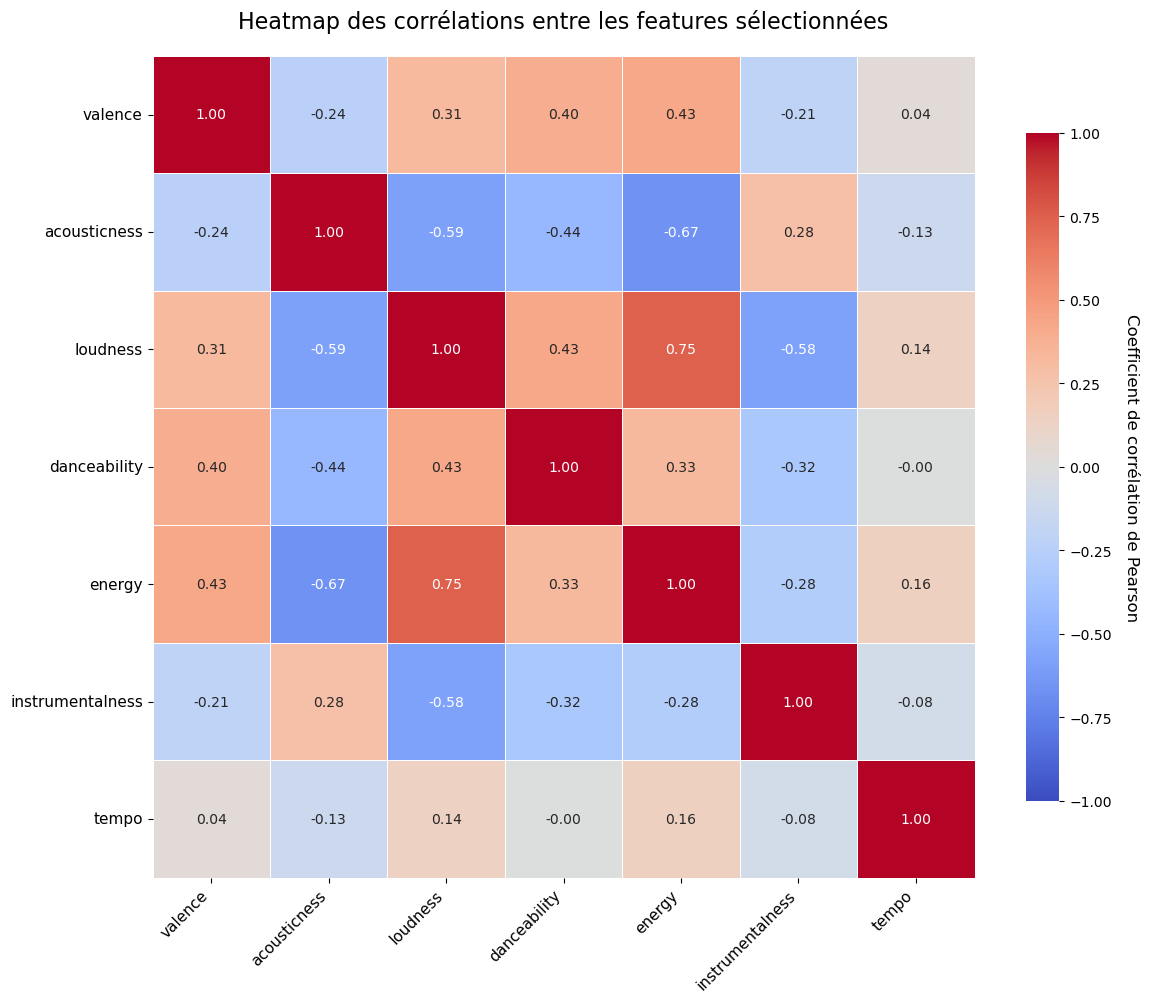

=== ANALYSE DES CORRÉLATIONS ===
Nombre de features analysées : 7
Taille de l'échantillon : 5403 observations

=== TOP 5 DES CORRÉLATIONS LES PLUS FORTES ===
energy <-> loudness: 0.747
energy <-> acousticness: -0.666
loudness <-> acousticness: -0.589
instrumentalness <-> loudness: -0.583
danceability <-> acousticness: -0.444

=== CORRÉLATIONS FAIBLES (|r| < 0.3) ===
Nombre de paires faiblement corrélées : 10
instrumentalness <-> acousticness: 0.280
instrumentalness <-> energy: -0.279
acousticness <-> valence: -0.240
instrumentalness <-> valence: -0.207
tempo <-> energy: 0.155
tempo <-> loudness: 0.143
tempo <-> acousticness: -0.126
tempo <-> instrumentalness: -0.081
tempo <-> valence: 0.038
tempo <-> danceability: -0.004


In [19]:
# Définition des colonnes à conserver pour l'analyse de corrélation
# Liste des features musicales sélectionnées (je corrige "acoustisness" en "acousticness")
selected_features = [
    'valence',         # Mesure de la positivité émotionnelle de la musique (0.0 à 1.0)
    'acousticness',    # Mesure du caractère acoustique de la musique (0.0 à 1.0)
    'loudness',        # Volume général de la piste en décibels (dB)
    'danceability',    # Mesure de la facilité à danser sur cette musique (0.0 à 1.0)
    'energy',          # Mesure de l'intensité et de la puissance perçue (0.0 à 1.0)
    'instrumentalness', # Probabilité que la piste soit instrumentale (0.0 à 1.0)
    'tempo'            # Tempo estimé de la piste en battements par minute (BPM)
]

# Sélection des colonnes spécifiées dans le DataFrame
# Cette opération crée un nouveau DataFrame avec seulement les colonnes voulues
df_selected = df[selected_features].copy()

# Suppression des lignes contenant des valeurs manquantes
# dropna() enlève toutes les lignes qui ont au moins une valeur NaN
# Ceci garantit que le calcul de corrélation fonctionne correctement
df_selected = df_selected.dropna()

# Calcul de la matrice de corrélation de Pearson
# corr() calcule les coefficients de corrélation entre toutes les paires de variables
# Par défaut, utilise la méthode de Pearson qui mesure les relations linéaires
correlation_matrix = df_selected.corr()

# Configuration de la taille de la figure matplotlib
# figsize=(12, 10) définit la largeur et hauteur en pouces
# Une taille adaptée pour 7 variables permet une bonne lisibilité
plt.figure(figsize=(12, 10))

# Création de la heatmap avec seaborn
# sns.heatmap() crée une carte de chaleur des corrélations
heatmap = sns.heatmap(
    correlation_matrix,    # Données à visualiser (matrice de corrélation)
    annot=True,           # annot=True affiche les valeurs numériques dans chaque cellule
    fmt='.2f',            # fmt='.2f' formate les nombres à 2 décimales
    cmap='coolwarm',      # Palette de couleurs : bleu pour négatif, rouge pour positif
    linewidths=0.5,       # Largeur des lignes séparant les cellules (en points)
    square=True,          # square=True force les cellules à être carrées
    vmin=-1,              # Valeur minimale de l'échelle de couleurs
    vmax=1,               # Valeur maximale de l'échelle de couleurs
    center=0,             # center=0 centre la palette de couleurs sur zéro
    cbar_kws={'shrink': 0.8}  # Paramètres de la barre de couleur (réduction à 80%)
)

# Configuration du titre principal du graphique
# title() ajoute un titre avec une police de taille 16 et un espacement de 20 points
plt.title('Heatmap des corrélations entre les features sélectionnées', 
          fontsize=16, pad=20)

# Rotation des étiquettes de l'axe x pour éviter le chevauchement
# xticks() configure l'affichage des étiquettes de l'axe x
# rotation=45 fait tourner les labels de 45 degrés
# ha='right' aligne horizontalement les labels à droite
plt.xticks(rotation=45, ha='right', fontsize=11)

# Configuration des étiquettes de l'axe y
# yticks() configure l'affichage des étiquettes de l'axe y
plt.yticks(fontsize=11, rotation=0)

# Configuration de la barre de couleur (colorbar)
# Récupération de l'objet colorbar pour le personnaliser
cbar = heatmap.collections[0].colorbar
# Ajout d'un label explicatif sur la barre de couleur
cbar.ax.set_ylabel('Coefficient de corrélation de Pearson', 
                   fontsize=12, rotation=270, labelpad=20)

# Ajustement automatique de la mise en page
# tight_layout() optimise l'espacement pour éviter que les éléments se chevauchent
plt.tight_layout()

# Affichage du graphique à l'écran
# show() rend le graphique visible dans l'interface utilisateur
plt.show()

# Option pour sauvegarder le graphique (décommentez si nécessaire)
# plt.savefig('heatmap_features_selected.png', dpi=300, bbox_inches='tight')

# Affichage des statistiques descriptives de la matrice de corrélation
print("=== ANALYSE DES CORRÉLATIONS ===")
print(f"Nombre de features analysées : {len(selected_features)}")
print(f"Taille de l'échantillon : {len(df_selected)} observations")

# Identification des corrélations les plus fortes (en valeur absolue)
# np.triu() crée un masque triangulaire supérieur pour éviter les doublons
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
# Application du masque pour ne garder que la partie triangulaire inférieure
correlation_matrix_masked = correlation_matrix.mask(mask)

# Conversion en format long pour faciliter l'analyse
# stack() convertit la matrice en série avec index multi-niveau
correlation_pairs = correlation_matrix_masked.stack().reset_index()
correlation_pairs.columns = ['Feature1', 'Feature2', 'Correlation']

# Tri par valeur absolue de corrélation (plus fortes corrélations en premier)
correlation_pairs['Abs_Correlation'] = correlation_pairs['Correlation'].abs()
correlation_pairs_sorted = correlation_pairs.sort_values('Abs_Correlation', 
                                                        ascending=False)

print("\n=== TOP 5 DES CORRÉLATIONS LES PLUS FORTES ===")
# Affichage des 5 corrélations les plus importantes
for i, row in correlation_pairs_sorted.head().iterrows():
    print(f"{row['Feature1']} <-> {row['Feature2']}: {row['Correlation']:.3f}")

print("\n=== CORRÉLATIONS FAIBLES (|r| < 0.3) ===")
# Identification des paires avec corrélations faibles
weak_correlations = correlation_pairs_sorted[
    correlation_pairs_sorted['Abs_Correlation'] < 0.3
]
print(f"Nombre de paires faiblement corrélées : {len(weak_correlations)}")
for i, row in weak_correlations.iterrows():
    print(f"{row['Feature1']} <-> {row['Feature2']}: {row['Correlation']:.3f}")


In [20]:
def creer_tags_manuel(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ajoute deux colonnes :
      - tags_humeur  : #joyeux, #triste, #energique, #calme
      - tags_activité: #dance/#fête, #concentration/#travail,
                       #sport/#cardio, #meditation/#yoga
    """
    # Définition du tag d’humeur
    def tag_humeur(valence, acousticness, loudness):
        if valence >= 0.75:
            return "#joyeux"
        if valence < 0.25:
            return "#triste"
        if loudness >= -20 or acousticness < 0.3:
            return "#energique"
        return "#calme"

    # Définition du tag d’activité
    def tag_activite(danceability, energy, tempo):
        if danceability >= 0.5:
            return "#dance/#fête"
        if energy >= 0.6 or tempo >= 110:
            return "#sport/#cardio"
        if energy >= 0.3:
            return "#concentration/#travail"
        return "#meditation/#yoga"

    # Application ligne par ligne
    df["tags_humeur"] = df.apply(
        lambda r: tag_humeur(r["valence"], r["acousticness"], r["loudness"]), axis=1
    )
    df["tags_activité"] = df.apply(
        lambda r: tag_activite(r["danceability"], r["energy"], r["tempo"]), axis=1
    )

    # Vérification des tags uniques et comptages
    uniques_humeur = df["tags_humeur"].unique().tolist()
    compte_humeur = df["tags_humeur"].value_counts().reset_index()
    compte_humeur.columns = ["tag_humeur", "occurrences"]

    uniques_activite = df["tags_activité"].unique().tolist()
    compte_activite = df["tags_activité"].value_counts().reset_index()
    compte_activite.columns = ["tag_activité", "occurrences"]

    # Affichage des vérifications
    print("Tags d’humeur uniques :", uniques_humeur)
    print("\nRépartition des tags d’humeur :")
    print(compte_humeur)

    print("\nTags d’activité uniques :", uniques_activite)
    print("\nRépartition des tags d’activité :")
    print(compte_activite)

    return df


df_tagged = creer_tags_manuel(df)
df_tagged


Tags d’humeur uniques : ['#joyeux', '#energique', '#triste', '#calme']

Répartition des tags d’humeur :
   tag_humeur  occurrences
0  #energique         3409
1     #triste         1359
2     #joyeux          611
3      #calme           24

Tags d’activité uniques : ['#dance/#fête', '#sport/#cardio', '#meditation/#yoga', '#concentration/#travail']

Répartition des tags d’activité :
              tag_activité  occurrences
0             #dance/#fête         4204
1           #sport/#cardio          737
2  #concentration/#travail          242
3        #meditation/#yoga          220


,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,time_signature,valence,genre,tags_humeur,tags_activité
0,Manu Chao,Bongo Bong,00SmB7n85SKROGjybsyq5i,68,0.944000,0.755,158427,0.545,0.000118,0.1440,-10.027,0.0646,149.807,4/4,0.964,variété française,#joyeux,#dance/#fête
1,Mylène Farmer,Désenchantée,01ugCDMaqFgnjKtXl0O2CE,34,0.001900,0.614,322760,0.655,0.126000,0.0844,-11.744,0.0297,125.905,4,0.342,variété française,#energique,#dance/#fête
2,Daft Punk,Superheroes / Human After All / Rock'n Roll,029O4HWI1pVXLfFdfQd1Jb,45,0.000045,0.487,341107,0.723,0.383000,0.8190,-11.148,0.1430,138.007,4/4,0.391,variété française,#energique,#sport/#cardio
3,Daniel Lavoie,À boire ! - Live,039VlTNI7azq5YaNTehzdp,8,0.840000,0.322,93627,0.188,0.001750,0.1150,-16.733,0.0395,65.949,4/4,0.276,variété française,#energique,#meditation/#yoga
4,Georges Brassens,Chanson pour l'auvergnat,03i4HQaxKuef4sNUTB3txK,32,0.895000,0.576,184267,0.151,0.000000,0.1180,-13.329,0.2620,200.772,3/4,0.744,variété française,#energique,#dance/#fête
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5398,fergie,big girls don't cry (personal),3Q4WeJmzxuDpzMu9QjQqbM,75,0.239000,0.712,268120,0.647,0.000000,0.0955,-4.277,0.0336,113.116,4,0.292,électro/dance,#energique,#dance/#fête
5399,cardi b,i do (feat. sza),1f5PNhkNgUpvDEeZfcIlO1,75,0.270000,0.886,200205,0.473,0.000026,0.0864,-7.338,0.2550,135.065,4,0.438,électro/dance,#energique,#dance/#fête
5400,g-eazy,i mean it,6jmTHeoWvBaSrwWttr8Xvu,75,0.125000,0.712,236480,0.562,0.000000,0.1360,-6.008,0.1290,140.000,4,0.142,électro/dance,#triste,#dance/#fête
5401,shakira,perro fiel (feat. nicky jam),70lnL3QaSOIIyMa2X9aVRL,75,0.187000,0.750,195213,0.760,0.000000,0.0548,-4.836,0.1980,183.817,4,0.893,électro/dance,#joyeux,#dance/#fête


In [21]:
df_tagged.loc[:, ["artist_name", "track_name", "track_id", "genre"]]


,artist_name,track_name,track_id,genre
0,Manu Chao,Bongo Bong,00SmB7n85SKROGjybsyq5i,variété française
1,Mylène Farmer,Désenchantée,01ugCDMaqFgnjKtXl0O2CE,variété française
2,Daft Punk,Superheroes / Human After All / Rock'n Roll,029O4HWI1pVXLfFdfQd1Jb,variété française
3,Daniel Lavoie,À boire ! - Live,039VlTNI7azq5YaNTehzdp,variété française
4,Georges Brassens,Chanson pour l'auvergnat,03i4HQaxKuef4sNUTB3txK,variété française
...,...,...,...,...
5398,fergie,big girls don't cry (personal),3Q4WeJmzxuDpzMu9QjQqbM,électro/dance
5399,cardi b,i do (feat. sza),1f5PNhkNgUpvDEeZfcIlO1,électro/dance
5400,g-eazy,i mean it,6jmTHeoWvBaSrwWttr8Xvu,électro/dance
5401,shakira,perro fiel (feat. nicky jam),70lnL3QaSOIIyMa2X9aVRL,électro/dance


# Machine Learning

## Import des bibliothèques de ML

In [22]:
# Importation de la fonction pour diviser les données en ensembles d'entraînement et de test
from sklearn.model_selection import train_test_split

# Importation de l'encodeur de labels pour transformer les variables cibles catégorielles en entiers
from sklearn.preprocessing import LabelEncoder

# Importation du modèle KNN pour la classification supervisée (prédiction de classes)
from sklearn.neighbors import KNeighborsClassifier

# Importation du modèle KNN pour l'apprentissage non supervisé (recherche de voisins les plus proches sans cible)
from sklearn.neighbors import NearestNeighbors

# Importation de plusieurs métriques d'évaluation depuis le module sklearn.metrics :
# - mean_squared_error : calcule l'erreur quadratique moyenne, principalement utilisée pour évaluer les modèles de régression.
# - r2_score : calcule le coefficient de détermination R², qui mesure la proportion de la variance expliquée par le modèle (pour la régression).
# - accuracy_score : calcule le taux de bonnes classifications, c'est-à-dire la proportion de prédictions correctes sur l'ensemble des échantillons (pour la classification).
# - precision_score : mesure la précision, soit la proportion de prédictions positives correctes parmi toutes les prédictions positives faites par le modèle (précision = vrais positifs / (vrais positifs + faux positifs)), utile pour évaluer la qualité des prédictions positives.
# - f1_score : calcule le score F1, la moyenne harmonique entre la précision et le rappel, utile pour évaluer l'équilibre entre précision et rappel.
# - recall_score : mesure le rappel, soit la proportion de vrais positifs détectés parmi tous les positifs réels (rappel = vrais positifs / (vrais positifs + faux négatifs)).
# - classification_report : génère un rapport détaillé contenant précision, rappel, f1-score et support pour chaque classe.
# - confusion_matrix : construit une matrice de confusion, utile pour visualiser les erreurs de classification (comparaison entre classes prédites et réelles).
# - ConfusionMatrixDisplay : permet d'afficher graphiquement la matrice de confusion pour une meilleure interprétation visuelle.
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, f1_score, recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


# Importation de l'outil de standardisation des données (mise à l'échelle des features pour améliorer les performances des modèles)
from sklearn.preprocessing import StandardScaler

# Importation de l'outil Pipeline pour chaîner plusieurs étapes de prétraitement et de modélisation dans un même objet
from sklearn.pipeline import Pipeline

# Importation du module warnings pour gérer (filtrer, ignorer) les messages d'avertissement lors de l'exécution du code
import warnings


# Features : "valence, energy, danceability, acousticness, tempo, loudness"
# Target : "genre"

In [23]:
# === RECOMMANDATIONS POUR LE MODÈLE MOODIFY ===

# Variables principales : valence, energy, danceability
# Variables secondaires : acousticness, tempo, loudness

In [24]:
df["genre"].unique()

df["genre"].nunique()

# Sélectionne toutes les lignes du DataFrame 'df' et uniquement les colonnes spécifiées :
# - 'valence' : mesure la positivité de la chanson (score de 0 à 1)
# - 'energy' : mesure l'intensité et l'activité perçues (score de 0 à 1)
# - 'danceability' : mesure à quel point un morceau est dansant (score de 0 à 1)
# - 'acousticness' : probabilité qu'un morceau soit acoustique (score de 0 à 1)
# - 'tempo' : tempo de la chanson en battements par minute (BPM)
# - 'loudness' : volume perçu de la chanson (en décibels, dB)
df.loc[:, ['valence', 'energy', 'danceability', 'acousticness', 'tempo', 'loudness', 'instrumentalness']]


,valence,energy,danceability,acousticness,tempo,loudness,instrumentalness
0,0.964,0.545,0.755,0.944000,149.807,-10.027,0.000118
1,0.342,0.655,0.614,0.001900,125.905,-11.744,0.126000
2,0.391,0.723,0.487,0.000045,138.007,-11.148,0.383000
3,0.276,0.188,0.322,0.840000,65.949,-16.733,0.001750
4,0.744,0.151,0.576,0.895000,200.772,-13.329,0.000000
...,...,...,...,...,...,...,...
5398,0.292,0.647,0.712,0.239000,113.116,-4.277,0.000000
5399,0.438,0.473,0.886,0.270000,135.065,-7.338,0.000026
5400,0.142,0.562,0.712,0.125000,140.000,-6.008,0.000000
5401,0.893,0.760,0.750,0.187000,183.817,-4.836,0.000000


## ML supervisé : KNN (k=5, test_size=0.2, metric='euclidean')

In [25]:
# Affiche un titre pour indiquer le début de la section de classification avec KNeighborsClassifier
print("\n--- Classification (KNeighborsClassifier pour prédire 'genre') ---")



--- Classification (KNeighborsClassifier pour prédire 'genre') ---


In [26]:
# Création d'un pipeline de machine learning pour la classification
# Le pipeline enchaîne deux étapes principales :
# 1. 'scaler' : StandardScaler() standardise les features (moyenne 0, écart-type 1)
#    - Cela est crucial pour KNN, car il se base sur des distances : toutes les features doivent être sur la même échelle.
# 2. 'classifier' : KNeighborsClassifier(n_neighbors=5) applique l'algorithme KNN pour la classification
#    - n_neighbors=5 signifie que la classe prédite sera celle la plus fréquente parmi les 5 voisins les plus proches.
#    - Ce paramètre (k=5) est un choix courant, mais il peut être optimisé via validation croisée.
pipeline_knn_clf = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=5, metric='euclidean'))
    ])

In [27]:
# Sélection des features pour la classification avec KNN
# On extrait du DataFrame 'df' les colonnes suivantes :
# - 'valence' : mesure la positivité de la chanson (valeur entre 0 et 1)
# - 'energy' : mesure l'intensité de la chanson (valeur entre 0 et 1)
# - 'danceability' : mesure à quel point la chanson est dansante (valeur entre 0 et 1)
# - 'acousticness' : probabilité que la chanson soit acoustique (valeur entre 0 et 1)
# - 'tempo' : tempo de la chanson en battements par minute (BPM)
# - 'loudness' : volume sonore moyen de la chanson (en décibels)
# Ces colonnes sont sélectionnées car elles sont pertinentes pour caractériser et différencier les genres musicaux.
X_class_KNN = df.loc[:, ['valence', 'energy', 'danceability', 'acousticness', 'tempo', 'loudness']]


In [28]:
# Sélection de la variable cible (target) pour la classification
# Ici, on utilise la colonne 'genre_simplifié' du DataFrame 'df'
y_class_KNN = df['genre']

# Instanciation de l'encodeur de labels
# LabelEncoder va transformer les genres musicaux (catégories textuelles) en entiers
le = LabelEncoder()

# Encodage de la variable cible
# Chaque genre unique est transformé en un entier unique (ex : 'pop' -> 0, 'rock' -> 1, etc.)
# Cela permet de rendre la cible compatible avec les algorithmes de classification de scikit-learn
y_class_KNN_encoded = le.fit_transform(y_class_KNN)

In [29]:
# Affiche la liste des genres et leur numéro attribué
for idx, genre in enumerate(le.classes_):
    print(f"{genre} : {idx}")


classique/opéra : 0
jazz/blues : 1
pop : 2
rap : 3
rock/indie : 4
variété française : 5
électro/dance : 6


In [30]:
genre = le.classes_
genre


array(['classique/opéra', 'jazz/blues', 'pop', 'rap', 'rock/indie',
       'variété française', 'électro/dance'], dtype=object)

In [31]:
# Division des données en ensembles d'entraînement et de test pour la classification KNN

# On utilise train_test_split pour séparer les features (X_class_KNN) et la cible encodée (y_class_KNN_encoded)
# test_size=0.2 : 20% des données seront utilisées pour le test, 80% pour l'entraînement
# random_state=42 : fixe la graine aléatoire pour garantir la reproductibilité des résultats
# stratify=y_class_KNN_encoded : garantit que la proportion de chaque classe (genre) est respectée dans les deux ensembles,
# ce qui est crucial en cas de déséquilibre des classes

X_train_KNN, X_test_KNN, y_train_KNN, y_test_KNN = train_test_split(
    X_class_KNN,                # Features sélectionnées pour la classification
    y_class_KNN_encoded,        # Cible encodée en entiers
    test_size=0.2,              # Pourcentage des données dans l'ensemble de test
    random_state=42,            # Graine pour la reproductibilité
    stratify=y_class_KNN_encoded # Strate sur la cible pour équilibrer les classes dans chaque ensemble
)


In [32]:
# Pour KNN, la méthode .fit() ne construit pas un modèle complexe :
# Elle se contente de stocker les données d'entraînement, car l'algorithme KNN va comparer les nouveaux échantillons
# directement à ces données lors de la prédiction.
pipeline_knn_clf.fit(X_train_KNN, y_train_KNN)

# La méthode .predict() du pipeline :
# - Pour chaque échantillon, calcule la distance entre cet échantillon et tous les points d'entraînement stockés.
# - Sélectionne les k voisins les plus proches (selon la distance choisie, généralement euclidienne).
# - Attribue la classe majoritaire parmi ces voisins comme prédiction.

# Prédictions sur l'ensemble d'entraînement (permet de mesurer l'overfitting)
y_pred_knn_clf_train = pipeline_knn_clf.predict(X_train_KNN)

# Prédictions sur l'ensemble de test (permet d'évaluer la généralisation du modèle)
y_pred_knn_clf_test = pipeline_knn_clf.predict(X_test_KNN)


In [33]:
# Calcul de l'accuracy (taux de bonnes prédictions) sur l'ensemble d'entraînement
accuracy_knn_clf_train = accuracy_score(y_train_KNN, y_pred_knn_clf_train)
# Affichage formaté de l'accuracy d'entraînement avec 4 décimales
print(f"Modèle de Classification (KNN, k=5) - Accuracy sur l'ensemble d'entraînement: {accuracy_knn_clf_train:.4f}")

# Calcul de l'accuracy sur l'ensemble de test
accuracy_knn_clf_test = accuracy_score(y_test_KNN, y_pred_knn_clf_test)
# Affichage formaté de l'accuracy de test avec 4 décimales
print(f"Modèle de Classification (KNN, k=5) - Accuracy sur l'ensemble de test: {accuracy_knn_clf_test:.4f}")


Modèle de Classification (KNN, k=5) - Accuracy sur l'ensemble d'entraînement: 0.6643
Modèle de Classification (KNN, k=5) - Accuracy sur l'ensemble de test: 0.5458


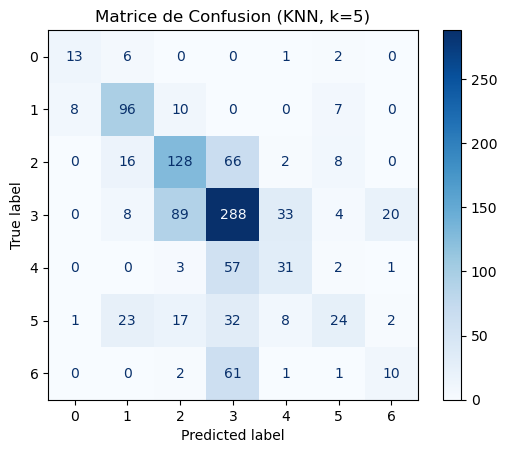

In [34]:
# Calcul de la matrice de confusion pour le modèle KNN sur l'ensemble de test
# La matrice de confusion permet de visualiser le nombre de prédictions correctes et incorrectes pour chaque classe
cm_knn = confusion_matrix(y_test_KNN, y_pred_knn_clf_test)

# Création de l'objet d'affichage pour la matrice de confusion
# ConfusionMatrixDisplay permet de personnaliser et d'afficher facilement la matrice
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn)

# Affichage graphique de la matrice de confusion avec une palette de couleurs bleues pour une meilleure lisibilité
disp_knn.plot(cmap='Blues')

# Ajout d'un titre à la figure pour préciser le modèle et la valeur de k utilisée
plt.title("Matrice de Confusion (KNN, k=5)")

# Affichage de la figure à l'écran
plt.show()


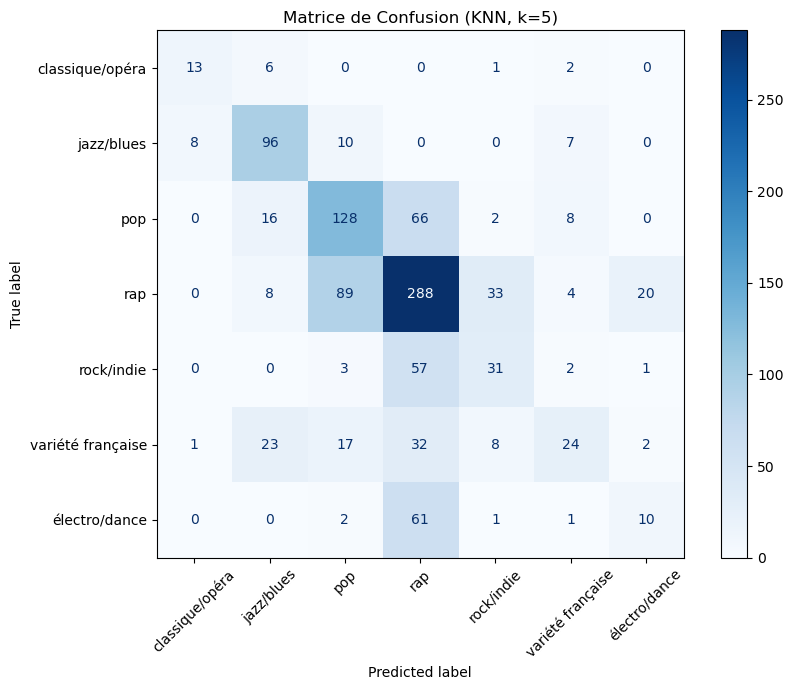

In [35]:
# Calcul de la matrice de confusion pour le modèle KNN sur l'ensemble de test
# La matrice de confusion permet de visualiser le nombre de prédictions correctes et incorrectes pour chaque classe
cm_knn = confusion_matrix(y_test_KNN, y_pred_knn_clf_test)

# Création de l'objet d'affichage avec les noms de genres
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=genre)

# Création d'une figure plus large pour éviter le chevauchement
fig, ax = plt.subplots(figsize=(9, 7))
disp_knn.plot(cmap='Blues', ax=ax, xticks_rotation=45)  # xticks_rotation=45 incline les labels de l'axe x

plt.title("Matrice de Confusion (KNN, k=5)")
plt.tight_layout()  # Ajuste automatiquement les marges pour éviter que les labels soient coupés
plt.show()


In [36]:
# Affiche un titre pour séparer visuellement le rapport de classification dans la console
print("\nRapport de Classification (KNN):")

# Affiche un rapport détaillé sur les performances du modèle KNN pour chaque genre musical (classe)
# classification_report calcule et affiche les métriques suivantes pour chaque classe :
# - precision : proportion de prédictions correctes parmi toutes les prédictions positives pour cette classe
# - recall (rappel) : proportion de prédictions correctes parmi toutes les vraies instances de cette classe
# - f1-score : moyenne harmonique entre la précision et le rappel, mesure globale de la performance
# - support : nombre d'échantillons réels de chaque classe dans l'ensemble de test
# L'argument target_names=genre permet d'afficher les noms des genres au lieu des indices numériques.
# Attention : la variable 'genre' doit contenir la liste ordonnée des noms de genres correspondant à l'encodage utilisé (ex : le.classes_)
print(classification_report(y_test_KNN, y_pred_knn_clf_test, target_names=genre))



Rapport de Classification (KNN):
                   precision    recall  f1-score   support

  classique/opéra       0.59      0.59      0.59        22
       jazz/blues       0.64      0.79      0.71       121
              pop       0.51      0.58      0.55       220
              rap       0.57      0.65      0.61       442
       rock/indie       0.41      0.33      0.36        94
variété française       0.50      0.22      0.31       107
    électro/dance       0.30      0.13      0.19        75

         accuracy                           0.55      1081
        macro avg       0.50      0.47      0.47      1081
     weighted avg       0.53      0.55      0.53      1081



## ML supervisé : KNN (k=7, test_size=0.2, metric='euclidean')


--- Classification (KNeighborsClassifier pour prédire 'genre') ---
Modèle de Classification (KNN, k=7) - Accuracy sur l'ensemble d'entraînement: 0.6546
Modèle de Classification (KNN, k=7) - Accuracy sur l'ensemble de test: 0.5569


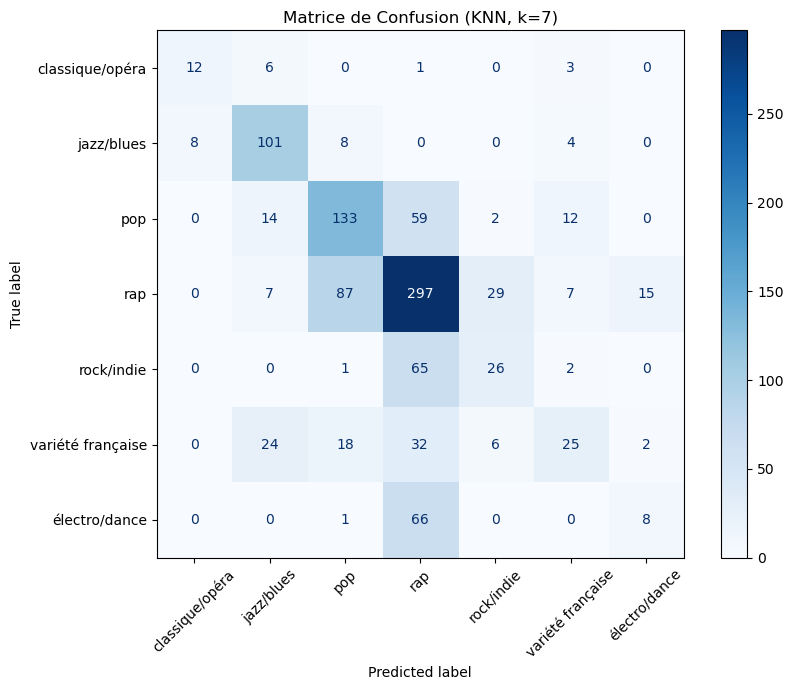


Rapport de Classification (KNN):
                   precision    recall  f1-score   support

  classique/opéra       0.60      0.55      0.57        22
       jazz/blues       0.66      0.83      0.74       121
              pop       0.54      0.60      0.57       220
              rap       0.57      0.67      0.62       442
       rock/indie       0.41      0.28      0.33        94
variété française       0.47      0.23      0.31       107
    électro/dance       0.32      0.11      0.16        75

         accuracy                           0.56      1081
        macro avg       0.51      0.47      0.47      1081
     weighted avg       0.53      0.56      0.53      1081



In [37]:
# Affiche un titre pour indiquer le début de la section de classification avec KNeighborsClassifier
print("\n--- Classification (KNeighborsClassifier pour prédire 'genre') ---")


# Création d'un pipeline de machine learning pour la classification
# Le pipeline enchaîne deux étapes principales :
# 1. 'scaler' : StandardScaler() standardise les features (moyenne 0, écart-type 1)
#    - Cela est crucial pour KNN, car il se base sur des distances : toutes les features doivent être sur la même échelle.
# 2. 'classifier' : KNeighborsClassifier(n_neighbors=7) applique l'algorithme KNN pour la classification
#    - n_neighbors=7 signifie que la classe prédite sera celle la plus fréquente parmi les 5 voisins les plus proches.
#    - Ce paramètre (k=7) est un choix courant, mais il peut être optimisé via validation croisée.
pipeline_knn_clf = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=7, metric='euclidean'))
    ])

# Sélection des features pour la classification avec KNN
# On extrait du DataFrame 'df' les colonnes suivantes :
# - 'valence' : mesure la positivité de la chanson (valeur entre 0 et 1)
# - 'energy' : mesure l'intensité de la chanson (valeur entre 0 et 1)
# - 'danceability' : mesure à quel point la chanson est dansante (valeur entre 0 et 1)
# - 'acousticness' : probabilité que la chanson soit acoustique (valeur entre 0 et 1)
# - 'tempo' : tempo de la chanson en battements par minute (BPM)
# - 'loudness' : volume sonore moyen de la chanson (en décibels)
# Ces colonnes sont sélectionnées car elles sont pertinentes pour caractériser et différencier les genres musicaux.
X_class_KNN = df.loc[:, ['valence', 'energy', 'danceability', 'acousticness', 'tempo', 'loudness']]


# Sélection de la variable cible (target) pour la classification
# Ici, on utilise la colonne 'genre' du DataFrame 'df'
y_class_KNN = df['genre']

# Instanciation de l'encodeur de labels
# LabelEncoder va transformer les genres musicaux (catégories textuelles) en entiers
le = LabelEncoder()

# Encodage de la variable cible
# Chaque genre unique est transformé en un entier unique (ex : 'pop' -> 0, 'rock' -> 1, etc.)
# Cela permet de rendre la cible compatible avec les algorithmes de classification de scikit-learn
y_class_KNN_encoded = le.fit_transform(y_class_KNN)


# Division des données en ensembles d'entraînement et de test pour la classification KNN

# On utilise train_test_split pour séparer les features (X_class_KNN) et la cible encodée (y_class_KNN_encoded)
# test_size=0.2 : 20% des données seront utilisées pour le test, 80% pour l'entraînement
# random_state=42 : fixe la graine aléatoire pour garantir la reproductibilité des résultats
# stratify=y_class_KNN_encoded : garantit que la proportion de chaque classe (genre) est respectée dans les deux ensembles,
# ce qui est crucial en cas de déséquilibre des classes

X_train_KNN, X_test_KNN, y_train_KNN, y_test_KNN = train_test_split(
    X_class_KNN,                # Features sélectionnées pour la classification
    y_class_KNN_encoded,        # Cible encodée en entiers
    test_size=0.2,              # Pourcentage des données dans l'ensemble de test
    random_state=42,            # Graine pour la reproductibilité
    stratify=y_class_KNN_encoded # Strate sur la cible pour équilibrer les classes dans chaque ensemble
)


# Pour KNN, la méthode .fit() ne construit pas un modèle complexe :
# Elle se contente de stocker les données d'entraînement, car l'algorithme KNN va comparer les nouveaux échantillons
# directement à ces données lors de la prédiction.
pipeline_knn_clf.fit(X_train_KNN, y_train_KNN)

# La méthode .predict() du pipeline :
# - Pour chaque échantillon, calcule la distance entre cet échantillon et tous les points d'entraînement stockés.
# - Sélectionne les k voisins les plus proches (selon la distance choisie, généralement euclidienne).
# - Attribue la classe majoritaire parmi ces voisins comme prédiction.

# Prédictions sur l'ensemble d'entraînement (permet de mesurer l'overfitting)
y_pred_knn_clf_train = pipeline_knn_clf.predict(X_train_KNN)

# Prédictions sur l'ensemble de test (permet d'évaluer la généralisation du modèle)
y_pred_knn_clf_test = pipeline_knn_clf.predict(X_test_KNN)


# Calcul de l'accuracy (taux de bonnes prédictions) sur l'ensemble d'entraînement
accuracy_knn_clf_train = accuracy_score(y_train_KNN, y_pred_knn_clf_train)
# Affichage formaté de l'accuracy d'entraînement avec 4 décimales
print(f"Modèle de Classification (KNN, k=7) - Accuracy sur l'ensemble d'entraînement: {accuracy_knn_clf_train:.4f}")

# Calcul de l'accuracy sur l'ensemble de test
accuracy_knn_clf_test = accuracy_score(y_test_KNN, y_pred_knn_clf_test)
# Affichage formaté de l'accuracy de test avec 4 décimales
print(f"Modèle de Classification (KNN, k=7) - Accuracy sur l'ensemble de test: {accuracy_knn_clf_test:.4f}")


# Calcul de la matrice de confusion pour le modèle KNN sur l'ensemble de test
# La matrice de confusion permet de visualiser le nombre de prédictions correctes et incorrectes pour chaque classe
cm_knn = confusion_matrix(y_test_KNN, y_pred_knn_clf_test)

# Création de l'objet d'affichage avec les noms de genres
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=genre)

# Création d'une figure plus large pour éviter le chevauchement
fig, ax = plt.subplots(figsize=(9, 7))
disp_knn.plot(cmap='Blues', ax=ax, xticks_rotation=45)  # xticks_rotation=45 incline les labels de l'axe x

plt.title("Matrice de Confusion (KNN, k=7)")
plt.tight_layout()  # Ajuste automatiquement les marges pour éviter que les labels soient coupés
plt.show()


# Affiche un titre pour séparer visuellement le rapport de classification dans la console
print("\nRapport de Classification (KNN):")

# Affiche un rapport détaillé sur les performances du modèle KNN pour chaque genre musical (classe)
# classification_report calcule et affiche les métriques suivantes pour chaque classe :
# - precision : proportion de prédictions correctes parmi toutes les prédictions positives pour cette classe
# - recall (rappel) : proportion de prédictions correctes parmi toutes les vraies instances de cette classe
# - f1-score : moyenne harmonique entre la précision et le rappel, mesure globale de la performance
# - support : nombre d'échantillons réels de chaque classe dans l'ensemble de test
# L'argument target_names=genre permet d'afficher les noms des genres au lieu des indices numériques.
# Attention : la variable 'genre' doit contenir la liste ordonnée des noms de genres correspondant à l'encodage utilisé (ex : le.classes_)
print(classification_report(y_test_KNN, y_pred_knn_clf_test, target_names=genre))




## ML supervisé : KNN (k=10, test_size=0.2, metric='euclidean')


--- Classification (KNeighborsClassifier pour prédire 'genre') ---
Modèle de Classification (KNN, k=10) - Accuracy sur l'ensemble d'entraînement: 0.6370
Modèle de Classification (KNN, k=10) - Accuracy sur l'ensemble de test: 0.5754


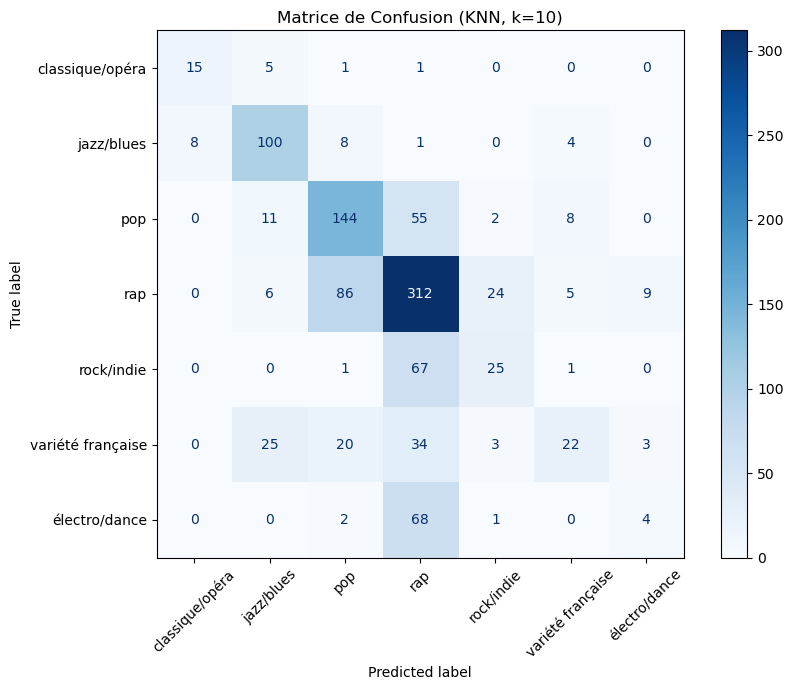


Rapport de Classification (KNN):
                   precision    recall  f1-score   support

  classique/opéra       0.65      0.68      0.67        22
       jazz/blues       0.68      0.83      0.75       121
              pop       0.55      0.65      0.60       220
              rap       0.58      0.71      0.64       442
       rock/indie       0.45      0.27      0.34        94
variété française       0.55      0.21      0.30       107
    électro/dance       0.25      0.05      0.09        75

         accuracy                           0.58      1081
        macro avg       0.53      0.48      0.48      1081
     weighted avg       0.55      0.58      0.54      1081



In [38]:
# Affiche un titre pour indiquer le début de la section de classification avec KNeighborsClassifier
print("\n--- Classification (KNeighborsClassifier pour prédire 'genre') ---")


# Création d'un pipeline de machine learning pour la classification
# Le pipeline enchaîne deux étapes principales :
# 1. 'scaler' : StandardScaler() standardise les features (moyenne 0, écart-type 1)
#    - Cela est crucial pour KNN, car il se base sur des distances : toutes les features doivent être sur la même échelle.
# 2. 'classifier' : KNeighborsClassifier(n_neighbors=10) applique l'algorithme KNN pour la classification
#    - n_neighbors=10 signifie que la classe prédite sera celle la plus fréquente parmi les 5 voisins les plus proches.
#    - Ce paramètre (k=10) est un choix courant, mais il peut être optimisé via validation croisée.
pipeline_knn_clf = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=10, metric='euclidean'))
    ])

# Sélection des features pour la classification avec KNN
# On extrait du DataFrame 'df' les colonnes suivantes :
# - 'valence' : mesure la positivité de la chanson (valeur entre 0 et 1)
# - 'energy' : mesure l'intensité de la chanson (valeur entre 0 et 1)
# - 'danceability' : mesure à quel point la chanson est dansante (valeur entre 0 et 1)
# - 'acousticness' : probabilité que la chanson soit acoustique (valeur entre 0 et 1)
# - 'tempo' : tempo de la chanson en battements par minute (BPM)
# - 'loudness' : volume sonore moyen de la chanson (en décibels)
# Ces colonnes sont sélectionnées car elles sont pertinentes pour caractériser et différencier les genres musicaux.
X_class_KNN = df.loc[:, ['valence', 'energy', 'danceability', 'acousticness', 'tempo', 'loudness']]


# Sélection de la variable cible (target) pour la classification
# Ici, on utilise la colonne 'genre' du DataFrame 'df'
y_class_KNN = df['genre']

# Instanciation de l'encodeur de labels
# LabelEncoder va transformer les genres musicaux (catégories textuelles) en entiers
le = LabelEncoder()

# Encodage de la variable cible
# Chaque genre unique est transformé en un entier unique (ex : 'pop' -> 0, 'rock' -> 1, etc.)
# Cela permet de rendre la cible compatible avec les algorithmes de classification de scikit-learn
y_class_KNN_encoded = le.fit_transform(y_class_KNN)


# Division des données en ensembles d'entraînement et de test pour la classification KNN

# On utilise train_test_split pour séparer les features (X_class_KNN) et la cible encodée (y_class_KNN_encoded)
# test_size=0.2 : 20% des données seront utilisées pour le test, 80% pour l'entraînement
# random_state=42 : fixe la graine aléatoire pour garantir la reproductibilité des résultats
# stratify=y_class_KNN_encoded : garantit que la proportion de chaque classe (genre) est respectée dans les deux ensembles,
# ce qui est crucial en cas de déséquilibre des classes

X_train_KNN, X_test_KNN, y_train_KNN, y_test_KNN = train_test_split(
    X_class_KNN,                # Features sélectionnées pour la classification
    y_class_KNN_encoded,        # Cible encodée en entiers
    test_size=0.2,              # Pourcentage des données dans l'ensemble de test
    random_state=42,            # Graine pour la reproductibilité
    stratify=y_class_KNN_encoded # Strate sur la cible pour équilibrer les classes dans chaque ensemble
)


# Pour KNN, la méthode .fit() ne construit pas un modèle complexe :
# Elle se contente de stocker les données d'entraînement, car l'algorithme KNN va comparer les nouveaux échantillons
# directement à ces données lors de la prédiction.
pipeline_knn_clf.fit(X_train_KNN, y_train_KNN)

# La méthode .predict() du pipeline :
# - Pour chaque échantillon, calcule la distance entre cet échantillon et tous les points d'entraînement stockés.
# - Sélectionne les k voisins les plus proches (selon la distance choisie, généralement euclidienne).
# - Attribue la classe majoritaire parmi ces voisins comme prédiction.

# Prédictions sur l'ensemble d'entraînement (permet de mesurer l'overfitting)
y_pred_knn_clf_train = pipeline_knn_clf.predict(X_train_KNN)

# Prédictions sur l'ensemble de test (permet d'évaluer la généralisation du modèle)
y_pred_knn_clf_test = pipeline_knn_clf.predict(X_test_KNN)


# Calcul de l'accuracy (taux de bonnes prédictions) sur l'ensemble d'entraînement
accuracy_knn_clf_train = accuracy_score(y_train_KNN, y_pred_knn_clf_train)
# Affichage formaté de l'accuracy d'entraînement avec 4 décimales
print(f"Modèle de Classification (KNN, k=10) - Accuracy sur l'ensemble d'entraînement: {accuracy_knn_clf_train:.4f}")

# Calcul de l'accuracy sur l'ensemble de test
accuracy_knn_clf_test = accuracy_score(y_test_KNN, y_pred_knn_clf_test)
# Affichage formaté de l'accuracy de test avec 4 décimales
print(f"Modèle de Classification (KNN, k=10) - Accuracy sur l'ensemble de test: {accuracy_knn_clf_test:.4f}")


# Calcul de la matrice de confusion pour le modèle KNN sur l'ensemble de test
# La matrice de confusion permet de visualiser le nombre de prédictions correctes et incorrectes pour chaque classe
cm_knn = confusion_matrix(y_test_KNN, y_pred_knn_clf_test)

# Création de l'objet d'affichage avec les noms de genres
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=genre)

# Création d'une figure plus large pour éviter le chevauchement
fig, ax = plt.subplots(figsize=(9, 7))
disp_knn.plot(cmap='Blues', ax=ax, xticks_rotation=45)  # xticks_rotation=45 incline les labels de l'axe x

plt.title("Matrice de Confusion (KNN, k=10)")
plt.tight_layout()  # Ajuste automatiquement les marges pour éviter que les labels soient coupés
plt.show()


# Affiche un titre pour séparer visuellement le rapport de classification dans la console
print("\nRapport de Classification (KNN):")

# Affiche un rapport détaillé sur les performances du modèle KNN pour chaque genre musical (classe)
# classification_report calcule et affiche les métriques suivantes pour chaque classe :
# - precision : proportion de prédictions correctes parmi toutes les prédictions positives pour cette classe
# - recall (rappel) : proportion de prédictions correctes parmi toutes les vraies instances de cette classe
# - f1-score : moyenne harmonique entre la précision et le rappel, mesure globale de la performance
# - support : nombre d'échantillons réels de chaque classe dans l'ensemble de test
# L'argument target_names=genre permet d'afficher les noms des genres au lieu des indices numériques.
# Attention : la variable 'genre' doit contenir la liste ordonnée des noms de genres correspondant à l'encodage utilisé (ex : le.classes_)
print(classification_report(y_test_KNN, y_pred_knn_clf_test, target_names=genre))




## ML supervisé : KNN (k=15, test_size=0.2, metric='euclidean')


--- Classification (KNeighborsClassifier pour prédire 'genre') ---
Modèle de Classification (KNN, k=15) - Accuracy sur l'ensemble d'entraînement: 0.6245
Modèle de Classification (KNN, k=15) - Accuracy sur l'ensemble de test: 0.5782


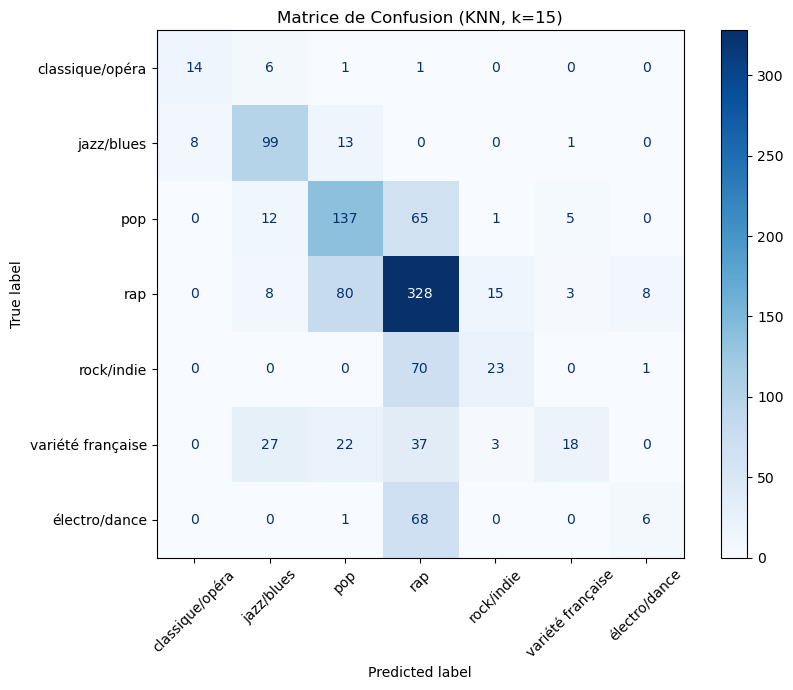


Rapport de Classification (KNN):
                   precision    recall  f1-score   support

  classique/opéra       0.64      0.64      0.64        22
       jazz/blues       0.65      0.82      0.73       121
              pop       0.54      0.62      0.58       220
              rap       0.58      0.74      0.65       442
       rock/indie       0.55      0.24      0.34        94
variété française       0.67      0.17      0.27       107
    électro/dance       0.40      0.08      0.13        75

         accuracy                           0.58      1081
        macro avg       0.57      0.47      0.48      1081
     weighted avg       0.57      0.58      0.54      1081



In [39]:
# Affiche un titre pour indiquer le début de la section de classification avec KNeighborsClassifier
print("\n--- Classification (KNeighborsClassifier pour prédire 'genre') ---")


# Création d'un pipeline de machine learning pour la classification
# Le pipeline enchaîne deux étapes principales :
# 1. 'scaler' : StandardScaler() standardise les features (moyenne 0, écart-type 1)
#    - Cela est crucial pour KNN, car il se base sur des distances : toutes les features doivent être sur la même échelle.
# 2. 'classifier' : KNeighborsClassifier(n_neighbors=15) applique l'algorithme KNN pour la classification
#    - n_neighbors=15 signifie que la classe prédite sera celle la plus fréquente parmi les 5 voisins les plus proches.
#    - Ce paramètre (k=15) est un choix courant, mais il peut être optimisé via validation croisée.
pipeline_knn_clf = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=15, metric='euclidean'))
    ])

# Sélection des features pour la classification avec KNN
# On extrait du DataFrame 'df' les colonnes suivantes :
# - 'valence' : mesure la positivité de la chanson (valeur entre 0 et 1)
# - 'energy' : mesure l'intensité de la chanson (valeur entre 0 et 1)
# - 'danceability' : mesure à quel point la chanson est dansante (valeur entre 0 et 1)
# - 'acousticness' : probabilité que la chanson soit acoustique (valeur entre 0 et 1)
# - 'tempo' : tempo de la chanson en battements par minute (BPM)
# - 'loudness' : volume sonore moyen de la chanson (en décibels)
# Ces colonnes sont sélectionnées car elles sont pertinentes pour caractériser et différencier les genres musicaux.
X_class_KNN = df.loc[:, ['valence', 'energy', 'danceability', 'acousticness', 'tempo', 'loudness']]


# Sélection de la variable cible (target) pour la classification
# Ici, on utilise la colonne 'genre' du DataFrame 'df'
y_class_KNN = df['genre']

# Instanciation de l'encodeur de labels
# LabelEncoder va transformer les genres musicaux (catégories textuelles) en entiers
le = LabelEncoder()

# Encodage de la variable cible
# Chaque genre unique est transformé en un entier unique (ex : 'pop' -> 0, 'rock' -> 1, etc.)
# Cela permet de rendre la cible compatible avec les algorithmes de classification de scikit-learn
y_class_KNN_encoded = le.fit_transform(y_class_KNN)


# Division des données en ensembles d'entraînement et de test pour la classification KNN

# On utilise train_test_split pour séparer les features (X_class_KNN) et la cible encodée (y_class_KNN_encoded)
# test_size=0.2 : 20% des données seront utilisées pour le test, 80% pour l'entraînement
# random_state=42 : fixe la graine aléatoire pour garantir la reproductibilité des résultats
# stratify=y_class_KNN_encoded : garantit que la proportion de chaque classe (genre) est respectée dans les deux ensembles,
# ce qui est crucial en cas de déséquilibre des classes

X_train_KNN, X_test_KNN, y_train_KNN, y_test_KNN = train_test_split(
    X_class_KNN,                # Features sélectionnées pour la classification
    y_class_KNN_encoded,        # Cible encodée en entiers
    test_size=0.2,              # Pourcentage des données dans l'ensemble de test
    random_state=42,            # Graine pour la reproductibilité
    stratify=y_class_KNN_encoded # Strate sur la cible pour équilibrer les classes dans chaque ensemble
)


# Pour KNN, la méthode .fit() ne construit pas un modèle complexe :
# Elle se contente de stocker les données d'entraînement, car l'algorithme KNN va comparer les nouveaux échantillons
# directement à ces données lors de la prédiction.
pipeline_knn_clf.fit(X_train_KNN, y_train_KNN)

# La méthode .predict() du pipeline :
# - Pour chaque échantillon, calcule la distance entre cet échantillon et tous les points d'entraînement stockés.
# - Sélectionne les k voisins les plus proches (selon la distance choisie, généralement euclidienne).
# - Attribue la classe majoritaire parmi ces voisins comme prédiction.

# Prédictions sur l'ensemble d'entraînement (permet de mesurer l'overfitting)
y_pred_knn_clf_train = pipeline_knn_clf.predict(X_train_KNN)

# Prédictions sur l'ensemble de test (permet d'évaluer la généralisation du modèle)
y_pred_knn_clf_test = pipeline_knn_clf.predict(X_test_KNN)


# Calcul de l'accuracy (taux de bonnes prédictions) sur l'ensemble d'entraînement
accuracy_knn_clf_train = accuracy_score(y_train_KNN, y_pred_knn_clf_train)
# Affichage formaté de l'accuracy d'entraînement avec 4 décimales
print(f"Modèle de Classification (KNN, k=15) - Accuracy sur l'ensemble d'entraînement: {accuracy_knn_clf_train:.4f}")

# Calcul de l'accuracy sur l'ensemble de test
accuracy_knn_clf_test = accuracy_score(y_test_KNN, y_pred_knn_clf_test)
# Affichage formaté de l'accuracy de test avec 4 décimales
print(f"Modèle de Classification (KNN, k=15) - Accuracy sur l'ensemble de test: {accuracy_knn_clf_test:.4f}")


# Calcul de la matrice de confusion pour le modèle KNN sur l'ensemble de test
# La matrice de confusion permet de visualiser le nombre de prédictions correctes et incorrectes pour chaque classe
cm_knn = confusion_matrix(y_test_KNN, y_pred_knn_clf_test)

# Création de l'objet d'affichage avec les noms de genres
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=genre)

# Création d'une figure plus large pour éviter le chevauchement
fig, ax = plt.subplots(figsize=(9, 7))
disp_knn.plot(cmap='Blues', ax=ax, xticks_rotation=45)  # xticks_rotation=45 incline les labels de l'axe x

plt.title("Matrice de Confusion (KNN, k=15)")
plt.tight_layout()  # Ajuste automatiquement les marges pour éviter que les labels soient coupés
plt.show()


# Affiche un titre pour séparer visuellement le rapport de classification dans la console
print("\nRapport de Classification (KNN):")

# Affiche un rapport détaillé sur les performances du modèle KNN pour chaque genre musical (classe)
# classification_report calcule et affiche les métriques suivantes pour chaque classe :
# - precision : proportion de prédictions correctes parmi toutes les prédictions positives pour cette classe
# - recall (rappel) : proportion de prédictions correctes parmi toutes les vraies instances de cette classe
# - f1-score : moyenne harmonique entre la précision et le rappel, mesure globale de la performance
# - support : nombre d'échantillons réels de chaque classe dans l'ensemble de test
# L'argument target_names=genre permet d'afficher les noms des genres au lieu des indices numériques.
# Attention : la variable 'genre' doit contenir la liste ordonnée des noms de genres correspondant à l'encodage utilisé (ex : le.classes_)
print(classification_report(y_test_KNN, y_pred_knn_clf_test, target_names=genre))




## ML supervisé : KNN (k=20, test_size=0.2, metric='euclidean')


--- Classification (KNeighborsClassifier pour prédire 'genre') ---
Modèle de Classification (KNN, k=20) - Accuracy sur l'ensemble d'entraînement: 0.6141
Modèle de Classification (KNN, k=20) - Accuracy sur l'ensemble de test: 0.5828


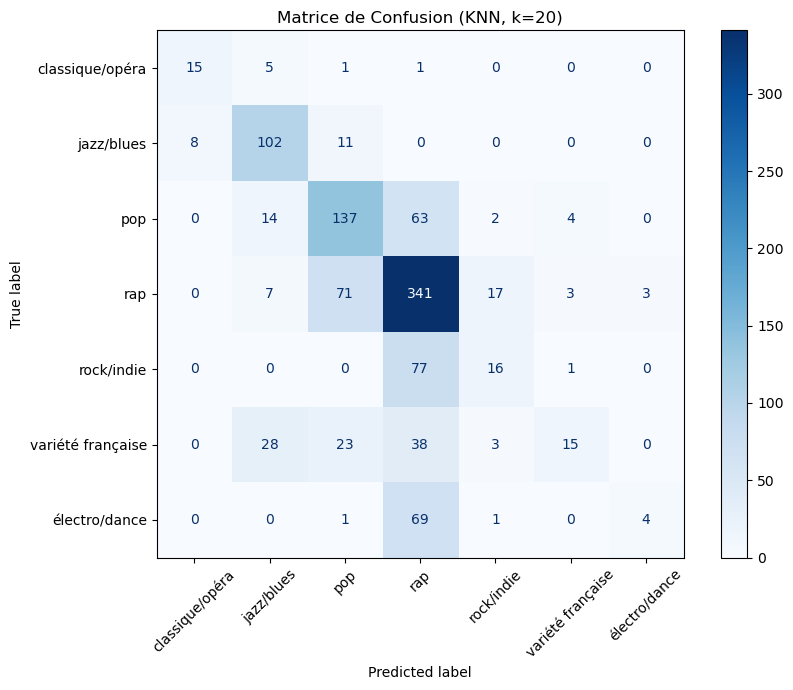


Rapport de Classification (KNN):
                   precision    recall  f1-score   support

  classique/opéra       0.65      0.68      0.67        22
       jazz/blues       0.65      0.84      0.74       121
              pop       0.56      0.62      0.59       220
              rap       0.58      0.77      0.66       442
       rock/indie       0.41      0.17      0.24        94
variété française       0.65      0.14      0.23       107
    électro/dance       0.57      0.05      0.10        75

         accuracy                           0.58      1081
        macro avg       0.58      0.47      0.46      1081
     weighted avg       0.58      0.58      0.54      1081



In [40]:
# Affiche un titre pour indiquer le début de la section de classification avec KNeighborsClassifier
print("\n--- Classification (KNeighborsClassifier pour prédire 'genre') ---")


# Création d'un pipeline de machine learning pour la classification
# Le pipeline enchaîne deux étapes principales :
# 1. 'scaler' : StandardScaler() standardise les features (moyenne 0, écart-type 1)
#    - Cela est crucial pour KNN, car il se base sur des distances : toutes les features doivent être sur la même échelle.
# 2. 'classifier' : KNeighborsClassifier(n_neighbors=20) applique l'algorithme KNN pour la classification
#    - n_neighbors=20 signifie que la classe prédite sera celle la plus fréquente parmi les 5 voisins les plus proches.
#    - Ce paramètre (k=20) est un choix courant, mais il peut être optimisé via validation croisée.
pipeline_knn_clf = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=20, metric='euclidean'))
    ])

# Sélection des features pour la classification avec KNN
# On extrait du DataFrame 'df' les colonnes suivantes :
# - 'valence' : mesure la positivité de la chanson (valeur entre 0 et 1)
# - 'energy' : mesure l'intensité de la chanson (valeur entre 0 et 1)
# - 'danceability' : mesure à quel point la chanson est dansante (valeur entre 0 et 1)
# - 'acousticness' : probabilité que la chanson soit acoustique (valeur entre 0 et 1)
# - 'tempo' : tempo de la chanson en battements par minute (BPM)
# - 'loudness' : volume sonore moyen de la chanson (en décibels)
# Ces colonnes sont sélectionnées car elles sont pertinentes pour caractériser et différencier les genres musicaux.
X_class_KNN = df.loc[:, ['valence', 'energy', 'danceability', 'acousticness', 'tempo', 'loudness']]


# Sélection de la variable cible (target) pour la classification
# Ici, on utilise la colonne 'genre' du DataFrame 'df'
y_class_KNN = df['genre']

# Instanciation de l'encodeur de labels
# LabelEncoder va transformer les genres musicaux (catégories textuelles) en entiers
le = LabelEncoder()

# Encodage de la variable cible
# Chaque genre unique est transformé en un entier unique (ex : 'pop' -> 0, 'rock' -> 1, etc.)
# Cela permet de rendre la cible compatible avec les algorithmes de classification de scikit-learn
y_class_KNN_encoded = le.fit_transform(y_class_KNN)


# Division des données en ensembles d'entraînement et de test pour la classification KNN

# On utilise train_test_split pour séparer les features (X_class_KNN) et la cible encodée (y_class_KNN_encoded)
# test_size=0.2 : 20% des données seront utilisées pour le test, 80% pour l'entraînement
# random_state=42 : fixe la graine aléatoire pour garantir la reproductibilité des résultats
# stratify=y_class_KNN_encoded : garantit que la proportion de chaque classe (genre) est respectée dans les deux ensembles,
# ce qui est crucial en cas de déséquilibre des classes

X_train_KNN, X_test_KNN, y_train_KNN, y_test_KNN = train_test_split(
    X_class_KNN,                # Features sélectionnées pour la classification
    y_class_KNN_encoded,        # Cible encodée en entiers
    test_size=0.2,              # Pourcentage des données dans l'ensemble de test
    random_state=42,            # Graine pour la reproductibilité
    stratify=y_class_KNN_encoded # Strate sur la cible pour équilibrer les classes dans chaque ensemble
)


# Pour KNN, la méthode .fit() ne construit pas un modèle complexe :
# Elle se contente de stocker les données d'entraînement, car l'algorithme KNN va comparer les nouveaux échantillons
# directement à ces données lors de la prédiction.
pipeline_knn_clf.fit(X_train_KNN, y_train_KNN)

# La méthode .predict() du pipeline :
# - Pour chaque échantillon, calcule la distance entre cet échantillon et tous les points d'entraînement stockés.
# - Sélectionne les k voisins les plus proches (selon la distance choisie, généralement euclidienne).
# - Attribue la classe majoritaire parmi ces voisins comme prédiction.

# Prédictions sur l'ensemble d'entraînement (permet de mesurer l'overfitting)
y_pred_knn_clf_train = pipeline_knn_clf.predict(X_train_KNN)

# Prédictions sur l'ensemble de test (permet d'évaluer la généralisation du modèle)
y_pred_knn_clf_test = pipeline_knn_clf.predict(X_test_KNN)


# Calcul de l'accuracy (taux de bonnes prédictions) sur l'ensemble d'entraînement
accuracy_knn_clf_train = accuracy_score(y_train_KNN, y_pred_knn_clf_train)
# Affichage formaté de l'accuracy d'entraînement avec 4 décimales
print(f"Modèle de Classification (KNN, k=20) - Accuracy sur l'ensemble d'entraînement: {accuracy_knn_clf_train:.4f}")

# Calcul de l'accuracy sur l'ensemble de test
accuracy_knn_clf_test = accuracy_score(y_test_KNN, y_pred_knn_clf_test)
# Affichage formaté de l'accuracy de test avec 4 décimales
print(f"Modèle de Classification (KNN, k=20) - Accuracy sur l'ensemble de test: {accuracy_knn_clf_test:.4f}")


# Calcul de la matrice de confusion pour le modèle KNN sur l'ensemble de test
# La matrice de confusion permet de visualiser le nombre de prédictions correctes et incorrectes pour chaque classe
cm_knn = confusion_matrix(y_test_KNN, y_pred_knn_clf_test)

# Création de l'objet d'affichage avec les noms de genres
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=genre)

# Création d'une figure plus large pour éviter le chevauchement
fig, ax = plt.subplots(figsize=(9, 7))
disp_knn.plot(cmap='Blues', ax=ax, xticks_rotation=45)  # xticks_rotation=45 incline les labels de l'axe x

plt.title("Matrice de Confusion (KNN, k=20)")
plt.tight_layout()  # Ajuste automatiquement les marges pour éviter que les labels soient coupés
plt.show()


# Affiche un titre pour séparer visuellement le rapport de classification dans la console
print("\nRapport de Classification (KNN):")

# Affiche un rapport détaillé sur les performances du modèle KNN pour chaque genre musical (classe)
# classification_report calcule et affiche les métriques suivantes pour chaque classe :
# - precision : proportion de prédictions correctes parmi toutes les prédictions positives pour cette classe
# - recall (rappel) : proportion de prédictions correctes parmi toutes les vraies instances de cette classe
# - f1-score : moyenne harmonique entre la précision et le rappel, mesure globale de la performance
# - support : nombre d'échantillons réels de chaque classe dans l'ensemble de test
# L'argument target_names=genre permet d'afficher les noms des genres au lieu des indices numériques.
# Attention : la variable 'genre' doit contenir la liste ordonnée des noms de genres correspondant à l'encodage utilisé (ex : le.classes_)
print(classification_report(y_test_KNN, y_pred_knn_clf_test, target_names=genre))




## ML supervisé : KNN (k=25, test_size=0.2, metric='euclidean')


--- Classification (KNeighborsClassifier pour prédire 'genre') ---
Modèle de Classification (KNN, k=25) - Accuracy sur l'ensemble d'entraînement: 0.6055
Modèle de Classification (KNN, k=25) - Accuracy sur l'ensemble de test: 0.5856


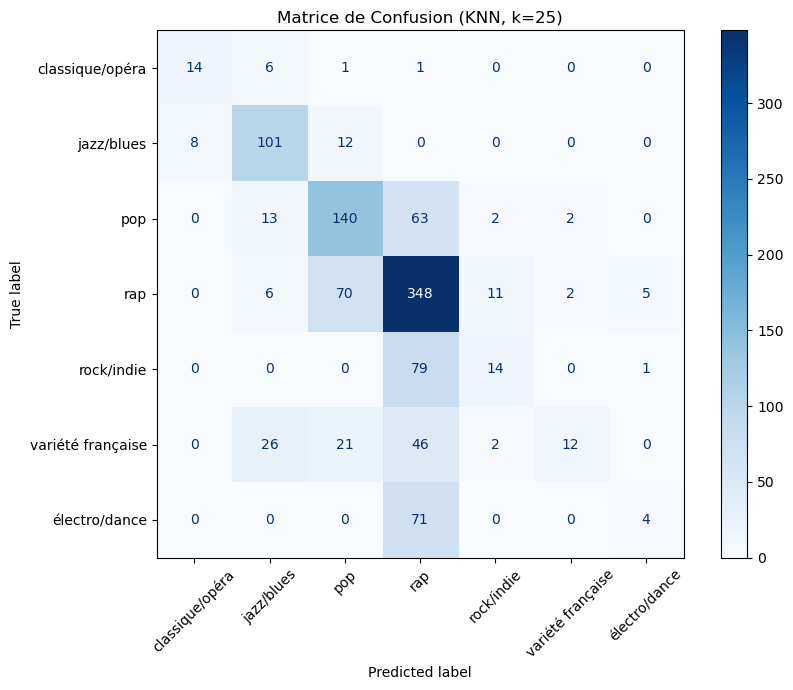


Rapport de Classification (KNN):
                   precision    recall  f1-score   support

  classique/opéra       0.64      0.64      0.64        22
       jazz/blues       0.66      0.83      0.74       121
              pop       0.57      0.64      0.60       220
              rap       0.57      0.79      0.66       442
       rock/indie       0.48      0.15      0.23        94
variété française       0.75      0.11      0.20       107
    électro/dance       0.40      0.05      0.09        75

         accuracy                           0.59      1081
        macro avg       0.58      0.46      0.45      1081
     weighted avg       0.58      0.59      0.54      1081



In [41]:
# Affiche un titre pour indiquer le début de la section de classification avec KNeighborsClassifier
print("\n--- Classification (KNeighborsClassifier pour prédire 'genre') ---")


# Création d'un pipeline de machine learning pour la classification
# Le pipeline enchaîne deux étapes principales :
# 1. 'scaler' : StandardScaler() standardise les features (moyenne 0, écart-type 1)
#    - Cela est crucial pour KNN, car il se base sur des distances : toutes les features doivent être sur la même échelle.
# 2. 'classifier' : KNeighborsClassifier(n_neighbors=25) applique l'algorithme KNN pour la classification
#    - n_neighbors=25 signifie que la classe prédite sera celle la plus fréquente parmi les 5 voisins les plus proches.
#    - Ce paramètre (k=25) est un choix courant, mais il peut être optimisé via validation croisée.
pipeline_knn_clf = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=25, metric='euclidean'))
    ])

# Sélection des features pour la classification avec KNN
# On extrait du DataFrame 'df' les colonnes suivantes :
# - 'valence' : mesure la positivité de la chanson (valeur entre 0 et 1)
# - 'energy' : mesure l'intensité de la chanson (valeur entre 0 et 1)
# - 'danceability' : mesure à quel point la chanson est dansante (valeur entre 0 et 1)
# - 'acousticness' : probabilité que la chanson soit acoustique (valeur entre 0 et 1)
# - 'tempo' : tempo de la chanson en battements par minute (BPM)
# - 'loudness' : volume sonore moyen de la chanson (en décibels)
# Ces colonnes sont sélectionnées car elles sont pertinentes pour caractériser et différencier les genres musicaux.
X_class_KNN = df.loc[:, ['valence', 'energy', 'danceability', 'acousticness', 'tempo', 'loudness']]


# Sélection de la variable cible (target) pour la classification
# Ici, on utilise la colonne 'genre' du DataFrame 'df'
y_class_KNN = df['genre']

# Instanciation de l'encodeur de labels
# LabelEncoder va transformer les genres musicaux (catégories textuelles) en entiers
le = LabelEncoder()

# Encodage de la variable cible
# Chaque genre unique est transformé en un entier unique (ex : 'pop' -> 0, 'rock' -> 1, etc.)
# Cela permet de rendre la cible compatible avec les algorithmes de classification de scikit-learn
y_class_KNN_encoded = le.fit_transform(y_class_KNN)


# Division des données en ensembles d'entraînement et de test pour la classification KNN

# On utilise train_test_split pour séparer les features (X_class_KNN) et la cible encodée (y_class_KNN_encoded)
# test_size=0.2 : 20% des données seront utilisées pour le test, 80% pour l'entraînement
# random_state=42 : fixe la graine aléatoire pour garantir la reproductibilité des résultats
# stratify=y_class_KNN_encoded : garantit que la proportion de chaque classe (genre) est respectée dans les deux ensembles,
# ce qui est crucial en cas de déséquilibre des classes

X_train_KNN, X_test_KNN, y_train_KNN, y_test_KNN = train_test_split(
    X_class_KNN,                # Features sélectionnées pour la classification
    y_class_KNN_encoded,        # Cible encodée en entiers
    test_size=0.2,              # Pourcentage des données dans l'ensemble de test
    random_state=42,            # Graine pour la reproductibilité
    stratify=y_class_KNN_encoded # Strate sur la cible pour équilibrer les classes dans chaque ensemble
)


# Pour KNN, la méthode .fit() ne construit pas un modèle complexe :
# Elle se contente de stocker les données d'entraînement, car l'algorithme KNN va comparer les nouveaux échantillons
# directement à ces données lors de la prédiction.
pipeline_knn_clf.fit(X_train_KNN, y_train_KNN)

# La méthode .predict() du pipeline :
# - Pour chaque échantillon, calcule la distance entre cet échantillon et tous les points d'entraînement stockés.
# - Sélectionne les k voisins les plus proches (selon la distance choisie, généralement euclidienne).
# - Attribue la classe majoritaire parmi ces voisins comme prédiction.

# Prédictions sur l'ensemble d'entraînement (permet de mesurer l'overfitting)
y_pred_knn_clf_train = pipeline_knn_clf.predict(X_train_KNN)

# Prédictions sur l'ensemble de test (permet d'évaluer la généralisation du modèle)
y_pred_knn_clf_test = pipeline_knn_clf.predict(X_test_KNN)


# Calcul de l'accuracy (taux de bonnes prédictions) sur l'ensemble d'entraînement
accuracy_knn_clf_train = accuracy_score(y_train_KNN, y_pred_knn_clf_train)
# Affichage formaté de l'accuracy d'entraînement avec 4 décimales
print(f"Modèle de Classification (KNN, k=25) - Accuracy sur l'ensemble d'entraînement: {accuracy_knn_clf_train:.4f}")

# Calcul de l'accuracy sur l'ensemble de test
accuracy_knn_clf_test = accuracy_score(y_test_KNN, y_pred_knn_clf_test)
# Affichage formaté de l'accuracy de test avec 4 décimales
print(f"Modèle de Classification (KNN, k=25) - Accuracy sur l'ensemble de test: {accuracy_knn_clf_test:.4f}")


# Calcul de la matrice de confusion pour le modèle KNN sur l'ensemble de test
# La matrice de confusion permet de visualiser le nombre de prédictions correctes et incorrectes pour chaque classe
cm_knn = confusion_matrix(y_test_KNN, y_pred_knn_clf_test)

# Création de l'objet d'affichage avec les noms de genres
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=genre)

# Création d'une figure plus large pour éviter le chevauchement
fig, ax = plt.subplots(figsize=(9, 7))
disp_knn.plot(cmap='Blues', ax=ax, xticks_rotation=45)  # xticks_rotation=45 incline les labels de l'axe x

plt.title("Matrice de Confusion (KNN, k=25)")
plt.tight_layout()  # Ajuste automatiquement les marges pour éviter que les labels soient coupés
plt.show()


# Affiche un titre pour séparer visuellement le rapport de classification dans la console
print("\nRapport de Classification (KNN):")

# Affiche un rapport détaillé sur les performances du modèle KNN pour chaque genre musical (classe)
# classification_report calcule et affiche les métriques suivantes pour chaque classe :
# - precision : proportion de prédictions correctes parmi toutes les prédictions positives pour cette classe
# - recall (rappel) : proportion de prédictions correctes parmi toutes les vraies instances de cette classe
# - f1-score : moyenne harmonique entre la précision et le rappel, mesure globale de la performance
# - support : nombre d'échantillons réels de chaque classe dans l'ensemble de test
# L'argument target_names=genre permet d'afficher les noms des genres au lieu des indices numériques.
# Attention : la variable 'genre' doit contenir la liste ordonnée des noms de genres correspondant à l'encodage utilisé (ex : le.classes_)
print(classification_report(y_test_KNN, y_pred_knn_clf_test, target_names=genre))




## Tableau comparatif : ML supervisé KNN (metric = 'euclidean')

In [42]:
# Définition des différentes valeurs de k à tester
k_values = [5, 7, 10, 15, 20, 25]  # liste des k pour KNN

# Sélection des features pertinentes dans le DataFrame df
X = df.loc[:, ['valence', 'energy', 'danceability', 'acousticness', 'tempo', 'loudness']]

# Encodage des labels (genres) en entiers
le = LabelEncoder()                   # instanciation de l'encodeur de labels
y = le.fit_transform(df['genre'])     # transformation des genres en entiers

# Séparation des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(
    X,                                 # features
    y,                                 # cible encodée
    test_size=0.2,                     # 20% des données en test
    random_state=42,                   # pour la reproductibilité
    stratify=y                         # conserve la distribution des classes
)

# Initialisation d'une liste pour stocker les résultats de chaque k
results = []

# Boucle sur chaque valeur de k
for k in k_values:
    # Construction du pipeline scaler + KNN avec la valeur de k en cours
    pipeline = Pipeline(steps=[
        ('scaler', StandardScaler()),                                  # normalisation des données
        ('classifier', KNeighborsClassifier(n_neighbors=k, metric='euclidean'))
    ])
    
    # Entraînement du modèle sur l'ensemble d'entraînement
    pipeline.fit(X_train, y_train)
    
    # Prédiction sur le train et le test
    y_pred_train = pipeline.predict(X_train)  # labels prédits sur train
    y_pred_test = pipeline.predict(X_test)    # labels prédits sur test
    
    # Calcul des métriques d'évaluation
    train_acc = accuracy_score(y_train, y_pred_train)                           # accuracy sur train
    test_acc = accuracy_score(y_test, y_pred_test)                              # accuracy sur test
    macro_prec = precision_score(y_test, y_pred_test, average='macro')          # précision moyenne macro
    macro_rec = recall_score(y_test, y_pred_test, average='macro')              # rappel moyen macro
    macro_f1 = f1_score(y_test, y_pred_test, average='macro')                   # f1-score moyen macro
    
    # Ajout des résultats dans la liste
    results.append({
        'k': k,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'macro_precision': macro_prec,
        'macro_recall': macro_rec,
        'macro_f1': macro_f1
    })

# Conversion de la liste en DataFrame pour affichage tabulaire
df_results = pd.DataFrame(results)

# Affichage du tableau comparatif
print(df_results)


    k  train_accuracy  test_accuracy  macro_precision  macro_recall  macro_f1
0   5        0.664276       0.545791         0.504516      0.472160  0.473759
1   7        0.654558       0.556892         0.510902      0.467652  0.471558
2  10        0.636974       0.575393         0.530934      0.484799  0.481426
3  15        0.624479       0.578168         0.573969      0.473180  0.475541
4  20        0.614068       0.582794         0.582900      0.468964  0.460582
5  25        0.605507       0.585569         0.582819      0.458455  0.451354


## ML supervisé : KNN (k=5, test_size=0.2, metric='cosine')


--- Classification (KNeighborsClassifier pour prédire 'genre') ---
Modèle de Classification (KNN, k=5) - Accuracy sur l'ensemble d'entraînement: 0.6629
Modèle de Classification (KNN, k=5) - Accuracy sur l'ensemble de test: 0.5199


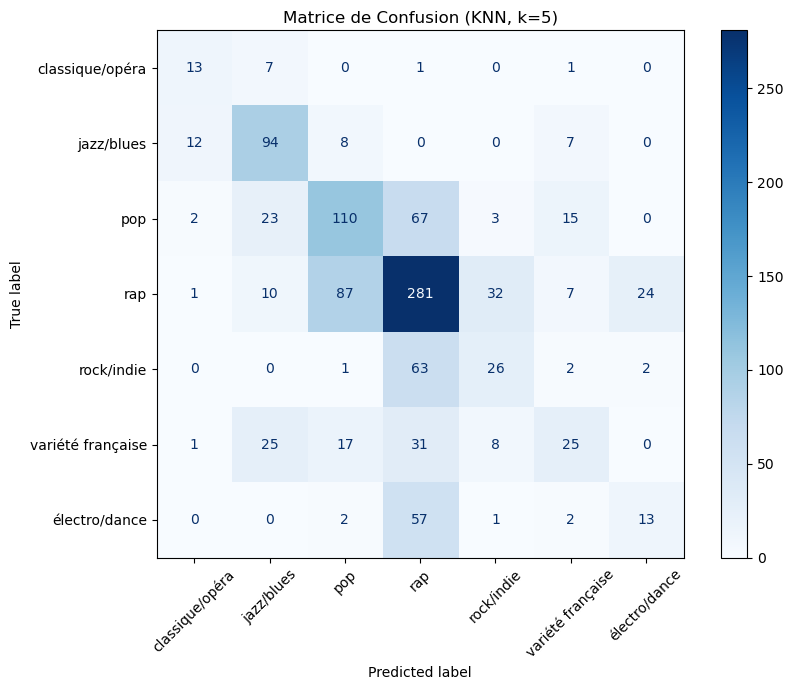


Rapport de Classification (KNN):
                   precision    recall  f1-score   support

  classique/opéra       0.45      0.59      0.51        22
       jazz/blues       0.59      0.78      0.67       121
              pop       0.49      0.50      0.49       220
              rap       0.56      0.64      0.60       442
       rock/indie       0.37      0.28      0.32        94
variété française       0.42      0.23      0.30       107
    électro/dance       0.33      0.17      0.23        75

         accuracy                           0.52      1081
        macro avg       0.46      0.46      0.45      1081
     weighted avg       0.50      0.52      0.50      1081



In [43]:
# Affiche un titre pour indiquer le début de la section de classification avec KNeighborsClassifier
print("\n--- Classification (KNeighborsClassifier pour prédire 'genre') ---")


# Création d'un pipeline de machine learning pour la classification
# Le pipeline enchaîne deux étapes principales :
# 1. 'scaler' : StandardScaler() standardise les features (moyenne 0, écart-type 1)
#    - Cela est crucial pour KNN, car il se base sur des distances : toutes les features doivent être sur la même échelle.
# 2. 'classifier' : KNeighborsClassifier(n_neighbors=5) applique l'algorithme KNN pour la classification
#    - n_neighbors=5 signifie que la classe prédite sera celle la plus fréquente parmi les 5 voisins les plus proches.
#    - Ce paramètre (k=5) est un choix courant, mais il peut être optimisé via validation croisée.
pipeline_knn_clf = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=5, metric='cosine'))
    ])

# Sélection des features pour la classification avec KNN
# On extrait du DataFrame 'df' les colonnes suivantes :
# - 'valence' : mesure la positivité de la chanson (valeur entre 0 et 1)
# - 'energy' : mesure l'intensité de la chanson (valeur entre 0 et 1)
# - 'danceability' : mesure à quel point la chanson est dansante (valeur entre 0 et 1)
# - 'acousticness' : probabilité que la chanson soit acoustique (valeur entre 0 et 1)
# - 'tempo' : tempo de la chanson en battements par minute (BPM)
# - 'loudness' : volume sonore moyen de la chanson (en décibels)
# Ces colonnes sont sélectionnées car elles sont pertinentes pour caractériser et différencier les genres musicaux.
X_class_KNN = df.loc[:, ['valence', 'energy', 'danceability', 'acousticness', 'tempo', 'loudness']]


# Sélection de la variable cible (target) pour la classification
# Ici, on utilise la colonne 'genre' du DataFrame 'df'
y_class_KNN = df['genre']

# Instanciation de l'encodeur de labels
# LabelEncoder va transformer les genres musicaux (catégories textuelles) en entiers
le = LabelEncoder()

# Encodage de la variable cible
# Chaque genre unique est transformé en un entier unique (ex : 'pop' -> 0, 'rock' -> 1, etc.)
# Cela permet de rendre la cible compatible avec les algorithmes de classification de scikit-learn
y_class_KNN_encoded = le.fit_transform(y_class_KNN)


# Division des données en ensembles d'entraînement et de test pour la classification KNN

# On utilise train_test_split pour séparer les features (X_class_KNN) et la cible encodée (y_class_KNN_encoded)
# test_size=0.2 : 20% des données seront utilisées pour le test, 80% pour l'entraînement
# random_state=42 : fixe la graine aléatoire pour garantir la reproductibilité des résultats
# stratify=y_class_KNN_encoded : garantit que la proportion de chaque classe (genre) est respectée dans les deux ensembles,
# ce qui est crucial en cas de déséquilibre des classes

X_train_KNN, X_test_KNN, y_train_KNN, y_test_KNN = train_test_split(
    X_class_KNN,                # Features sélectionnées pour la classification
    y_class_KNN_encoded,        # Cible encodée en entiers
    test_size=0.2,              # Pourcentage des données dans l'ensemble de test
    random_state=42,            # Graine pour la reproductibilité
    stratify=y_class_KNN_encoded # Strate sur la cible pour équilibrer les classes dans chaque ensemble
)


# Pour KNN, la méthode .fit() ne construit pas un modèle complexe :
# Elle se contente de stocker les données d'entraînement, car l'algorithme KNN va comparer les nouveaux échantillons
# directement à ces données lors de la prédiction.
pipeline_knn_clf.fit(X_train_KNN, y_train_KNN)

# La méthode .predict() du pipeline :
# - Pour chaque échantillon, calcule la distance entre cet échantillon et tous les points d'entraînement stockés.
# - Sélectionne les k voisins les plus proches (selon la distance choisie, généralement euclidienne).
# - Attribue la classe majoritaire parmi ces voisins comme prédiction.

# Prédictions sur l'ensemble d'entraînement (permet de mesurer l'overfitting)
y_pred_knn_clf_train = pipeline_knn_clf.predict(X_train_KNN)

# Prédictions sur l'ensemble de test (permet d'évaluer la généralisation du modèle)
y_pred_knn_clf_test = pipeline_knn_clf.predict(X_test_KNN)


# Calcul de l'accuracy (taux de bonnes prédictions) sur l'ensemble d'entraînement
accuracy_knn_clf_train = accuracy_score(y_train_KNN, y_pred_knn_clf_train)
# Affichage formaté de l'accuracy d'entraînement avec 4 décimales
print(f"Modèle de Classification (KNN, k=5) - Accuracy sur l'ensemble d'entraînement: {accuracy_knn_clf_train:.4f}")

# Calcul de l'accuracy sur l'ensemble de test
accuracy_knn_clf_test = accuracy_score(y_test_KNN, y_pred_knn_clf_test)
# Affichage formaté de l'accuracy de test avec 4 décimales
print(f"Modèle de Classification (KNN, k=5) - Accuracy sur l'ensemble de test: {accuracy_knn_clf_test:.4f}")


# Calcul de la matrice de confusion pour le modèle KNN sur l'ensemble de test
# La matrice de confusion permet de visualiser le nombre de prédictions correctes et incorrectes pour chaque classe
cm_knn = confusion_matrix(y_test_KNN, y_pred_knn_clf_test)

# Création de l'objet d'affichage avec les noms de genres
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=genre)

# Création d'une figure plus large pour éviter le chevauchement
fig, ax = plt.subplots(figsize=(9, 7))
disp_knn.plot(cmap='Blues', ax=ax, xticks_rotation=45)  # xticks_rotation=45 incline les labels de l'axe x

plt.title("Matrice de Confusion (KNN, k=5)")
plt.tight_layout()  # Ajuste automatiquement les marges pour éviter que les labels soient coupés
plt.show()


# Affiche un titre pour séparer visuellement le rapport de classification dans la console
print("\nRapport de Classification (KNN):")

# Affiche un rapport détaillé sur les performances du modèle KNN pour chaque genre musical (classe)
# classification_report calcule et affiche les métriques suivantes pour chaque classe :
# - precision : proportion de prédictions correctes parmi toutes les prédictions positives pour cette classe
# - recall (rappel) : proportion de prédictions correctes parmi toutes les vraies instances de cette classe
# - f1-score : moyenne harmonique entre la précision et le rappel, mesure globale de la performance
# - support : nombre d'échantillons réels de chaque classe dans l'ensemble de test
# L'argument target_names=genre permet d'afficher les noms des genres au lieu des indices numériques.
# Attention : la variable 'genre' doit contenir la liste ordonnée des noms de genres correspondant à l'encodage utilisé (ex : le.classes_)
print(classification_report(y_test_KNN, y_pred_knn_clf_test, target_names=genre))




## ML supervisé : KNN (k=7, test_size=0.2, metric='cosine')


--- Classification (KNeighborsClassifier pour prédire 'genre') ---
Modèle de Classification (KNN, k=7) - Accuracy sur l'ensemble d'entraînement: 0.6432
Modèle de Classification (KNN, k=7) - Accuracy sur l'ensemble de test: 0.5513


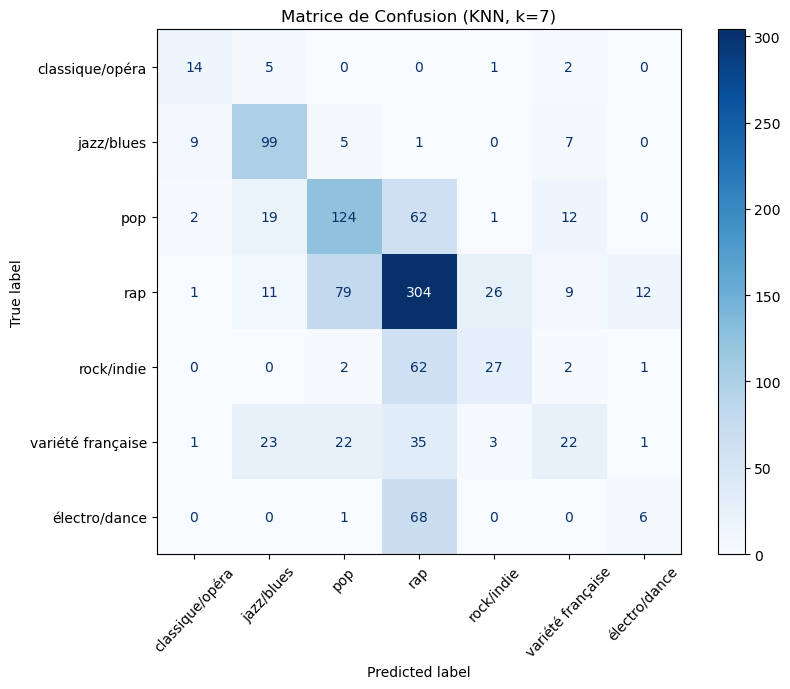


Rapport de Classification (KNN):
                   precision    recall  f1-score   support

  classique/opéra       0.52      0.64      0.57        22
       jazz/blues       0.63      0.82      0.71       121
              pop       0.53      0.56      0.55       220
              rap       0.57      0.69      0.62       442
       rock/indie       0.47      0.29      0.36        94
variété française       0.41      0.21      0.27       107
    électro/dance       0.30      0.08      0.13        75

         accuracy                           0.55      1081
        macro avg       0.49      0.47      0.46      1081
     weighted avg       0.52      0.55      0.52      1081



In [44]:
# Affiche un titre pour indiquer le début de la section de classification avec KNeighborsClassifier
print("\n--- Classification (KNeighborsClassifier pour prédire 'genre') ---")


# Création d'un pipeline de machine learning pour la classification
# Le pipeline enchaîne deux étapes principales :
# 1. 'scaler' : StandardScaler() standardise les features (moyenne 0, écart-type 1)
#    - Cela est crucial pour KNN, car il se base sur des distances : toutes les features doivent être sur la même échelle.
# 2. 'classifier' : KNeighborsClassifier(n_neighbors=7) applique l'algorithme KNN pour la classification
#    - n_neighbors=7 signifie que la classe prédite sera celle la plus fréquente parmi les 7 voisins les plus proches.
#    - Ce paramètre (k=7) est un choix courant, mais il peut être optimisé via validation croisée.
pipeline_knn_clf = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=7, metric='cosine'))
    ])

# Sélection des features pour la classification avec KNN
# On extrait du DataFrame 'df' les colonnes suivantes :
# - 'valence' : mesure la positivité de la chanson (valeur entre 0 et 1)
# - 'energy' : mesure l'intensité de la chanson (valeur entre 0 et 1)
# - 'danceability' : mesure à quel point la chanson est dansante (valeur entre 0 et 1)
# - 'acousticness' : probabilité que la chanson soit acoustique (valeur entre 0 et 1)
# - 'tempo' : tempo de la chanson en battements par minute (BPM)
# - 'loudness' : volume sonore moyen de la chanson (en décibels)
# Ces colonnes sont sélectionnées car elles sont pertinentes pour caractériser et différencier les genres musicaux.
X_class_KNN = df.loc[:, ['valence', 'energy', 'danceability', 'acousticness', 'tempo', 'loudness']]


# Sélection de la variable cible (target) pour la classification
# Ici, on utilise la colonne 'genre' du DataFrame 'df'
y_class_KNN = df['genre']

# Instanciation de l'encodeur de labels
# LabelEncoder va transformer les genres musicaux (catégories textuelles) en entiers
le = LabelEncoder()

# Encodage de la variable cible
# Chaque genre unique est transformé en un entier unique (ex : 'pop' -> 0, 'rock' -> 1, etc.)
# Cela permet de rendre la cible compatible avec les algorithmes de classification de scikit-learn
y_class_KNN_encoded = le.fit_transform(y_class_KNN)


# Division des données en ensembles d'entraînement et de test pour la classification KNN

# On utilise train_test_split pour séparer les features (X_class_KNN) et la cible encodée (y_class_KNN_encoded)
# test_size=0.2 : 20% des données seront utilisées pour le test, 80% pour l'entraînement
# random_state=42 : fixe la graine aléatoire pour garantir la reproductibilité des résultats
# stratify=y_class_KNN_encoded : garantit que la proportion de chaque classe (genre) est respectée dans les deux ensembles,
# ce qui est crucial en cas de déséquilibre des classes

X_train_KNN, X_test_KNN, y_train_KNN, y_test_KNN = train_test_split(
    X_class_KNN,                # Features sélectionnées pour la classification
    y_class_KNN_encoded,        # Cible encodée en entiers
    test_size=0.2,              # Pourcentage des données dans l'ensemble de test
    random_state=42,            # Graine pour la reproductibilité
    stratify=y_class_KNN_encoded # Strate sur la cible pour équilibrer les classes dans chaque ensemble
)


# Pour KNN, la méthode .fit() ne construit pas un modèle complexe :
# Elle se contente de stocker les données d'entraînement, car l'algorithme KNN va comparer les nouveaux échantillons
# directement à ces données lors de la prédiction.
pipeline_knn_clf.fit(X_train_KNN, y_train_KNN)

# La méthode .predict() du pipeline :
# - Pour chaque échantillon, calcule la distance entre cet échantillon et tous les points d'entraînement stockés.
# - Sélectionne les k voisins les plus proches (selon la distance choisie, généralement euclidienne).
# - Attribue la classe majoritaire parmi ces voisins comme prédiction.

# Prédictions sur l'ensemble d'entraînement (permet de mesurer l'overfitting)
y_pred_knn_clf_train = pipeline_knn_clf.predict(X_train_KNN)

# Prédictions sur l'ensemble de test (permet d'évaluer la généralisation du modèle)
y_pred_knn_clf_test = pipeline_knn_clf.predict(X_test_KNN)


# Calcul de l'accuracy (taux de bonnes prédictions) sur l'ensemble d'entraînement
accuracy_knn_clf_train = accuracy_score(y_train_KNN, y_pred_knn_clf_train)
# Affichage formaté de l'accuracy d'entraînement avec 4 décimales
print(f"Modèle de Classification (KNN, k=7) - Accuracy sur l'ensemble d'entraînement: {accuracy_knn_clf_train:.4f}")

# Calcul de l'accuracy sur l'ensemble de test
accuracy_knn_clf_test = accuracy_score(y_test_KNN, y_pred_knn_clf_test)
# Affichage formaté de l'accuracy de test avec 4 décimales
print(f"Modèle de Classification (KNN, k=7) - Accuracy sur l'ensemble de test: {accuracy_knn_clf_test:.4f}")


# Calcul de la matrice de confusion pour le modèle KNN sur l'ensemble de test
# La matrice de confusion permet de visualiser le nombre de prédictions correctes et incorrectes pour chaque classe
cm_knn = confusion_matrix(y_test_KNN, y_pred_knn_clf_test)

# Création de l'objet d'affichage avec les noms de genres
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=genre)

# Création d'une figure plus large pour éviter le chevauchement
fig, ax = plt.subplots(figsize=(9, 7))
disp_knn.plot(cmap='Blues', ax=ax, xticks_rotation=47)  # xticks_rotation=47 incline les labels de l'axe x

plt.title("Matrice de Confusion (KNN, k=7)")
plt.tight_layout()  # Ajuste automatiquement les marges pour éviter que les labels soient coupés
plt.show()


# Affiche un titre pour séparer visuellement le rapport de classification dans la console
print("\nRapport de Classification (KNN):")

# Affiche un rapport détaillé sur les performances du modèle KNN pour chaque genre musical (classe)
# classification_report calcule et affiche les métriques suivantes pour chaque classe :
# - precision : proportion de prédictions correctes parmi toutes les prédictions positives pour cette classe
# - recall (rappel) : proportion de prédictions correctes parmi toutes les vraies instances de cette classe
# - f1-score : moyenne harmonique entre la précision et le rappel, mesure globale de la performance
# - support : nombre d'échantillons réels de chaque classe dans l'ensemble de test
# L'argument target_names=genre permet d'afficher les noms des genres au lieu des indices numériques.
# Attention : la variable 'genre' doit contenir la liste ordonnée des noms de genres correspondant à l'encodage utilisé (ex : le.classes_)
print(classification_report(y_test_KNN, y_pred_knn_clf_test, target_names=genre))




## ML supervisé : KNN (k=10, test_size=0.2, metric='cosine')


--- Classification (KNeighborsClassifier pour prédire 'genre') ---
Modèle de Classification (KNN, k=10) - Accuracy sur l'ensemble d'entraînement: 0.6335
Modèle de Classification (KNN, k=10) - Accuracy sur l'ensemble de test: 0.5504


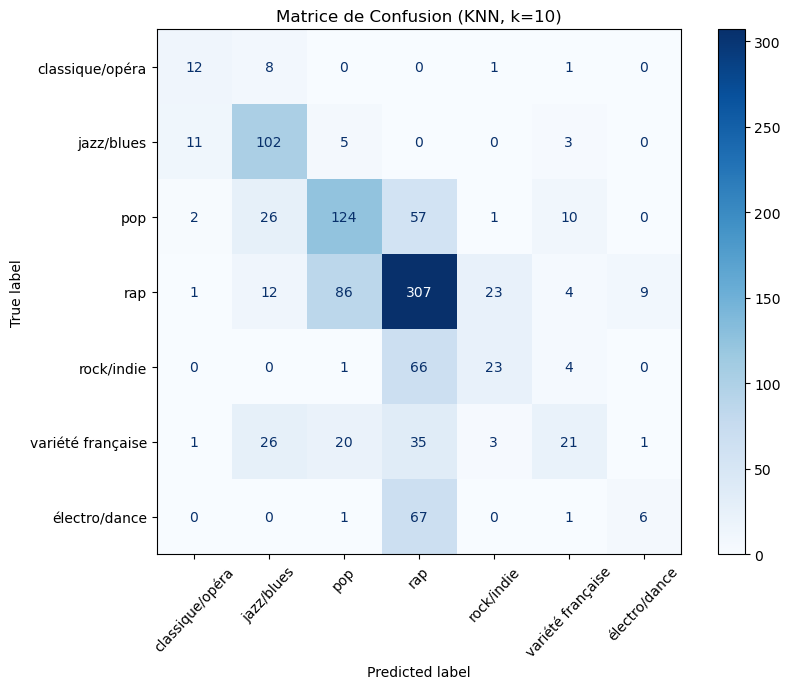


Rapport de Classification (KNN):
                   precision    recall  f1-score   support

  classique/opéra       0.44      0.55      0.49        22
       jazz/blues       0.59      0.84      0.69       121
              pop       0.52      0.56      0.54       220
              rap       0.58      0.69      0.63       442
       rock/indie       0.45      0.24      0.32        94
variété française       0.48      0.20      0.28       107
    électro/dance       0.38      0.08      0.13        75

         accuracy                           0.55      1081
        macro avg       0.49      0.45      0.44      1081
     weighted avg       0.53      0.55      0.52      1081



In [45]:
# Affiche un titre pour indiquer le début de la section de classification avec KNeighborsClassifier
print("\n--- Classification (KNeighborsClassifier pour prédire 'genre') ---")


# Création d'un pipeline de machine learning pour la classification
# Le pipeline enchaîne deux étapes principales :
# 1. 'scaler' : StandardScaler() standardise les features (moyenne 0, écart-type 1)
#    - Cela est crucial pour KNN, car il se base sur des distances : toutes les features doivent être sur la même échelle.
# 2. 'classifier' : KNeighborsClassifier(n_neighbors=10) applique l'algorithme KNN pour la classification
#    - n_neighbors=10 signifie que la classe prédite sera celle la plus fréquente parmi les 7 voisins les plus proches.
#    - Ce paramètre (k=10) est un choix courant, mais il peut être optimisé via validation croisée.
pipeline_knn_clf = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=10, metric='cosine'))
    ])

# Sélection des features pour la classification avec KNN
# On extrait du DataFrame 'df' les colonnes suivantes :
# - 'valence' : mesure la positivité de la chanson (valeur entre 0 et 1)
# - 'energy' : mesure l'intensité de la chanson (valeur entre 0 et 1)
# - 'danceability' : mesure à quel point la chanson est dansante (valeur entre 0 et 1)
# - 'acousticness' : probabilité que la chanson soit acoustique (valeur entre 0 et 1)
# - 'tempo' : tempo de la chanson en battements par minute (BPM)
# - 'loudness' : volume sonore moyen de la chanson (en décibels)
# Ces colonnes sont sélectionnées car elles sont pertinentes pour caractériser et différencier les genres musicaux.
X_class_KNN = df.loc[:, ['valence', 'energy', 'danceability', 'acousticness', 'tempo', 'loudness']]


# Sélection de la variable cible (target) pour la classification
# Ici, on utilise la colonne 'genre' du DataFrame 'df'
y_class_KNN = df['genre']

# Instanciation de l'encodeur de labels
# LabelEncoder va transformer les genres musicaux (catégories textuelles) en entiers
le = LabelEncoder()

# Encodage de la variable cible
# Chaque genre unique est transformé en un entier unique (ex : 'pop' -> 0, 'rock' -> 1, etc.)
# Cela permet de rendre la cible compatible avec les algorithmes de classification de scikit-learn
y_class_KNN_encoded = le.fit_transform(y_class_KNN)


# Division des données en ensembles d'entraînement et de test pour la classification KNN

# On utilise train_test_split pour séparer les features (X_class_KNN) et la cible encodée (y_class_KNN_encoded)
# test_size=0.2 : 20% des données seront utilisées pour le test, 80% pour l'entraînement
# random_state=42 : fixe la graine aléatoire pour garantir la reproductibilité des résultats
# stratify=y_class_KNN_encoded : garantit que la proportion de chaque classe (genre) est respectée dans les deux ensembles,
# ce qui est crucial en cas de déséquilibre des classes

X_train_KNN, X_test_KNN, y_train_KNN, y_test_KNN = train_test_split(
    X_class_KNN,                # Features sélectionnées pour la classification
    y_class_KNN_encoded,        # Cible encodée en entiers
    test_size=0.2,              # Pourcentage des données dans l'ensemble de test
    random_state=42,            # Graine pour la reproductibilité
    stratify=y_class_KNN_encoded # Strate sur la cible pour équilibrer les classes dans chaque ensemble
)


# Pour KNN, la méthode .fit() ne construit pas un modèle complexe :
# Elle se contente de stocker les données d'entraînement, car l'algorithme KNN va comparer les nouveaux échantillons
# directement à ces données lors de la prédiction.
pipeline_knn_clf.fit(X_train_KNN, y_train_KNN)

# La méthode .predict() du pipeline :
# - Pour chaque échantillon, calcule la distance entre cet échantillon et tous les points d'entraînement stockés.
# - Sélectionne les k voisins les plus proches (selon la distance choisie, généralement euclidienne).
# - Attribue la classe majoritaire parmi ces voisins comme prédiction.

# Prédictions sur l'ensemble d'entraînement (permet de mesurer l'overfitting)
y_pred_knn_clf_train = pipeline_knn_clf.predict(X_train_KNN)

# Prédictions sur l'ensemble de test (permet d'évaluer la généralisation du modèle)
y_pred_knn_clf_test = pipeline_knn_clf.predict(X_test_KNN)


# Calcul de l'accuracy (taux de bonnes prédictions) sur l'ensemble d'entraînement
accuracy_knn_clf_train = accuracy_score(y_train_KNN, y_pred_knn_clf_train)
# Affichage formaté de l'accuracy d'entraînement avec 4 décimales
print(f"Modèle de Classification (KNN, k=10) - Accuracy sur l'ensemble d'entraînement: {accuracy_knn_clf_train:.4f}")

# Calcul de l'accuracy sur l'ensemble de test
accuracy_knn_clf_test = accuracy_score(y_test_KNN, y_pred_knn_clf_test)
# Affichage formaté de l'accuracy de test avec 4 décimales
print(f"Modèle de Classification (KNN, k=10) - Accuracy sur l'ensemble de test: {accuracy_knn_clf_test:.4f}")


# Calcul de la matrice de confusion pour le modèle KNN sur l'ensemble de test
# La matrice de confusion permet de visualiser le nombre de prédictions correctes et incorrectes pour chaque classe
cm_knn = confusion_matrix(y_test_KNN, y_pred_knn_clf_test)

# Création de l'objet d'affichage avec les noms de genres
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=genre)

# Création d'une figure plus large pour éviter le chevauchement
fig, ax = plt.subplots(figsize=(9, 7))
disp_knn.plot(cmap='Blues', ax=ax, xticks_rotation=47)  # xticks_rotation=47 incline les labels de l'axe x

plt.title("Matrice de Confusion (KNN, k=10)")
plt.tight_layout()  # Ajuste automatiquement les marges pour éviter que les labels soient coupés
plt.show()


# Affiche un titre pour séparer visuellement le rapport de classification dans la console
print("\nRapport de Classification (KNN):")

# Affiche un rapport détaillé sur les performances du modèle KNN pour chaque genre musical (classe)
# classification_report calcule et affiche les métriques suivantes pour chaque classe :
# - precision : proportion de prédictions correctes parmi toutes les prédictions positives pour cette classe
# - recall (rappel) : proportion de prédictions correctes parmi toutes les vraies instances de cette classe
# - f1-score : moyenne harmonique entre la précision et le rappel, mesure globale de la performance
# - support : nombre d'échantillons réels de chaque classe dans l'ensemble de test
# L'argument target_names=genre permet d'afficher les noms des genres au lieu des indices numériques.
# Attention : la variable 'genre' doit contenir la liste ordonnée des noms de genres correspondant à l'encodage utilisé (ex : le.classes_)
print(classification_report(y_test_KNN, y_pred_knn_clf_test, target_names=genre))




## ML supervisé : KNN (k=15, test_size=0.2, metric='cosine')


--- Classification (KNeighborsClassifier pour prédire 'genre') ---
Modèle de Classification (KNN, k=15) - Accuracy sur l'ensemble d'entraînement: 0.6175
Modèle de Classification (KNN, k=15) - Accuracy sur l'ensemble de test: 0.5569


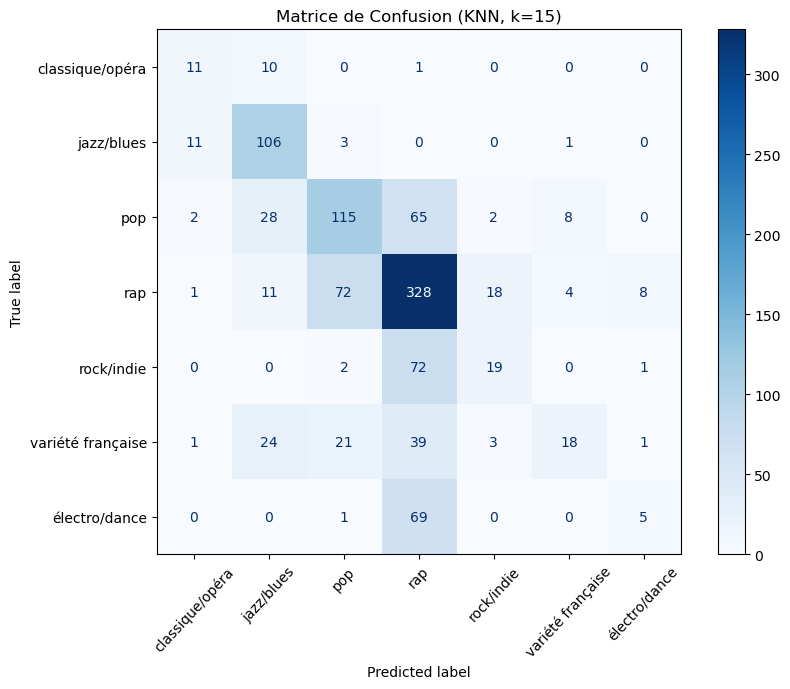


Rapport de Classification (KNN):
                   precision    recall  f1-score   support

  classique/opéra       0.42      0.50      0.46        22
       jazz/blues       0.59      0.88      0.71       121
              pop       0.54      0.52      0.53       220
              rap       0.57      0.74      0.65       442
       rock/indie       0.45      0.20      0.28        94
variété française       0.58      0.17      0.26       107
    électro/dance       0.33      0.07      0.11        75

         accuracy                           0.56      1081
        macro avg       0.50      0.44      0.43      1081
     weighted avg       0.54      0.56      0.52      1081



In [46]:
# Affiche un titre pour indiquer le début de la section de classification avec KNeighborsClassifier
print("\n--- Classification (KNeighborsClassifier pour prédire 'genre') ---")


# Création d'un pipeline de machine learning pour la classification
# Le pipeline enchaîne deux étapes principales :
# 1. 'scaler' : StandardScaler() standardise les features (moyenne 0, écart-type 1)
#    - Cela est crucial pour KNN, car il se base sur des distances : toutes les features doivent être sur la même échelle.
# 2. 'classifier' : KNeighborsClassifier(n_neighbors=15) applique l'algorithme KNN pour la classification
#    - n_neighbors=15 signifie que la classe prédite sera celle la plus fréquente parmi les 7 voisins les plus proches.
#    - Ce paramètre (k=15) est un choix courant, mais il peut être optimisé via validation croisée.
pipeline_knn_clf = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=15, metric='cosine'))
    ])

# Sélection des features pour la classification avec KNN
# On extrait du DataFrame 'df' les colonnes suivantes :
# - 'valence' : mesure la positivité de la chanson (valeur entre 0 et 1)
# - 'energy' : mesure l'intensité de la chanson (valeur entre 0 et 1)
# - 'danceability' : mesure à quel point la chanson est dansante (valeur entre 0 et 1)
# - 'acousticness' : probabilité que la chanson soit acoustique (valeur entre 0 et 1)
# - 'tempo' : tempo de la chanson en battements par minute (BPM)
# - 'loudness' : volume sonore moyen de la chanson (en décibels)
# Ces colonnes sont sélectionnées car elles sont pertinentes pour caractériser et différencier les genres musicaux.
X_class_KNN = df.loc[:, ['valence', 'energy', 'danceability', 'acousticness', 'tempo', 'loudness']]


# Sélection de la variable cible (target) pour la classification
# Ici, on utilise la colonne 'genre' du DataFrame 'df'
y_class_KNN = df['genre']

# Instanciation de l'encodeur de labels
# LabelEncoder va transformer les genres musicaux (catégories textuelles) en entiers
le = LabelEncoder()

# Encodage de la variable cible
# Chaque genre unique est transformé en un entier unique (ex : 'pop' -> 0, 'rock' -> 1, etc.)
# Cela permet de rendre la cible compatible avec les algorithmes de classification de scikit-learn
y_class_KNN_encoded = le.fit_transform(y_class_KNN)


# Division des données en ensembles d'entraînement et de test pour la classification KNN

# On utilise train_test_split pour séparer les features (X_class_KNN) et la cible encodée (y_class_KNN_encoded)
# test_size=0.2 : 20% des données seront utilisées pour le test, 80% pour l'entraînement
# random_state=42 : fixe la graine aléatoire pour garantir la reproductibilité des résultats
# stratify=y_class_KNN_encoded : garantit que la proportion de chaque classe (genre) est respectée dans les deux ensembles,
# ce qui est crucial en cas de déséquilibre des classes

X_train_KNN, X_test_KNN, y_train_KNN, y_test_KNN = train_test_split(
    X_class_KNN,                # Features sélectionnées pour la classification
    y_class_KNN_encoded,        # Cible encodée en entiers
    test_size=0.2,              # Pourcentage des données dans l'ensemble de test
    random_state=42,            # Graine pour la reproductibilité
    stratify=y_class_KNN_encoded # Strate sur la cible pour équilibrer les classes dans chaque ensemble
)


# Pour KNN, la méthode .fit() ne construit pas un modèle complexe :
# Elle se contente de stocker les données d'entraînement, car l'algorithme KNN va comparer les nouveaux échantillons
# directement à ces données lors de la prédiction.
pipeline_knn_clf.fit(X_train_KNN, y_train_KNN)

# La méthode .predict() du pipeline :
# - Pour chaque échantillon, calcule la distance entre cet échantillon et tous les points d'entraînement stockés.
# - Sélectionne les k voisins les plus proches (selon la distance choisie, généralement euclidienne).
# - Attribue la classe majoritaire parmi ces voisins comme prédiction.

# Prédictions sur l'ensemble d'entraînement (permet de mesurer l'overfitting)
y_pred_knn_clf_train = pipeline_knn_clf.predict(X_train_KNN)

# Prédictions sur l'ensemble de test (permet d'évaluer la généralisation du modèle)
y_pred_knn_clf_test = pipeline_knn_clf.predict(X_test_KNN)


# Calcul de l'accuracy (taux de bonnes prédictions) sur l'ensemble d'entraînement
accuracy_knn_clf_train = accuracy_score(y_train_KNN, y_pred_knn_clf_train)
# Affichage formaté de l'accuracy d'entraînement avec 4 décimales
print(f"Modèle de Classification (KNN, k=15) - Accuracy sur l'ensemble d'entraînement: {accuracy_knn_clf_train:.4f}")

# Calcul de l'accuracy sur l'ensemble de test
accuracy_knn_clf_test = accuracy_score(y_test_KNN, y_pred_knn_clf_test)
# Affichage formaté de l'accuracy de test avec 4 décimales
print(f"Modèle de Classification (KNN, k=15) - Accuracy sur l'ensemble de test: {accuracy_knn_clf_test:.4f}")


# Calcul de la matrice de confusion pour le modèle KNN sur l'ensemble de test
# La matrice de confusion permet de visualiser le nombre de prédictions correctes et incorrectes pour chaque classe
cm_knn = confusion_matrix(y_test_KNN, y_pred_knn_clf_test)

# Création de l'objet d'affichage avec les noms de genres
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=genre)

# Création d'une figure plus large pour éviter le chevauchement
fig, ax = plt.subplots(figsize=(9, 7))
disp_knn.plot(cmap='Blues', ax=ax, xticks_rotation=47)  # xticks_rotation=47 incline les labels de l'axe x

plt.title("Matrice de Confusion (KNN, k=15)")
plt.tight_layout()  # Ajuste automatiquement les marges pour éviter que les labels soient coupés
plt.show()


# Affiche un titre pour séparer visuellement le rapport de classification dans la console
print("\nRapport de Classification (KNN):")

# Affiche un rapport détaillé sur les performances du modèle KNN pour chaque genre musical (classe)
# classification_report calcule et affiche les métriques suivantes pour chaque classe :
# - precision : proportion de prédictions correctes parmi toutes les prédictions positives pour cette classe
# - recall (rappel) : proportion de prédictions correctes parmi toutes les vraies instances de cette classe
# - f1-score : moyenne harmonique entre la précision et le rappel, mesure globale de la performance
# - support : nombre d'échantillons réels de chaque classe dans l'ensemble de test
# L'argument target_names=genre permet d'afficher les noms des genres au lieu des indices numériques.
# Attention : la variable 'genre' doit contenir la liste ordonnée des noms de genres correspondant à l'encodage utilisé (ex : le.classes_)
print(classification_report(y_test_KNN, y_pred_knn_clf_test, target_names=genre))




## ML supervisé : KNN (k=20, test_size=0.2, metric='cosine')


--- Classification (KNeighborsClassifier pour prédire 'genre') ---
Modèle de Classification (KNN, k=20) - Accuracy sur l'ensemble d'entraînement: 0.6064
Modèle de Classification (KNN, k=20) - Accuracy sur l'ensemble de test: 0.5689


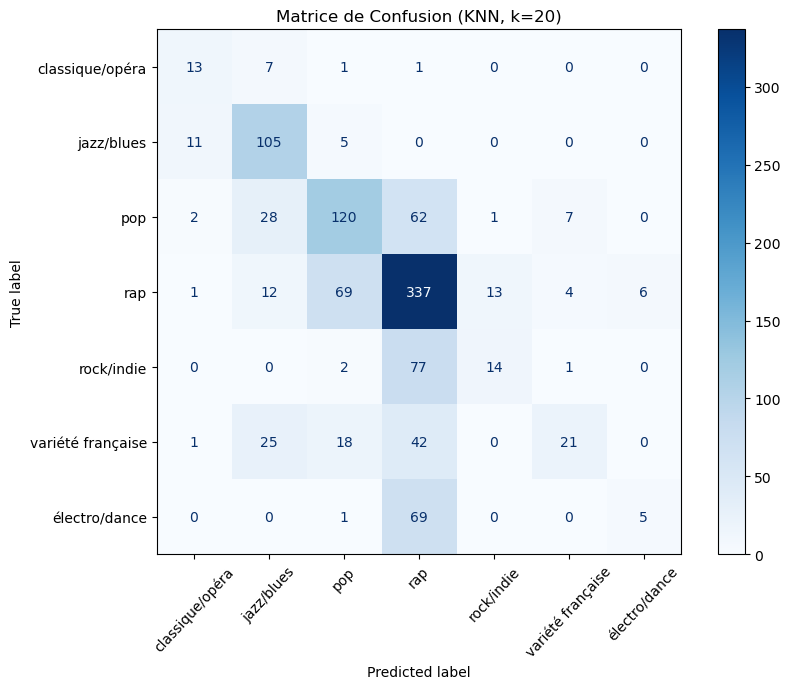


Rapport de Classification (KNN):
                   precision    recall  f1-score   support

  classique/opéra       0.46      0.59      0.52        22
       jazz/blues       0.59      0.87      0.70       121
              pop       0.56      0.55      0.55       220
              rap       0.57      0.76      0.65       442
       rock/indie       0.50      0.15      0.23        94
variété française       0.64      0.20      0.30       107
    électro/dance       0.45      0.07      0.12        75

         accuracy                           0.57      1081
        macro avg       0.54      0.45      0.44      1081
     weighted avg       0.56      0.57      0.53      1081



In [47]:
# Affiche un titre pour indiquer le début de la section de classification avec KNeighborsClassifier
print("\n--- Classification (KNeighborsClassifier pour prédire 'genre') ---")


# Création d'un pipeline de machine learning pour la classification
# Le pipeline enchaîne deux étapes principales :
# 1. 'scaler' : StandardScaler() standardise les features (moyenne 0, écart-type 1)
#    - Cela est crucial pour KNN, car il se base sur des distances : toutes les features doivent être sur la même échelle.
# 2. 'classifier' : KNeighborsClassifier(n_neighbors=20) applique l'algorithme KNN pour la classification
#    - n_neighbors=20 signifie que la classe prédite sera celle la plus fréquente parmi les 7 voisins les plus proches.
#    - Ce paramètre (k=20) est un choix courant, mais il peut être optimisé via validation croisée.
pipeline_knn_clf = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=20, metric='cosine'))
    ])

# Sélection des features pour la classification avec KNN
# On extrait du DataFrame 'df' les colonnes suivantes :
# - 'valence' : mesure la positivité de la chanson (valeur entre 0 et 1)
# - 'energy' : mesure l'intensité de la chanson (valeur entre 0 et 1)
# - 'danceability' : mesure à quel point la chanson est dansante (valeur entre 0 et 1)
# - 'acousticness' : probabilité que la chanson soit acoustique (valeur entre 0 et 1)
# - 'tempo' : tempo de la chanson en battements par minute (BPM)
# - 'loudness' : volume sonore moyen de la chanson (en décibels)
# Ces colonnes sont sélectionnées car elles sont pertinentes pour caractériser et différencier les genres musicaux.
X_class_KNN = df.loc[:, ['valence', 'energy', 'danceability', 'acousticness', 'tempo', 'loudness']]


# Sélection de la variable cible (target) pour la classification
# Ici, on utilise la colonne 'genre' du DataFrame 'df'
y_class_KNN = df['genre']

# Instanciation de l'encodeur de labels
# LabelEncoder va transformer les genres musicaux (catégories textuelles) en entiers
le = LabelEncoder()

# Encodage de la variable cible
# Chaque genre unique est transformé en un entier unique (ex : 'pop' -> 0, 'rock' -> 1, etc.)
# Cela permet de rendre la cible compatible avec les algorithmes de classification de scikit-learn
y_class_KNN_encoded = le.fit_transform(y_class_KNN)


# Division des données en ensembles d'entraînement et de test pour la classification KNN

# On utilise train_test_split pour séparer les features (X_class_KNN) et la cible encodée (y_class_KNN_encoded)
# test_size=0.2 : 20% des données seront utilisées pour le test, 80% pour l'entraînement
# random_state=42 : fixe la graine aléatoire pour garantir la reproductibilité des résultats
# stratify=y_class_KNN_encoded : garantit que la proportion de chaque classe (genre) est respectée dans les deux ensembles,
# ce qui est crucial en cas de déséquilibre des classes

X_train_KNN, X_test_KNN, y_train_KNN, y_test_KNN = train_test_split(
    X_class_KNN,                # Features sélectionnées pour la classification
    y_class_KNN_encoded,        # Cible encodée en entiers
    test_size=0.2,              # Pourcentage des données dans l'ensemble de test
    random_state=42,            # Graine pour la reproductibilité
    stratify=y_class_KNN_encoded # Strate sur la cible pour équilibrer les classes dans chaque ensemble
)


# Pour KNN, la méthode .fit() ne construit pas un modèle complexe :
# Elle se contente de stocker les données d'entraînement, car l'algorithme KNN va comparer les nouveaux échantillons
# directement à ces données lors de la prédiction.
pipeline_knn_clf.fit(X_train_KNN, y_train_KNN)

# La méthode .predict() du pipeline :
# - Pour chaque échantillon, calcule la distance entre cet échantillon et tous les points d'entraînement stockés.
# - Sélectionne les k voisins les plus proches (selon la distance choisie, généralement euclidienne).
# - Attribue la classe majoritaire parmi ces voisins comme prédiction.

# Prédictions sur l'ensemble d'entraînement (permet de mesurer l'overfitting)
y_pred_knn_clf_train = pipeline_knn_clf.predict(X_train_KNN)

# Prédictions sur l'ensemble de test (permet d'évaluer la généralisation du modèle)
y_pred_knn_clf_test = pipeline_knn_clf.predict(X_test_KNN)


# Calcul de l'accuracy (taux de bonnes prédictions) sur l'ensemble d'entraînement
accuracy_knn_clf_train = accuracy_score(y_train_KNN, y_pred_knn_clf_train)
# Affichage formaté de l'accuracy d'entraînement avec 4 décimales
print(f"Modèle de Classification (KNN, k=20) - Accuracy sur l'ensemble d'entraînement: {accuracy_knn_clf_train:.4f}")

# Calcul de l'accuracy sur l'ensemble de test
accuracy_knn_clf_test = accuracy_score(y_test_KNN, y_pred_knn_clf_test)
# Affichage formaté de l'accuracy de test avec 4 décimales
print(f"Modèle de Classification (KNN, k=20) - Accuracy sur l'ensemble de test: {accuracy_knn_clf_test:.4f}")


# Calcul de la matrice de confusion pour le modèle KNN sur l'ensemble de test
# La matrice de confusion permet de visualiser le nombre de prédictions correctes et incorrectes pour chaque classe
cm_knn = confusion_matrix(y_test_KNN, y_pred_knn_clf_test)

# Création de l'objet d'affichage avec les noms de genres
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=genre)

# Création d'une figure plus large pour éviter le chevauchement
fig, ax = plt.subplots(figsize=(9, 7))
disp_knn.plot(cmap='Blues', ax=ax, xticks_rotation=47)  # xticks_rotation=47 incline les labels de l'axe x

plt.title("Matrice de Confusion (KNN, k=20)")
plt.tight_layout()  # Ajuste automatiquement les marges pour éviter que les labels soient coupés
plt.show()


# Affiche un titre pour séparer visuellement le rapport de classification dans la console
print("\nRapport de Classification (KNN):")

# Affiche un rapport détaillé sur les performances du modèle KNN pour chaque genre musical (classe)
# classification_report calcule et affiche les métriques suivantes pour chaque classe :
# - precision : proportion de prédictions correctes parmi toutes les prédictions positives pour cette classe
# - recall (rappel) : proportion de prédictions correctes parmi toutes les vraies instances de cette classe
# - f1-score : moyenne harmonique entre la précision et le rappel, mesure globale de la performance
# - support : nombre d'échantillons réels de chaque classe dans l'ensemble de test
# L'argument target_names=genre permet d'afficher les noms des genres au lieu des indices numériques.
# Attention : la variable 'genre' doit contenir la liste ordonnée des noms de genres correspondant à l'encodage utilisé (ex : le.classes_)
print(classification_report(y_test_KNN, y_pred_knn_clf_test, target_names=genre))




## ML supervisé : KNN (k=25, test_size=0.2, metric='cosine')


--- Classification (KNeighborsClassifier pour prédire 'genre') ---
Modèle de Classification (KNN, k=25) - Accuracy sur l'ensemble d'entraînement: 0.5967
Modèle de Classification (KNN, k=25) - Accuracy sur l'ensemble de test: 0.5772


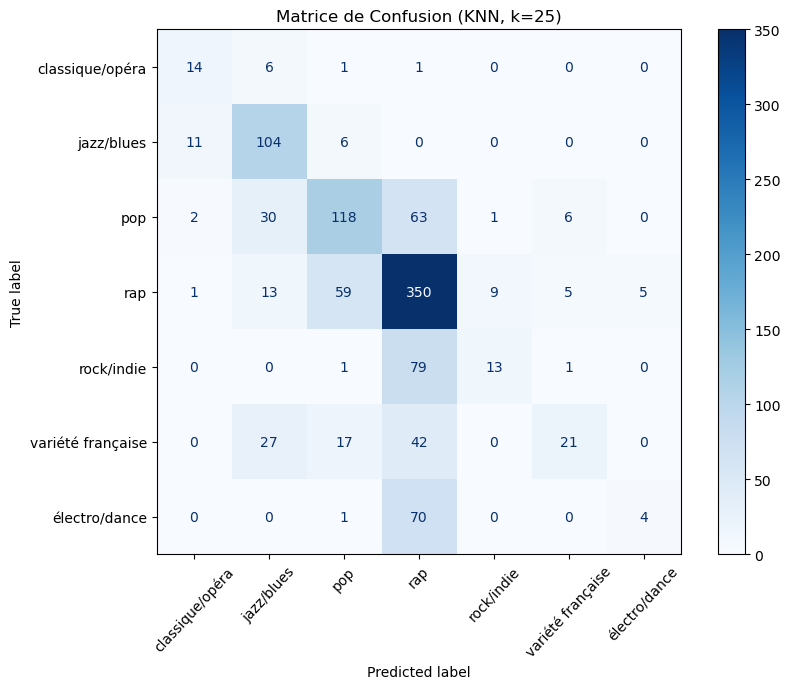


Rapport de Classification (KNN):
                   precision    recall  f1-score   support

  classique/opéra       0.50      0.64      0.56        22
       jazz/blues       0.58      0.86      0.69       121
              pop       0.58      0.54      0.56       220
              rap       0.58      0.79      0.67       442
       rock/indie       0.57      0.14      0.22        94
variété française       0.64      0.20      0.30       107
    électro/dance       0.44      0.05      0.10        75

         accuracy                           0.58      1081
        macro avg       0.55      0.46      0.44      1081
     weighted avg       0.57      0.58      0.53      1081



In [48]:
# Affiche un titre pour indiquer le début de la section de classification avec KNeighborsClassifier
print("\n--- Classification (KNeighborsClassifier pour prédire 'genre') ---")


# Création d'un pipeline de machine learning pour la classification
# Le pipeline enchaîne deux étapes principales :
# 1. 'scaler' : StandardScaler() standardise les features (moyenne 0, écart-type 1)
#    - Cela est crucial pour KNN, car il se base sur des distances : toutes les features doivent être sur la même échelle.
# 2. 'classifier' : KNeighborsClassifier(n_neighbors=25) applique l'algorithme KNN pour la classification
#    - n_neighbors=25 signifie que la classe prédite sera celle la plus fréquente parmi les 7 voisins les plus proches.
#    - Ce paramètre (k=25) est un choix courant, mais il peut être optimisé via validation croisée.
pipeline_knn_clf = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=25, metric='cosine'))
    ])

# Sélection des features pour la classification avec KNN
# On extrait du DataFrame 'df' les colonnes suivantes :
# - 'valence' : mesure la positivité de la chanson (valeur entre 0 et 1)
# - 'energy' : mesure l'intensité de la chanson (valeur entre 0 et 1)
# - 'danceability' : mesure à quel point la chanson est dansante (valeur entre 0 et 1)
# - 'acousticness' : probabilité que la chanson soit acoustique (valeur entre 0 et 1)
# - 'tempo' : tempo de la chanson en battements par minute (BPM)
# - 'loudness' : volume sonore moyen de la chanson (en décibels)
# Ces colonnes sont sélectionnées car elles sont pertinentes pour caractériser et différencier les genres musicaux.
X_class_KNN = df.loc[:, ['valence', 'energy', 'danceability', 'acousticness', 'tempo', 'loudness']]


# Sélection de la variable cible (target) pour la classification
# Ici, on utilise la colonne 'genre' du DataFrame 'df'
y_class_KNN = df['genre']

# Instanciation de l'encodeur de labels
# LabelEncoder va transformer les genres musicaux (catégories textuelles) en entiers
le = LabelEncoder()

# Encodage de la variable cible
# Chaque genre unique est transformé en un entier unique (ex : 'pop' -> 0, 'rock' -> 1, etc.)
# Cela permet de rendre la cible compatible avec les algorithmes de classification de scikit-learn
y_class_KNN_encoded = le.fit_transform(y_class_KNN)


# Division des données en ensembles d'entraînement et de test pour la classification KNN

# On utilise train_test_split pour séparer les features (X_class_KNN) et la cible encodée (y_class_KNN_encoded)
# test_size=0.2 : 20% des données seront utilisées pour le test, 80% pour l'entraînement
# random_state=42 : fixe la graine aléatoire pour garantir la reproductibilité des résultats
# stratify=y_class_KNN_encoded : garantit que la proportion de chaque classe (genre) est respectée dans les deux ensembles,
# ce qui est crucial en cas de déséquilibre des classes

X_train_KNN, X_test_KNN, y_train_KNN, y_test_KNN = train_test_split(
    X_class_KNN,                # Features sélectionnées pour la classification
    y_class_KNN_encoded,        # Cible encodée en entiers
    test_size=0.2,              # Pourcentage des données dans l'ensemble de test
    random_state=42,            # Graine pour la reproductibilité
    stratify=y_class_KNN_encoded # Strate sur la cible pour équilibrer les classes dans chaque ensemble
)


# Pour KNN, la méthode .fit() ne construit pas un modèle complexe :
# Elle se contente de stocker les données d'entraînement, car l'algorithme KNN va comparer les nouveaux échantillons
# directement à ces données lors de la prédiction.
pipeline_knn_clf.fit(X_train_KNN, y_train_KNN)

# La méthode .predict() du pipeline :
# - Pour chaque échantillon, calcule la distance entre cet échantillon et tous les points d'entraînement stockés.
# - Sélectionne les k voisins les plus proches (selon la distance choisie, généralement euclidienne).
# - Attribue la classe majoritaire parmi ces voisins comme prédiction.

# Prédictions sur l'ensemble d'entraînement (permet de mesurer l'overfitting)
y_pred_knn_clf_train = pipeline_knn_clf.predict(X_train_KNN)

# Prédictions sur l'ensemble de test (permet d'évaluer la généralisation du modèle)
y_pred_knn_clf_test = pipeline_knn_clf.predict(X_test_KNN)


# Calcul de l'accuracy (taux de bonnes prédictions) sur l'ensemble d'entraînement
accuracy_knn_clf_train = accuracy_score(y_train_KNN, y_pred_knn_clf_train)
# Affichage formaté de l'accuracy d'entraînement avec 4 décimales
print(f"Modèle de Classification (KNN, k=25) - Accuracy sur l'ensemble d'entraînement: {accuracy_knn_clf_train:.4f}")

# Calcul de l'accuracy sur l'ensemble de test
accuracy_knn_clf_test = accuracy_score(y_test_KNN, y_pred_knn_clf_test)
# Affichage formaté de l'accuracy de test avec 4 décimales
print(f"Modèle de Classification (KNN, k=25) - Accuracy sur l'ensemble de test: {accuracy_knn_clf_test:.4f}")


# Calcul de la matrice de confusion pour le modèle KNN sur l'ensemble de test
# La matrice de confusion permet de visualiser le nombre de prédictions correctes et incorrectes pour chaque classe
cm_knn = confusion_matrix(y_test_KNN, y_pred_knn_clf_test)

# Création de l'objet d'affichage avec les noms de genres
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=genre)

# Création d'une figure plus large pour éviter le chevauchement
fig, ax = plt.subplots(figsize=(9, 7))
disp_knn.plot(cmap='Blues', ax=ax, xticks_rotation=47)  # xticks_rotation=47 incline les labels de l'axe x

plt.title("Matrice de Confusion (KNN, k=25)")
plt.tight_layout()  # Ajuste automatiquement les marges pour éviter que les labels soient coupés
plt.show()


# Affiche un titre pour séparer visuellement le rapport de classification dans la console
print("\nRapport de Classification (KNN):")

# Affiche un rapport détaillé sur les performances du modèle KNN pour chaque genre musical (classe)
# classification_report calcule et affiche les métriques suivantes pour chaque classe :
# - precision : proportion de prédictions correctes parmi toutes les prédictions positives pour cette classe
# - recall (rappel) : proportion de prédictions correctes parmi toutes les vraies instances de cette classe
# - f1-score : moyenne harmonique entre la précision et le rappel, mesure globale de la performance
# - support : nombre d'échantillons réels de chaque classe dans l'ensemble de test
# L'argument target_names=genre permet d'afficher les noms des genres au lieu des indices numériques.
# Attention : la variable 'genre' doit contenir la liste ordonnée des noms de genres correspondant à l'encodage utilisé (ex : le.classes_)
print(classification_report(y_test_KNN, y_pred_knn_clf_test, target_names=genre))




## Tableau comparatif : ML supervisé KNN (metric = 'cosine')

In [49]:
# Définition des différentes valeurs de k à tester
k_values = [5, 7, 10, 15, 20, 25]  # liste des k pour KNN

# Sélection des features pertinentes dans le DataFrame df
X = df.loc[:, ['valence', 'energy', 'danceability', 'acousticness', 'tempo', 'loudness']]

# Encodage des labels (genres) en entiers
le = LabelEncoder()                   # instanciation de l'encodeur de labels
y = le.fit_transform(df['genre'])     # transformation des genres en entiers

# Séparation des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(
    X,                                 # features
    y,                                 # cible encodée
    test_size=0.2,                     # 20% des données en test
    random_state=42,                   # pour la reproductibilité
    stratify=y                         # conserve la distribution des classes
)

# Initialisation d'une liste pour stocker les résultats de chaque k
results = []

# Boucle sur chaque valeur de k
for k in k_values:
    # Construction du pipeline scaler + KNN avec la valeur de k en cours
    pipeline = Pipeline(steps=[
        ('scaler', StandardScaler()),                                  # normalisation des données
        ('classifier', KNeighborsClassifier(n_neighbors=k, metric='cosine'))
    ])
    
    # Entraînement du modèle sur l'ensemble d'entraînement
    pipeline.fit(X_train, y_train)
    
    # Prédiction sur le train et le test
    y_pred_train = pipeline.predict(X_train)  # labels prédits sur train
    y_pred_test = pipeline.predict(X_test)    # labels prédits sur test
    
    # Calcul des métriques d'évaluation
    train_acc = accuracy_score(y_train, y_pred_train)                           # accuracy sur train
    test_acc = accuracy_score(y_test, y_pred_test)                              # accuracy sur test
    macro_prec = precision_score(y_test, y_pred_test, average='macro')          # précision moyenne macro
    macro_rec = recall_score(y_test, y_pred_test, average='macro')              # rappel moyen macro
    macro_f1 = f1_score(y_test, y_pred_test, average='macro')                   # f1-score moyen macro
    
    # Ajout des résultats dans la liste
    results.append({
        'k': k,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'macro_precision': macro_prec,
        'macro_recall': macro_rec,
        'macro_f1': macro_f1
    })

# Conversion de la liste en DataFrame pour affichage tabulaire
df_results = pd.DataFrame(results)

# Affichage du tableau comparatif
print(df_results)


    k  train_accuracy  test_accuracy  macro_precision  macro_recall  macro_f1
0   5        0.662888       0.519889         0.459836      0.455298  0.445509
1   7        0.643221       0.551341         0.489376      0.468401  0.458603
2  10        0.633503       0.550416         0.490597      0.452511  0.440234
3  15        0.617538       0.556892         0.498632      0.439694  0.427431
4  20        0.606432       0.568918         0.539586      0.454063  0.439330
5  25        0.596714       0.577243         0.554799      0.458854  0.442141


In [50]:
# Import des modules nécessaires
import time


# Configuration des paramètres à tester
k_values = [5, 7, 10, 15, 20, 25]
metrics = ['euclidean', 'cosine']
results = []

# Boucle d'évaluation des configurations
for k in k_values:
    for metric in metrics:
        # Création du pipeline avec paramètres courants
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', KNeighborsClassifier(n_neighbors=k, metric=metric))
        ])
        
        # Mesure du temps d'entraînement
        start_fit = time.time()
        pipeline.fit(X_train_KNN, y_train_KNN)
        fit_time = time.time() - start_fit
        
        # Mesure du temps de prédiction
        start_pred = time.time()
        y_pred = pipeline.predict(X_test_KNN)
        pred_time = time.time() - start_pred
        
        # Calcul des métriques
        train_accuracy = accuracy_score(y_train_KNN, pipeline.predict(X_train_KNN))
        test_accuracy = accuracy_score(y_test_KNN, y_pred)
        report = classification_report(y_test_KNN, y_pred, output_dict=True)
        
        # Stockage des résultats
        results.append({
            'k': k,
            'metric': metric,
            'train_accuracy': train_accuracy,
            'test_accuracy': test_accuracy,
            'precision_macro': report['macro avg']['precision'],
            'recall_macro': report['macro avg']['recall'],
            'f1_macro': report['macro avg']['f1-score'],
            'fit_time': fit_time,
            'pred_time': pred_time
        })

# Création du DataFrame comparatif
results_df = pd.DataFrame(results)
print("\nComparaison des configurations KNN :")
display(results_df)



Comparaison des configurations KNN :


,k,metric,train_accuracy,test_accuracy,precision_macro,recall_macro,f1_macro,fit_time,pred_time
0,5,euclidean,0.664276,0.545791,0.504516,0.472160,0.473759,0.034506,0.102445
1,5,cosine,0.662888,0.519889,0.459836,0.455298,0.445509,0.004022,0.209582
2,7,euclidean,0.654558,0.556892,0.510902,0.467652,0.471558,0.018805,0.081007
3,7,cosine,0.643221,0.551341,0.489376,0.468401,0.458603,0.016116,0.260072
4,10,euclidean,0.636974,0.575393,0.530934,0.484799,0.481426,0.000000,0.068853
5,10,cosine,0.633503,0.550416,0.490597,0.452511,0.440234,0.000000,0.227142
6,15,euclidean,0.624479,0.578168,0.573969,0.473180,0.475541,0.016070,0.050475
7,15,cosine,0.617538,0.556892,0.498632,0.439694,0.427431,0.020150,0.164690
8,20,euclidean,0.614068,0.582794,0.582900,0.468964,0.460582,0.000000,0.193603
9,20,cosine,0.606432,0.568918,0.539586,0.454063,0.439330,0.000000,0.141280


# Features : "valence, energy, danceability, acousticness, tempo"
# Target : "genre"

## ML supervisé : KNN (k=5, test_size=0.2, metric='euclidean')


--- Classification (KNeighborsClassifier pour prédire 'genre') ---
Modèle de Classification (KNN, k=5) - Accuracy sur l'ensemble d'entraînement: 0.6573
Modèle de Classification (KNN, k=5) - Accuracy sur l'ensemble de test: 0.5310


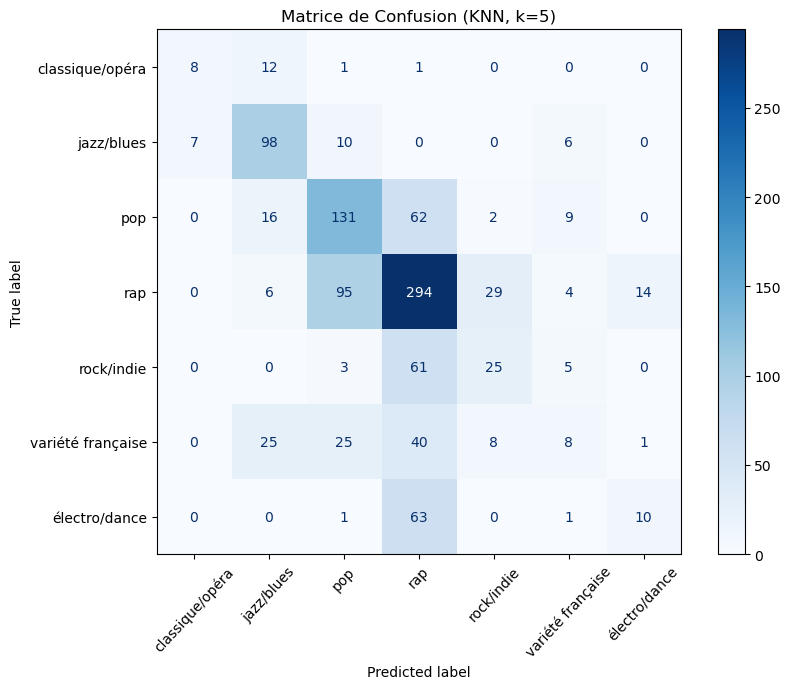


Rapport de Classification (KNN):
                   precision    recall  f1-score   support

  classique/opéra       0.53      0.36      0.43        22
       jazz/blues       0.62      0.81      0.71       121
              pop       0.49      0.60      0.54       220
              rap       0.56      0.67      0.61       442
       rock/indie       0.39      0.27      0.32        94
variété française       0.24      0.07      0.11       107
    électro/dance       0.40      0.13      0.20        75

         accuracy                           0.53      1081
        macro avg       0.46      0.42      0.42      1081
     weighted avg       0.50      0.53      0.50      1081



In [51]:
# Affiche un titre pour indiquer le début de la section de classification avec KNeighborsClassifier
print("\n--- Classification (KNeighborsClassifier pour prédire 'genre') ---")


# Création d'un pipeline de machine learning pour la classification
# Le pipeline enchaîne deux étapes principales :
# 1. 'scaler' : StandardScaler() standardise les features (moyenne 0, écart-type 1)
#    - Cela est crucial pour KNN, car il se base sur des distances : toutes les features doivent être sur la même échelle.
# 2. 'classifier' : KNeighborsClassifier(n_neighbors=5) applique l'algorithme KNN pour la classification
#    - n_neighbors=5 signifie que la classe prédite sera celle la plus fréquente parmi les 7 voisins les plus proches.
#    - Ce paramètre (k=5) est un choix courant, mais il peut être optimisé via validation croisée.
pipeline_knn_clf = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=5, metric='euclidean'))
    ])

# Sélection des features pour la classification avec KNN
# On extrait du DataFrame 'df' les colonnes suivantes :
# - 'valence' : mesure la positivité de la chanson (valeur entre 0 et 1)
# - 'energy' : mesure l'intensité de la chanson (valeur entre 0 et 1)
# - 'danceability' : mesure à quel point la chanson est dansante (valeur entre 0 et 1)
# - 'acousticness' : probabilité que la chanson soit acoustique (valeur entre 0 et 1)
# - 'tempo' : tempo de la chanson en battements par minute (BPM)
# - 'loudness' : volume sonore moyen de la chanson (en décibels)
# Ces colonnes sont sélectionnées car elles sont pertinentes pour caractériser et différencier les genres musicaux.
X_class_KNN = df.loc[:, ['valence', 'energy', 'danceability', 'acousticness', 'tempo']]


# Sélection de la variable cible (target) pour la classification
# Ici, on utilise la colonne 'genre' du DataFrame 'df'
y_class_KNN = df['genre']

# Instanciation de l'encodeur de labels
# LabelEncoder va transformer les genres musicaux (catégories textuelles) en entiers
le = LabelEncoder()

# Encodage de la variable cible
# Chaque genre unique est transformé en un entier unique (ex : 'pop' -> 0, 'rock' -> 1, etc.)
# Cela permet de rendre la cible compatible avec les algorithmes de classification de scikit-learn
y_class_KNN_encoded = le.fit_transform(y_class_KNN)


# Division des données en ensembles d'entraînement et de test pour la classification KNN

# On utilise train_test_split pour séparer les features (X_class_KNN) et la cible encodée (y_class_KNN_encoded)
# test_size=0.2 : 20% des données seront utilisées pour le test, 80% pour l'entraînement
# random_state=42 : fixe la graine aléatoire pour garantir la reproductibilité des résultats
# stratify=y_class_KNN_encoded : garantit que la proportion de chaque classe (genre) est respectée dans les deux ensembles,
# ce qui est crucial en cas de déséquilibre des classes

X_train_KNN, X_test_KNN, y_train_KNN, y_test_KNN = train_test_split(
    X_class_KNN,                # Features sélectionnées pour la classification
    y_class_KNN_encoded,        # Cible encodée en entiers
    test_size=0.2,              # Pourcentage des données dans l'ensemble de test
    random_state=42,            # Graine pour la reproductibilité
    stratify=y_class_KNN_encoded # Strate sur la cible pour équilibrer les classes dans chaque ensemble
)


# Pour KNN, la méthode .fit() ne construit pas un modèle complexe :
# Elle se contente de stocker les données d'entraînement, car l'algorithme KNN va comparer les nouveaux échantillons
# directement à ces données lors de la prédiction.
pipeline_knn_clf.fit(X_train_KNN, y_train_KNN)

# La méthode .predict() du pipeline :
# - Pour chaque échantillon, calcule la distance entre cet échantillon et tous les points d'entraînement stockés.
# - Sélectionne les k voisins les plus proches (selon la distance choisie, généralement euclidienne).
# - Attribue la classe majoritaire parmi ces voisins comme prédiction.

# Prédictions sur l'ensemble d'entraînement (permet de mesurer l'overfitting)
y_pred_knn_clf_train = pipeline_knn_clf.predict(X_train_KNN)

# Prédictions sur l'ensemble de test (permet d'évaluer la généralisation du modèle)
y_pred_knn_clf_test = pipeline_knn_clf.predict(X_test_KNN)


# Calcul de l'accuracy (taux de bonnes prédictions) sur l'ensemble d'entraînement
accuracy_knn_clf_train = accuracy_score(y_train_KNN, y_pred_knn_clf_train)
# Affichage formaté de l'accuracy d'entraînement avec 4 décimales
print(f"Modèle de Classification (KNN, k=5) - Accuracy sur l'ensemble d'entraînement: {accuracy_knn_clf_train:.4f}")

# Calcul de l'accuracy sur l'ensemble de test
accuracy_knn_clf_test = accuracy_score(y_test_KNN, y_pred_knn_clf_test)
# Affichage formaté de l'accuracy de test avec 4 décimales
print(f"Modèle de Classification (KNN, k=5) - Accuracy sur l'ensemble de test: {accuracy_knn_clf_test:.4f}")


# Calcul de la matrice de confusion pour le modèle KNN sur l'ensemble de test
# La matrice de confusion permet de visualiser le nombre de prédictions correctes et incorrectes pour chaque classe
cm_knn = confusion_matrix(y_test_KNN, y_pred_knn_clf_test)

# Création de l'objet d'affichage avec les noms de genres
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=genre)

# Création d'une figure plus large pour éviter le chevauchement
fig, ax = plt.subplots(figsize=(9, 7))
disp_knn.plot(cmap='Blues', ax=ax, xticks_rotation=47)  # xticks_rotation=47 incline les labels de l'axe x

plt.title("Matrice de Confusion (KNN, k=5)")
plt.tight_layout()  # Ajuste automatiquement les marges pour éviter que les labels soient coupés
plt.show()


# Affiche un titre pour séparer visuellement le rapport de classification dans la console
print("\nRapport de Classification (KNN):")

# Affiche un rapport détaillé sur les performances du modèle KNN pour chaque genre musical (classe)
# classification_report calcule et affiche les métriques suivantes pour chaque classe :
# - precision : proportion de prédictions correctes parmi toutes les prédictions positives pour cette classe
# - recall (rappel) : proportion de prédictions correctes parmi toutes les vraies instances de cette classe
# - f1-score : moyenne harmonique entre la précision et le rappel, mesure globale de la performance
# - support : nombre d'échantillons réels de chaque classe dans l'ensemble de test
# L'argument target_names=genre permet d'afficher les noms des genres au lieu des indices numériques.
# Attention : la variable 'genre' doit contenir la liste ordonnée des noms de genres correspondant à l'encodage utilisé (ex : le.classes_)
print(classification_report(y_test_KNN, y_pred_knn_clf_test, target_names=genre))




## ML supervisé : KNN (k=7, test_size=0.2, metric='euclidean')


--- Classification (KNeighborsClassifier pour prédire 'genre') ---
Modèle de Classification (KNN, k=7) - Accuracy sur l'ensemble d'entraînement: 0.6516
Modèle de Classification (KNN, k=7) - Accuracy sur l'ensemble de test: 0.5430


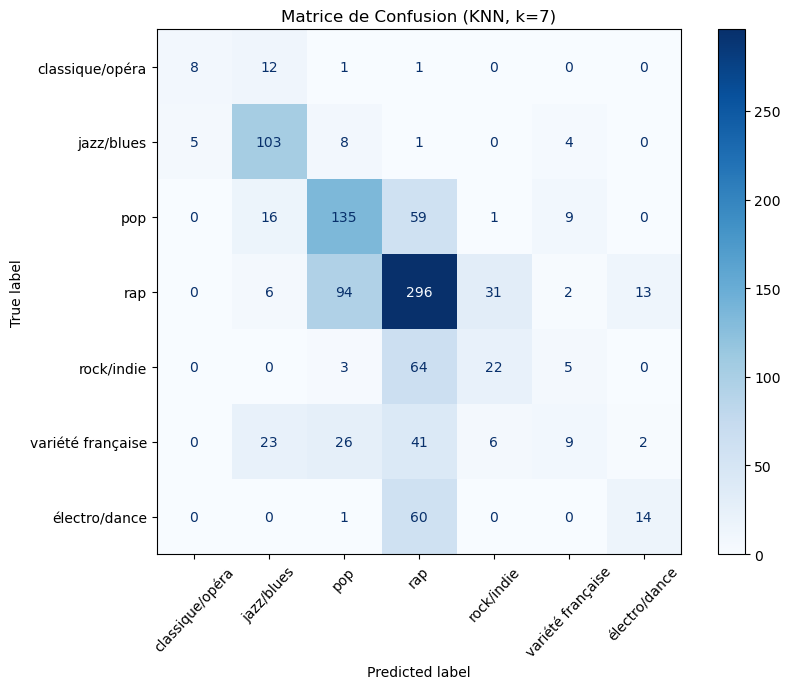


Rapport de Classification (KNN):
                   precision    recall  f1-score   support

  classique/opéra       0.62      0.36      0.46        22
       jazz/blues       0.64      0.85      0.73       121
              pop       0.50      0.61      0.55       220
              rap       0.57      0.67      0.61       442
       rock/indie       0.37      0.23      0.29        94
variété française       0.31      0.08      0.13       107
    électro/dance       0.48      0.19      0.27        75

         accuracy                           0.54      1081
        macro avg       0.50      0.43      0.43      1081
     weighted avg       0.52      0.54      0.51      1081



In [52]:
# Affiche un titre pour indiquer le début de la section de classification avec KNeighborsClassifier
print("\n--- Classification (KNeighborsClassifier pour prédire 'genre') ---")


# Création d'un pipeline de machine learning pour la classification
# Le pipeline enchaîne deux étapes principales :
# 1. 'scaler' : StandardScaler() standardise les features (moyenne 0, écart-type 1)
#    - Cela est crucial pour KNN, car il se base sur des distances : toutes les features doivent être sur la même échelle.
# 2. 'classifier' : KNeighborsClassifier(n_neighbors=7) applique l'algorithme KNN pour la classification
#    - n_neighbors=7 signifie que la classe prédite sera celle la plus fréquente parmi les 7 voisins les plus proches.
#    - Ce paramètre (k=7) est un choix courant, mais il peut être optimisé via validation croisée.
pipeline_knn_clf = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=7, metric='euclidean'))
    ])

# Sélection des features pour la classification avec KNN
# On extrait du DataFrame 'df' les colonnes suivantes :
# - 'valence' : mesure la positivité de la chanson (valeur entre 0 et 1)
# - 'energy' : mesure l'intensité de la chanson (valeur entre 0 et 1)
# - 'danceability' : mesure à quel point la chanson est dansante (valeur entre 0 et 1)
# - 'acousticness' : probabilité que la chanson soit acoustique (valeur entre 0 et 1)
# - 'tempo' : tempo de la chanson en battements par minute (BPM)
# - 'loudness' : volume sonore moyen de la chanson (en décibels)
# Ces colonnes sont sélectionnées car elles sont pertinentes pour caractériser et différencier les genres musicaux.
X_class_KNN = df.loc[:, ['valence', 'energy', 'danceability', 'acousticness', 'tempo']]


# Sélection de la variable cible (target) pour la classification
# Ici, on utilise la colonne 'genre' du DataFrame 'df'
y_class_KNN = df['genre']

# Instanciation de l'encodeur de labels
# LabelEncoder va transformer les genres musicaux (catégories textuelles) en entiers
le = LabelEncoder()

# Encodage de la variable cible
# Chaque genre unique est transformé en un entier unique (ex : 'pop' -> 0, 'rock' -> 1, etc.)
# Cela permet de rendre la cible compatible avec les algorithmes de classification de scikit-learn
y_class_KNN_encoded = le.fit_transform(y_class_KNN)


# Division des données en ensembles d'entraînement et de test pour la classification KNN

# On utilise train_test_split pour séparer les features (X_class_KNN) et la cible encodée (y_class_KNN_encoded)
# test_size=0.2 : 20% des données seront utilisées pour le test, 80% pour l'entraînement
# random_state=42 : fixe la graine aléatoire pour garantir la reproductibilité des résultats
# stratify=y_class_KNN_encoded : garantit que la proportion de chaque classe (genre) est respectée dans les deux ensembles,
# ce qui est crucial en cas de déséquilibre des classes

X_train_KNN, X_test_KNN, y_train_KNN, y_test_KNN = train_test_split(
    X_class_KNN,                # Features sélectionnées pour la classification
    y_class_KNN_encoded,        # Cible encodée en entiers
    test_size=0.2,              # Pourcentage des données dans l'ensemble de test
    random_state=42,            # Graine pour la reproductibilité
    stratify=y_class_KNN_encoded # Strate sur la cible pour équilibrer les classes dans chaque ensemble
)


# Pour KNN, la méthode .fit() ne construit pas un modèle complexe :
# Elle se contente de stocker les données d'entraînement, car l'algorithme KNN va comparer les nouveaux échantillons
# directement à ces données lors de la prédiction.
pipeline_knn_clf.fit(X_train_KNN, y_train_KNN)

# La méthode .predict() du pipeline :
# - Pour chaque échantillon, calcule la distance entre cet échantillon et tous les points d'entraînement stockés.
# - Sélectionne les k voisins les plus proches (selon la distance choisie, généralement euclidienne).
# - Attribue la classe majoritaire parmi ces voisins comme prédiction.

# Prédictions sur l'ensemble d'entraînement (permet de mesurer l'overfitting)
y_pred_knn_clf_train = pipeline_knn_clf.predict(X_train_KNN)

# Prédictions sur l'ensemble de test (permet d'évaluer la généralisation du modèle)
y_pred_knn_clf_test = pipeline_knn_clf.predict(X_test_KNN)


# Calcul de l'accuracy (taux de bonnes prédictions) sur l'ensemble d'entraînement
accuracy_knn_clf_train = accuracy_score(y_train_KNN, y_pred_knn_clf_train)
# Affichage formaté de l'accuracy d'entraînement avec 4 décimales
print(f"Modèle de Classification (KNN, k=7) - Accuracy sur l'ensemble d'entraînement: {accuracy_knn_clf_train:.4f}")

# Calcul de l'accuracy sur l'ensemble de test
accuracy_knn_clf_test = accuracy_score(y_test_KNN, y_pred_knn_clf_test)
# Affichage formaté de l'accuracy de test avec 4 décimales
print(f"Modèle de Classification (KNN, k=7) - Accuracy sur l'ensemble de test: {accuracy_knn_clf_test:.4f}")


# Calcul de la matrice de confusion pour le modèle KNN sur l'ensemble de test
# La matrice de confusion permet de visualiser le nombre de prédictions correctes et incorrectes pour chaque classe
cm_knn = confusion_matrix(y_test_KNN, y_pred_knn_clf_test)

# Création de l'objet d'affichage avec les noms de genres
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=genre)

# Création d'une figure plus large pour éviter le chevauchement
fig, ax = plt.subplots(figsize=(9, 7))
disp_knn.plot(cmap='Blues', ax=ax, xticks_rotation=47)  # xticks_rotation=47 incline les labels de l'axe x

plt.title("Matrice de Confusion (KNN, k=7)")
plt.tight_layout()  # Ajuste automatiquement les marges pour éviter que les labels soient coupés
plt.show()


# Affiche un titre pour séparer visuellement le rapport de classification dans la console
print("\nRapport de Classification (KNN):")

# Affiche un rapport détaillé sur les performances du modèle KNN pour chaque genre musical (classe)
# classification_report calcule et affiche les métriques suivantes pour chaque classe :
# - precision : proportion de prédictions correctes parmi toutes les prédictions positives pour cette classe
# - recall (rappel) : proportion de prédictions correctes parmi toutes les vraies instances de cette classe
# - f1-score : moyenne harmonique entre la précision et le rappel, mesure globale de la performance
# - support : nombre d'échantillons réels de chaque classe dans l'ensemble de test
# L'argument target_names=genre permet d'afficher les noms des genres au lieu des indices numériques.
# Attention : la variable 'genre' doit contenir la liste ordonnée des noms de genres correspondant à l'encodage utilisé (ex : le.classes_)
print(classification_report(y_test_KNN, y_pred_knn_clf_test, target_names=genre))




## ML supervisé : KNN (k=10, test_size=0.2, metric='euclidean')


--- Classification (KNeighborsClassifier pour prédire 'genre') ---
Modèle de Classification (KNN, k=10) - Accuracy sur l'ensemble d'entraînement: 0.6372
Modèle de Classification (KNN, k=10) - Accuracy sur l'ensemble de test: 0.5671


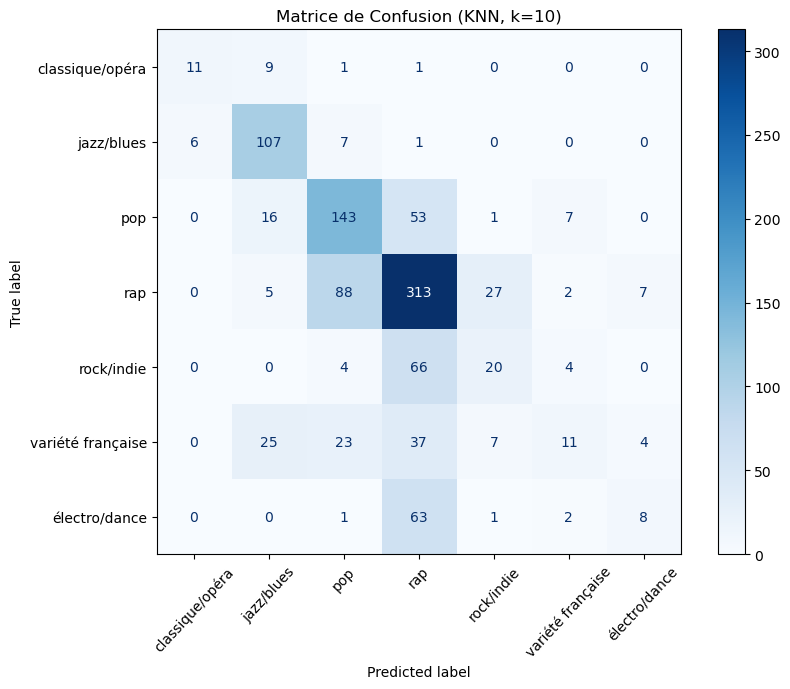


Rapport de Classification (KNN):
                   precision    recall  f1-score   support

  classique/opéra       0.65      0.50      0.56        22
       jazz/blues       0.66      0.88      0.76       121
              pop       0.54      0.65      0.59       220
              rap       0.59      0.71      0.64       442
       rock/indie       0.36      0.21      0.27        94
variété française       0.42      0.10      0.17       107
    électro/dance       0.42      0.11      0.17        75

         accuracy                           0.57      1081
        macro avg       0.52      0.45      0.45      1081
     weighted avg       0.54      0.57      0.53      1081



In [53]:
# Affiche un titre pour indiquer le début de la section de classification avec KNeighborsClassifier
print("\n--- Classification (KNeighborsClassifier pour prédire 'genre') ---")


# Création d'un pipeline de machine learning pour la classification
# Le pipeline enchaîne deux étapes principales :
# 1. 'scaler' : StandardScaler() standardise les features (moyenne 0, écart-type 1)
#    - Cela est crucial pour KNN, car il se base sur des distances : toutes les features doivent être sur la même échelle.
# 2. 'classifier' : KNeighborsClassifier(n_neighbors=10) applique l'algorithme KNN pour la classification
#    - n_neighbors=10 signifie que la classe prédite sera celle la plus fréquente parmi les 7 voisins les plus proches.
#    - Ce paramètre (k=10) est un choix courant, mais il peut être optimisé via validation croisée.
pipeline_knn_clf = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=10, metric='euclidean'))
    ])

# Sélection des features pour la classification avec KNN
# On extrait du DataFrame 'df' les colonnes suivantes :
# - 'valence' : mesure la positivité de la chanson (valeur entre 0 et 1)
# - 'energy' : mesure l'intensité de la chanson (valeur entre 0 et 1)
# - 'danceability' : mesure à quel point la chanson est dansante (valeur entre 0 et 1)
# - 'acousticness' : probabilité que la chanson soit acoustique (valeur entre 0 et 1)
# - 'tempo' : tempo de la chanson en battements par minute (BPM)
# - 'loudness' : volume sonore moyen de la chanson (en décibels)
# Ces colonnes sont sélectionnées car elles sont pertinentes pour caractériser et différencier les genres musicaux.
X_class_KNN = df.loc[:, ['valence', 'energy', 'danceability', 'acousticness', 'tempo']]


# Sélection de la variable cible (target) pour la classification
# Ici, on utilise la colonne 'genre' du DataFrame 'df'
y_class_KNN = df['genre']

# Instanciation de l'encodeur de labels
# LabelEncoder va transformer les genres musicaux (catégories textuelles) en entiers
le = LabelEncoder()

# Encodage de la variable cible
# Chaque genre unique est transformé en un entier unique (ex : 'pop' -> 0, 'rock' -> 1, etc.)
# Cela permet de rendre la cible compatible avec les algorithmes de classification de scikit-learn
y_class_KNN_encoded = le.fit_transform(y_class_KNN)


# Division des données en ensembles d'entraînement et de test pour la classification KNN

# On utilise train_test_split pour séparer les features (X_class_KNN) et la cible encodée (y_class_KNN_encoded)
# test_size=0.2 : 20% des données seront utilisées pour le test, 80% pour l'entraînement
# random_state=42 : fixe la graine aléatoire pour garantir la reproductibilité des résultats
# stratify=y_class_KNN_encoded : garantit que la proportion de chaque classe (genre) est respectée dans les deux ensembles,
# ce qui est crucial en cas de déséquilibre des classes

X_train_KNN, X_test_KNN, y_train_KNN, y_test_KNN = train_test_split(
    X_class_KNN,                # Features sélectionnées pour la classification
    y_class_KNN_encoded,        # Cible encodée en entiers
    test_size=0.2,              # Pourcentage des données dans l'ensemble de test
    random_state=42,            # Graine pour la reproductibilité
    stratify=y_class_KNN_encoded # Strate sur la cible pour équilibrer les classes dans chaque ensemble
)


# Pour KNN, la méthode .fit() ne construit pas un modèle complexe :
# Elle se contente de stocker les données d'entraînement, car l'algorithme KNN va comparer les nouveaux échantillons
# directement à ces données lors de la prédiction.
pipeline_knn_clf.fit(X_train_KNN, y_train_KNN)

# La méthode .predict() du pipeline :
# - Pour chaque échantillon, calcule la distance entre cet échantillon et tous les points d'entraînement stockés.
# - Sélectionne les k voisins les plus proches (selon la distance choisie, généralement euclidienne).
# - Attribue la classe majoritaire parmi ces voisins comme prédiction.

# Prédictions sur l'ensemble d'entraînement (permet de mesurer l'overfitting)
y_pred_knn_clf_train = pipeline_knn_clf.predict(X_train_KNN)

# Prédictions sur l'ensemble de test (permet d'évaluer la généralisation du modèle)
y_pred_knn_clf_test = pipeline_knn_clf.predict(X_test_KNN)


# Calcul de l'accuracy (taux de bonnes prédictions) sur l'ensemble d'entraînement
accuracy_knn_clf_train = accuracy_score(y_train_KNN, y_pred_knn_clf_train)
# Affichage formaté de l'accuracy d'entraînement avec 4 décimales
print(f"Modèle de Classification (KNN, k=10) - Accuracy sur l'ensemble d'entraînement: {accuracy_knn_clf_train:.4f}")

# Calcul de l'accuracy sur l'ensemble de test
accuracy_knn_clf_test = accuracy_score(y_test_KNN, y_pred_knn_clf_test)
# Affichage formaté de l'accuracy de test avec 4 décimales
print(f"Modèle de Classification (KNN, k=10) - Accuracy sur l'ensemble de test: {accuracy_knn_clf_test:.4f}")


# Calcul de la matrice de confusion pour le modèle KNN sur l'ensemble de test
# La matrice de confusion permet de visualiser le nombre de prédictions correctes et incorrectes pour chaque classe
cm_knn = confusion_matrix(y_test_KNN, y_pred_knn_clf_test)

# Création de l'objet d'affichage avec les noms de genres
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=genre)

# Création d'une figure plus large pour éviter le chevauchement
fig, ax = plt.subplots(figsize=(9, 7))
disp_knn.plot(cmap='Blues', ax=ax, xticks_rotation=47)  # xticks_rotation=47 incline les labels de l'axe x

plt.title("Matrice de Confusion (KNN, k=10)")
plt.tight_layout()  # Ajuste automatiquement les marges pour éviter que les labels soient coupés
plt.show()


# Affiche un titre pour séparer visuellement le rapport de classification dans la console
print("\nRapport de Classification (KNN):")

# Affiche un rapport détaillé sur les performances du modèle KNN pour chaque genre musical (classe)
# classification_report calcule et affiche les métriques suivantes pour chaque classe :
# - precision : proportion de prédictions correctes parmi toutes les prédictions positives pour cette classe
# - recall (rappel) : proportion de prédictions correctes parmi toutes les vraies instances de cette classe
# - f1-score : moyenne harmonique entre la précision et le rappel, mesure globale de la performance
# - support : nombre d'échantillons réels de chaque classe dans l'ensemble de test
# L'argument target_names=genre permet d'afficher les noms des genres au lieu des indices numériques.
# Attention : la variable 'genre' doit contenir la liste ordonnée des noms de genres correspondant à l'encodage utilisé (ex : le.classes_)
print(classification_report(y_test_KNN, y_pred_knn_clf_test, target_names=genre))




## ML supervisé : KNN (k=15, test_size=0.2, metric='euclidean')


--- Classification (KNeighborsClassifier pour prédire 'genre') ---
Modèle de Classification (KNN, k=15) - Accuracy sur l'ensemble d'entraînement: 0.6240
Modèle de Classification (KNN, k=15) - Accuracy sur l'ensemble de test: 0.5717


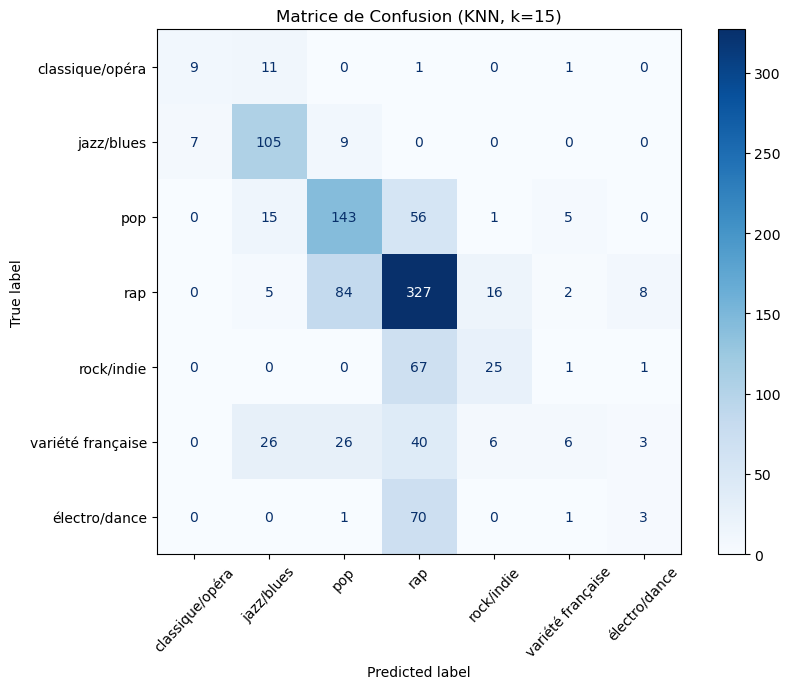


Rapport de Classification (KNN):
                   precision    recall  f1-score   support

  classique/opéra       0.56      0.41      0.47        22
       jazz/blues       0.65      0.87      0.74       121
              pop       0.54      0.65      0.59       220
              rap       0.58      0.74      0.65       442
       rock/indie       0.52      0.27      0.35        94
variété française       0.38      0.06      0.10       107
    électro/dance       0.20      0.04      0.07        75

         accuracy                           0.57      1081
        macro avg       0.49      0.43      0.43      1081
     weighted avg       0.53      0.57      0.52      1081



In [54]:
# Affiche un titre pour indiquer le début de la section de classification avec KNeighborsClassifier
print("\n--- Classification (KNeighborsClassifier pour prédire 'genre') ---")


# Création d'un pipeline de machine learning pour la classification
# Le pipeline enchaîne deux étapes principales :
# 1. 'scaler' : StandardScaler() standardise les features (moyenne 0, écart-type 1)
#    - Cela est crucial pour KNN, car il se base sur des distances : toutes les features doivent être sur la même échelle.
# 2. 'classifier' : KNeighborsClassifier(n_neighbors=15) applique l'algorithme KNN pour la classification
#    - n_neighbors=15 signifie que la classe prédite sera celle la plus fréquente parmi les 7 voisins les plus proches.
#    - Ce paramètre (k=15) est un choix courant, mais il peut être optimisé via validation croisée.
pipeline_knn_clf = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=15, metric='euclidean'))
    ])

# Sélection des features pour la classification avec KNN
# On extrait du DataFrame 'df' les colonnes suivantes :
# - 'valence' : mesure la positivité de la chanson (valeur entre 0 et 1)
# - 'energy' : mesure l'intensité de la chanson (valeur entre 0 et 1)
# - 'danceability' : mesure à quel point la chanson est dansante (valeur entre 0 et 1)
# - 'acousticness' : probabilité que la chanson soit acoustique (valeur entre 0 et 1)
# - 'tempo' : tempo de la chanson en battements par minute (BPM)
# - 'loudness' : volume sonore moyen de la chanson (en décibels)
# Ces colonnes sont sélectionnées car elles sont pertinentes pour caractériser et différencier les genres musicaux.
X_class_KNN = df.loc[:, ['valence', 'energy', 'danceability', 'acousticness', 'tempo']]


# Sélection de la variable cible (target) pour la classification
# Ici, on utilise la colonne 'genre' du DataFrame 'df'
y_class_KNN = df['genre']

# Instanciation de l'encodeur de labels
# LabelEncoder va transformer les genres musicaux (catégories textuelles) en entiers
le = LabelEncoder()

# Encodage de la variable cible
# Chaque genre unique est transformé en un entier unique (ex : 'pop' -> 0, 'rock' -> 1, etc.)
# Cela permet de rendre la cible compatible avec les algorithmes de classification de scikit-learn
y_class_KNN_encoded = le.fit_transform(y_class_KNN)


# Division des données en ensembles d'entraînement et de test pour la classification KNN

# On utilise train_test_split pour séparer les features (X_class_KNN) et la cible encodée (y_class_KNN_encoded)
# test_size=0.2 : 20% des données seront utilisées pour le test, 80% pour l'entraînement
# random_state=42 : fixe la graine aléatoire pour garantir la reproductibilité des résultats
# stratify=y_class_KNN_encoded : garantit que la proportion de chaque classe (genre) est respectée dans les deux ensembles,
# ce qui est crucial en cas de déséquilibre des classes

X_train_KNN, X_test_KNN, y_train_KNN, y_test_KNN = train_test_split(
    X_class_KNN,                # Features sélectionnées pour la classification
    y_class_KNN_encoded,        # Cible encodée en entiers
    test_size=0.2,              # Pourcentage des données dans l'ensemble de test
    random_state=42,            # Graine pour la reproductibilité
    stratify=y_class_KNN_encoded # Strate sur la cible pour équilibrer les classes dans chaque ensemble
)


# Pour KNN, la méthode .fit() ne construit pas un modèle complexe :
# Elle se contente de stocker les données d'entraînement, car l'algorithme KNN va comparer les nouveaux échantillons
# directement à ces données lors de la prédiction.
pipeline_knn_clf.fit(X_train_KNN, y_train_KNN)

# La méthode .predict() du pipeline :
# - Pour chaque échantillon, calcule la distance entre cet échantillon et tous les points d'entraînement stockés.
# - Sélectionne les k voisins les plus proches (selon la distance choisie, généralement euclidienne).
# - Attribue la classe majoritaire parmi ces voisins comme prédiction.

# Prédictions sur l'ensemble d'entraînement (permet de mesurer l'overfitting)
y_pred_knn_clf_train = pipeline_knn_clf.predict(X_train_KNN)

# Prédictions sur l'ensemble de test (permet d'évaluer la généralisation du modèle)
y_pred_knn_clf_test = pipeline_knn_clf.predict(X_test_KNN)


# Calcul de l'accuracy (taux de bonnes prédictions) sur l'ensemble d'entraînement
accuracy_knn_clf_train = accuracy_score(y_train_KNN, y_pred_knn_clf_train)
# Affichage formaté de l'accuracy d'entraînement avec 4 décimales
print(f"Modèle de Classification (KNN, k=15) - Accuracy sur l'ensemble d'entraînement: {accuracy_knn_clf_train:.4f}")

# Calcul de l'accuracy sur l'ensemble de test
accuracy_knn_clf_test = accuracy_score(y_test_KNN, y_pred_knn_clf_test)
# Affichage formaté de l'accuracy de test avec 4 décimales
print(f"Modèle de Classification (KNN, k=15) - Accuracy sur l'ensemble de test: {accuracy_knn_clf_test:.4f}")


# Calcul de la matrice de confusion pour le modèle KNN sur l'ensemble de test
# La matrice de confusion permet de visualiser le nombre de prédictions correctes et incorrectes pour chaque classe
cm_knn = confusion_matrix(y_test_KNN, y_pred_knn_clf_test)

# Création de l'objet d'affichage avec les noms de genres
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=genre)

# Création d'une figure plus large pour éviter le chevauchement
fig, ax = plt.subplots(figsize=(9, 7))
disp_knn.plot(cmap='Blues', ax=ax, xticks_rotation=47)  # xticks_rotation=47 incline les labels de l'axe x

plt.title("Matrice de Confusion (KNN, k=15)")
plt.tight_layout()  # Ajuste automatiquement les marges pour éviter que les labels soient coupés
plt.show()


# Affiche un titre pour séparer visuellement le rapport de classification dans la console
print("\nRapport de Classification (KNN):")

# Affiche un rapport détaillé sur les performances du modèle KNN pour chaque genre musical (classe)
# classification_report calcule et affiche les métriques suivantes pour chaque classe :
# - precision : proportion de prédictions correctes parmi toutes les prédictions positives pour cette classe
# - recall (rappel) : proportion de prédictions correctes parmi toutes les vraies instances de cette classe
# - f1-score : moyenne harmonique entre la précision et le rappel, mesure globale de la performance
# - support : nombre d'échantillons réels de chaque classe dans l'ensemble de test
# L'argument target_names=genre permet d'afficher les noms des genres au lieu des indices numériques.
# Attention : la variable 'genre' doit contenir la liste ordonnée des noms de genres correspondant à l'encodage utilisé (ex : le.classes_)
print(classification_report(y_test_KNN, y_pred_knn_clf_test, target_names=genre))




## ML supervisé : KNN (k=20, test_size=0.2, metric='euclidean')


--- Classification (KNeighborsClassifier pour prédire 'genre') ---
Modèle de Classification (KNN, k=20) - Accuracy sur l'ensemble d'entraînement: 0.6127
Modèle de Classification (KNN, k=20) - Accuracy sur l'ensemble de test: 0.5661


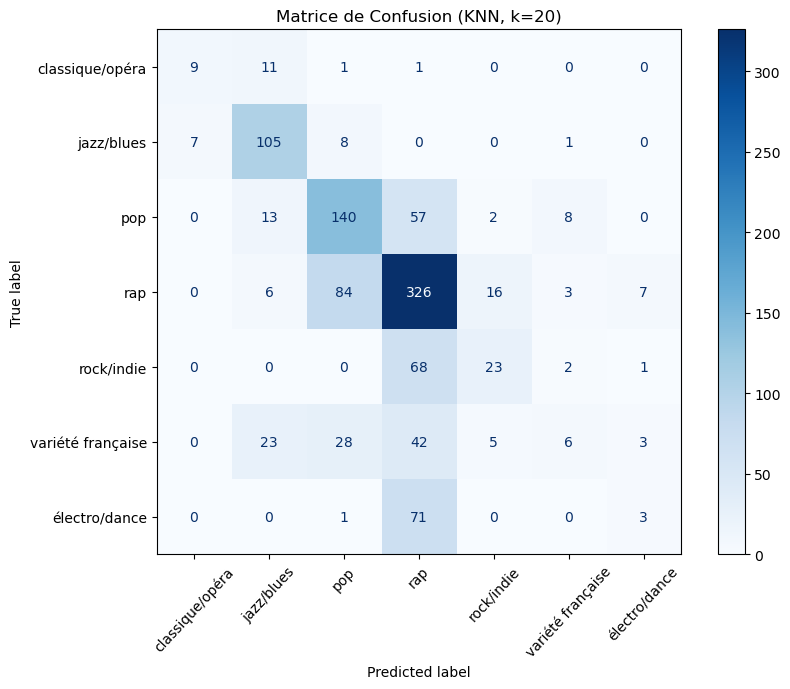


Rapport de Classification (KNN):
                   precision    recall  f1-score   support

  classique/opéra       0.56      0.41      0.47        22
       jazz/blues       0.66      0.87      0.75       121
              pop       0.53      0.64      0.58       220
              rap       0.58      0.74      0.65       442
       rock/indie       0.50      0.24      0.33        94
variété française       0.30      0.06      0.09       107
    électro/dance       0.21      0.04      0.07        75

         accuracy                           0.57      1081
        macro avg       0.48      0.43      0.42      1081
     weighted avg       0.52      0.57      0.52      1081



In [55]:
# Affiche un titre pour indiquer le début de la section de classification avec KNeighborsClassifier
print("\n--- Classification (KNeighborsClassifier pour prédire 'genre') ---")


# Création d'un pipeline de machine learning pour la classification
# Le pipeline enchaîne deux étapes principales :
# 1. 'scaler' : StandardScaler() standardise les features (moyenne 0, écart-type 1)
#    - Cela est crucial pour KNN, car il se base sur des distances : toutes les features doivent être sur la même échelle.
# 2. 'classifier' : KNeighborsClassifier(n_neighbors=20) applique l'algorithme KNN pour la classification
#    - n_neighbors=20 signifie que la classe prédite sera celle la plus fréquente parmi les 7 voisins les plus proches.
#    - Ce paramètre (k=20) est un choix courant, mais il peut être optimisé via validation croisée.
pipeline_knn_clf = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=20, metric='euclidean'))
    ])

# Sélection des features pour la classification avec KNN
# On extrait du DataFrame 'df' les colonnes suivantes :
# - 'valence' : mesure la positivité de la chanson (valeur entre 0 et 1)
# - 'energy' : mesure l'intensité de la chanson (valeur entre 0 et 1)
# - 'danceability' : mesure à quel point la chanson est dansante (valeur entre 0 et 1)
# - 'acousticness' : probabilité que la chanson soit acoustique (valeur entre 0 et 1)
# - 'tempo' : tempo de la chanson en battements par minute (BPM)
# - 'loudness' : volume sonore moyen de la chanson (en décibels)
# Ces colonnes sont sélectionnées car elles sont pertinentes pour caractériser et différencier les genres musicaux.
X_class_KNN = df.loc[:, ['valence', 'energy', 'danceability', 'acousticness', 'tempo']]


# Sélection de la variable cible (target) pour la classification
# Ici, on utilise la colonne 'genre' du DataFrame 'df'
y_class_KNN = df['genre']

# Instanciation de l'encodeur de labels
# LabelEncoder va transformer les genres musicaux (catégories textuelles) en entiers
le = LabelEncoder()

# Encodage de la variable cible
# Chaque genre unique est transformé en un entier unique (ex : 'pop' -> 0, 'rock' -> 1, etc.)
# Cela permet de rendre la cible compatible avec les algorithmes de classification de scikit-learn
y_class_KNN_encoded = le.fit_transform(y_class_KNN)


# Division des données en ensembles d'entraînement et de test pour la classification KNN

# On utilise train_test_split pour séparer les features (X_class_KNN) et la cible encodée (y_class_KNN_encoded)
# test_size=0.2 : 20% des données seront utilisées pour le test, 80% pour l'entraînement
# random_state=42 : fixe la graine aléatoire pour garantir la reproductibilité des résultats
# stratify=y_class_KNN_encoded : garantit que la proportion de chaque classe (genre) est respectée dans les deux ensembles,
# ce qui est crucial en cas de déséquilibre des classes

X_train_KNN, X_test_KNN, y_train_KNN, y_test_KNN = train_test_split(
    X_class_KNN,                # Features sélectionnées pour la classification
    y_class_KNN_encoded,        # Cible encodée en entiers
    test_size=0.2,              # Pourcentage des données dans l'ensemble de test
    random_state=42,            # Graine pour la reproductibilité
    stratify=y_class_KNN_encoded # Strate sur la cible pour équilibrer les classes dans chaque ensemble
)


# Pour KNN, la méthode .fit() ne construit pas un modèle complexe :
# Elle se contente de stocker les données d'entraînement, car l'algorithme KNN va comparer les nouveaux échantillons
# directement à ces données lors de la prédiction.
pipeline_knn_clf.fit(X_train_KNN, y_train_KNN)

# La méthode .predict() du pipeline :
# - Pour chaque échantillon, calcule la distance entre cet échantillon et tous les points d'entraînement stockés.
# - Sélectionne les k voisins les plus proches (selon la distance choisie, généralement euclidienne).
# - Attribue la classe majoritaire parmi ces voisins comme prédiction.

# Prédictions sur l'ensemble d'entraînement (permet de mesurer l'overfitting)
y_pred_knn_clf_train = pipeline_knn_clf.predict(X_train_KNN)

# Prédictions sur l'ensemble de test (permet d'évaluer la généralisation du modèle)
y_pred_knn_clf_test = pipeline_knn_clf.predict(X_test_KNN)


# Calcul de l'accuracy (taux de bonnes prédictions) sur l'ensemble d'entraînement
accuracy_knn_clf_train = accuracy_score(y_train_KNN, y_pred_knn_clf_train)
# Affichage formaté de l'accuracy d'entraînement avec 4 décimales
print(f"Modèle de Classification (KNN, k=20) - Accuracy sur l'ensemble d'entraînement: {accuracy_knn_clf_train:.4f}")

# Calcul de l'accuracy sur l'ensemble de test
accuracy_knn_clf_test = accuracy_score(y_test_KNN, y_pred_knn_clf_test)
# Affichage formaté de l'accuracy de test avec 4 décimales
print(f"Modèle de Classification (KNN, k=20) - Accuracy sur l'ensemble de test: {accuracy_knn_clf_test:.4f}")


# Calcul de la matrice de confusion pour le modèle KNN sur l'ensemble de test
# La matrice de confusion permet de visualiser le nombre de prédictions correctes et incorrectes pour chaque classe
cm_knn = confusion_matrix(y_test_KNN, y_pred_knn_clf_test)

# Création de l'objet d'affichage avec les noms de genres
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=genre)

# Création d'une figure plus large pour éviter le chevauchement
fig, ax = plt.subplots(figsize=(9, 7))
disp_knn.plot(cmap='Blues', ax=ax, xticks_rotation=47)  # xticks_rotation=47 incline les labels de l'axe x

plt.title("Matrice de Confusion (KNN, k=20)")
plt.tight_layout()  # Ajuste automatiquement les marges pour éviter que les labels soient coupés
plt.show()


# Affiche un titre pour séparer visuellement le rapport de classification dans la console
print("\nRapport de Classification (KNN):")

# Affiche un rapport détaillé sur les performances du modèle KNN pour chaque genre musical (classe)
# classification_report calcule et affiche les métriques suivantes pour chaque classe :
# - precision : proportion de prédictions correctes parmi toutes les prédictions positives pour cette classe
# - recall (rappel) : proportion de prédictions correctes parmi toutes les vraies instances de cette classe
# - f1-score : moyenne harmonique entre la précision et le rappel, mesure globale de la performance
# - support : nombre d'échantillons réels de chaque classe dans l'ensemble de test
# L'argument target_names=genre permet d'afficher les noms des genres au lieu des indices numériques.
# Attention : la variable 'genre' doit contenir la liste ordonnée des noms de genres correspondant à l'encodage utilisé (ex : le.classes_)
print(classification_report(y_test_KNN, y_pred_knn_clf_test, target_names=genre))




## ML supervisé : KNN (k=25, test_size=0.2, metric='euclidean')


--- Classification (KNeighborsClassifier pour prédire 'genre') ---
Modèle de Classification (KNN, k=25) - Accuracy sur l'ensemble d'entraînement: 0.5990
Modèle de Classification (KNN, k=25) - Accuracy sur l'ensemble de test: 0.5726


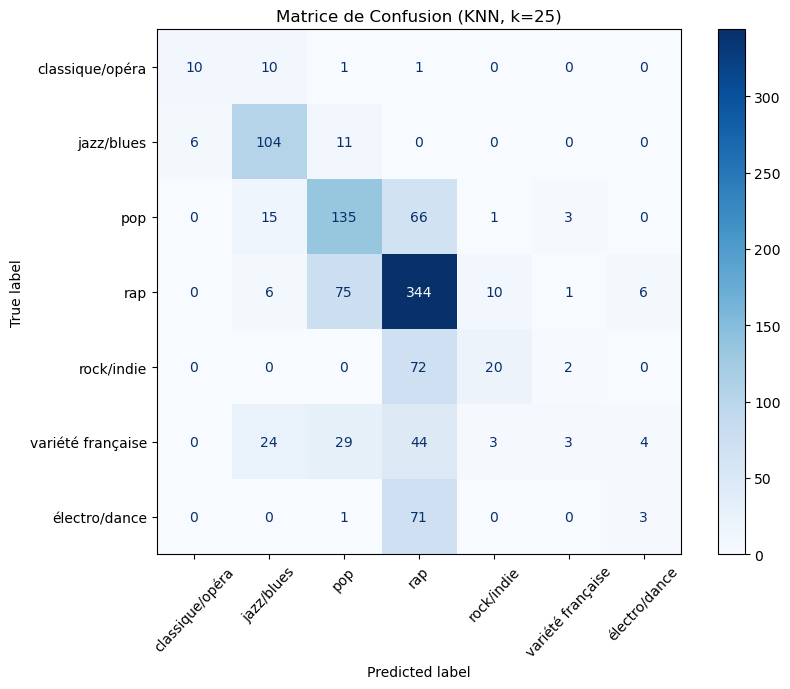


Rapport de Classification (KNN):
                   precision    recall  f1-score   support

  classique/opéra       0.62      0.45      0.53        22
       jazz/blues       0.65      0.86      0.74       121
              pop       0.54      0.61      0.57       220
              rap       0.58      0.78      0.66       442
       rock/indie       0.59      0.21      0.31        94
variété française       0.33      0.03      0.05       107
    électro/dance       0.23      0.04      0.07        75

         accuracy                           0.57      1081
        macro avg       0.51      0.43      0.42      1081
     weighted avg       0.53      0.57      0.52      1081



In [56]:
# Affiche un titre pour indiquer le début de la section de classification avec KNeighborsClassifier
print("\n--- Classification (KNeighborsClassifier pour prédire 'genre') ---")


# Création d'un pipeline de machine learning pour la classification
# Le pipeline enchaîne deux étapes principales :
# 1. 'scaler' : StandardScaler() standardise les features (moyenne 0, écart-type 1)
#    - Cela est crucial pour KNN, car il se base sur des distances : toutes les features doivent être sur la même échelle.
# 2. 'classifier' : KNeighborsClassifier(n_neighbors=25) applique l'algorithme KNN pour la classification
#    - n_neighbors=25 signifie que la classe prédite sera celle la plus fréquente parmi les 7 voisins les plus proches.
#    - Ce paramètre (k=25) est un choix courant, mais il peut être optimisé via validation croisée.
pipeline_knn_clf = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=25, metric='euclidean'))
    ])

# Sélection des features pour la classification avec KNN
# On extrait du DataFrame 'df' les colonnes suivantes :
# - 'valence' : mesure la positivité de la chanson (valeur entre 0 et 1)
# - 'energy' : mesure l'intensité de la chanson (valeur entre 0 et 1)
# - 'danceability' : mesure à quel point la chanson est dansante (valeur entre 0 et 1)
# - 'acousticness' : probabilité que la chanson soit acoustique (valeur entre 0 et 1)
# - 'tempo' : tempo de la chanson en battements par minute (BPM)
# - 'loudness' : volume sonore moyen de la chanson (en décibels)
# Ces colonnes sont sélectionnées car elles sont pertinentes pour caractériser et différencier les genres musicaux.
X_class_KNN = df.loc[:, ['valence', 'energy', 'danceability', 'acousticness', 'tempo']]


# Sélection de la variable cible (target) pour la classification
# Ici, on utilise la colonne 'genre' du DataFrame 'df'
y_class_KNN = df['genre']

# Instanciation de l'encodeur de labels
# LabelEncoder va transformer les genres musicaux (catégories textuelles) en entiers
le = LabelEncoder()

# Encodage de la variable cible
# Chaque genre unique est transformé en un entier unique (ex : 'pop' -> 0, 'rock' -> 1, etc.)
# Cela permet de rendre la cible compatible avec les algorithmes de classification de scikit-learn
y_class_KNN_encoded = le.fit_transform(y_class_KNN)


# Division des données en ensembles d'entraînement et de test pour la classification KNN

# On utilise train_test_split pour séparer les features (X_class_KNN) et la cible encodée (y_class_KNN_encoded)
# test_size=0.2 : 20% des données seront utilisées pour le test, 80% pour l'entraînement
# random_state=42 : fixe la graine aléatoire pour garantir la reproductibilité des résultats
# stratify=y_class_KNN_encoded : garantit que la proportion de chaque classe (genre) est respectée dans les deux ensembles,
# ce qui est crucial en cas de déséquilibre des classes

X_train_KNN, X_test_KNN, y_train_KNN, y_test_KNN = train_test_split(
    X_class_KNN,                # Features sélectionnées pour la classification
    y_class_KNN_encoded,        # Cible encodée en entiers
    test_size=0.2,              # Pourcentage des données dans l'ensemble de test
    random_state=42,            # Graine pour la reproductibilité
    stratify=y_class_KNN_encoded # Strate sur la cible pour équilibrer les classes dans chaque ensemble
)


# Pour KNN, la méthode .fit() ne construit pas un modèle complexe :
# Elle se contente de stocker les données d'entraînement, car l'algorithme KNN va comparer les nouveaux échantillons
# directement à ces données lors de la prédiction.
pipeline_knn_clf.fit(X_train_KNN, y_train_KNN)

# La méthode .predict() du pipeline :
# - Pour chaque échantillon, calcule la distance entre cet échantillon et tous les points d'entraînement stockés.
# - Sélectionne les k voisins les plus proches (selon la distance choisie, généralement euclidienne).
# - Attribue la classe majoritaire parmi ces voisins comme prédiction.

# Prédictions sur l'ensemble d'entraînement (permet de mesurer l'overfitting)
y_pred_knn_clf_train = pipeline_knn_clf.predict(X_train_KNN)

# Prédictions sur l'ensemble de test (permet d'évaluer la généralisation du modèle)
y_pred_knn_clf_test = pipeline_knn_clf.predict(X_test_KNN)


# Calcul de l'accuracy (taux de bonnes prédictions) sur l'ensemble d'entraînement
accuracy_knn_clf_train = accuracy_score(y_train_KNN, y_pred_knn_clf_train)
# Affichage formaté de l'accuracy d'entraînement avec 4 décimales
print(f"Modèle de Classification (KNN, k=25) - Accuracy sur l'ensemble d'entraînement: {accuracy_knn_clf_train:.4f}")

# Calcul de l'accuracy sur l'ensemble de test
accuracy_knn_clf_test = accuracy_score(y_test_KNN, y_pred_knn_clf_test)
# Affichage formaté de l'accuracy de test avec 4 décimales
print(f"Modèle de Classification (KNN, k=25) - Accuracy sur l'ensemble de test: {accuracy_knn_clf_test:.4f}")


# Calcul de la matrice de confusion pour le modèle KNN sur l'ensemble de test
# La matrice de confusion permet de visualiser le nombre de prédictions correctes et incorrectes pour chaque classe
cm_knn = confusion_matrix(y_test_KNN, y_pred_knn_clf_test)

# Création de l'objet d'affichage avec les noms de genres
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=genre)

# Création d'une figure plus large pour éviter le chevauchement
fig, ax = plt.subplots(figsize=(9, 7))
disp_knn.plot(cmap='Blues', ax=ax, xticks_rotation=47)  # xticks_rotation=47 incline les labels de l'axe x

plt.title("Matrice de Confusion (KNN, k=25)")
plt.tight_layout()  # Ajuste automatiquement les marges pour éviter que les labels soient coupés
plt.show()


# Affiche un titre pour séparer visuellement le rapport de classification dans la console
print("\nRapport de Classification (KNN):")

# Affiche un rapport détaillé sur les performances du modèle KNN pour chaque genre musical (classe)
# classification_report calcule et affiche les métriques suivantes pour chaque classe :
# - precision : proportion de prédictions correctes parmi toutes les prédictions positives pour cette classe
# - recall (rappel) : proportion de prédictions correctes parmi toutes les vraies instances de cette classe
# - f1-score : moyenne harmonique entre la précision et le rappel, mesure globale de la performance
# - support : nombre d'échantillons réels de chaque classe dans l'ensemble de test
# L'argument target_names=genre permet d'afficher les noms des genres au lieu des indices numériques.
# Attention : la variable 'genre' doit contenir la liste ordonnée des noms de genres correspondant à l'encodage utilisé (ex : le.classes_)
print(classification_report(y_test_KNN, y_pred_knn_clf_test, target_names=genre))




## Tableau comparatif : ML supervisé KNN (metric = 'euclidean')

In [57]:
# Définition des différentes valeurs de k à tester
k_values = [5, 7, 10, 15, 20, 25]  # liste des k pour KNN

# Sélection des features pertinentes dans le DataFrame df
X = df.loc[:, ['valence', 'energy', 'danceability', 'acousticness', 'tempo']]

# Encodage des labels (genres) en entiers
le = LabelEncoder()                   # instanciation de l'encodeur de labels
y = le.fit_transform(df['genre'])     # transformation des genres en entiers

# Séparation des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(
    X,                                 # features
    y,                                 # cible encodée
    test_size=0.2,                     # 20% des données en test
    random_state=42,                   # pour la reproductibilité
    stratify=y                         # conserve la distribution des classes
)

# Initialisation d'une liste pour stocker les résultats de chaque k
results = []

# Boucle sur chaque valeur de k
for k in k_values:
    # Construction du pipeline scaler + KNN avec la valeur de k en cours
    pipeline = Pipeline(steps=[
        ('scaler', StandardScaler()),                                  # normalisation des données
        ('classifier', KNeighborsClassifier(n_neighbors=k, metric='euclidean'))
    ])
    
    # Entraînement du modèle sur l'ensemble d'entraînement
    pipeline.fit(X_train, y_train)
    
    # Prédiction sur le train et le test
    y_pred_train = pipeline.predict(X_train)  # labels prédits sur train
    y_pred_test = pipeline.predict(X_test)    # labels prédits sur test
    
    # Calcul des métriques d'évaluation
    train_acc = accuracy_score(y_train, y_pred_train)                           # accuracy sur train
    test_acc = accuracy_score(y_test, y_pred_test)                              # accuracy sur test
    macro_prec = precision_score(y_test, y_pred_test, average='macro')          # précision moyenne macro
    macro_rec = recall_score(y_test, y_pred_test, average='macro')              # rappel moyen macro
    macro_f1 = f1_score(y_test, y_pred_test, average='macro')                   # f1-score moyen macro
    
    # Ajout des résultats dans la liste
    results.append({
        'k': k,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'macro_precision': macro_prec,
        'macro_recall': macro_rec,
        'macro_f1': macro_f1
    })

# Conversion de la liste en DataFrame pour affichage tabulaire
df_results = pd.DataFrame(results)

# Affichage du tableau comparatif
print(df_results)


    k  train_accuracy  test_accuracy  macro_precision  macro_recall  macro_f1
0   5        0.657335       0.530990         0.463910      0.415461  0.416842
1   7        0.651550       0.543016         0.498527      0.429002  0.434989
2  10        0.637205       0.567068         0.518650      0.452097  0.450177
3  15        0.624017       0.571693         0.490442      0.432673  0.425179
4  20        0.612679       0.566142         0.478955      0.427362  0.420747
5  25        0.599028       0.572618         0.506056      0.426681  0.419307


## ML supervisé : KNN (k=5, test_size=0.2, metric='cosine')


--- Classification (KNeighborsClassifier pour prédire 'genre') ---
Modèle de Classification (KNN, k=5) - Accuracy sur l'ensemble d'entraînement: 0.6472
Modèle de Classification (KNN, k=5) - Accuracy sur l'ensemble de test: 0.5088


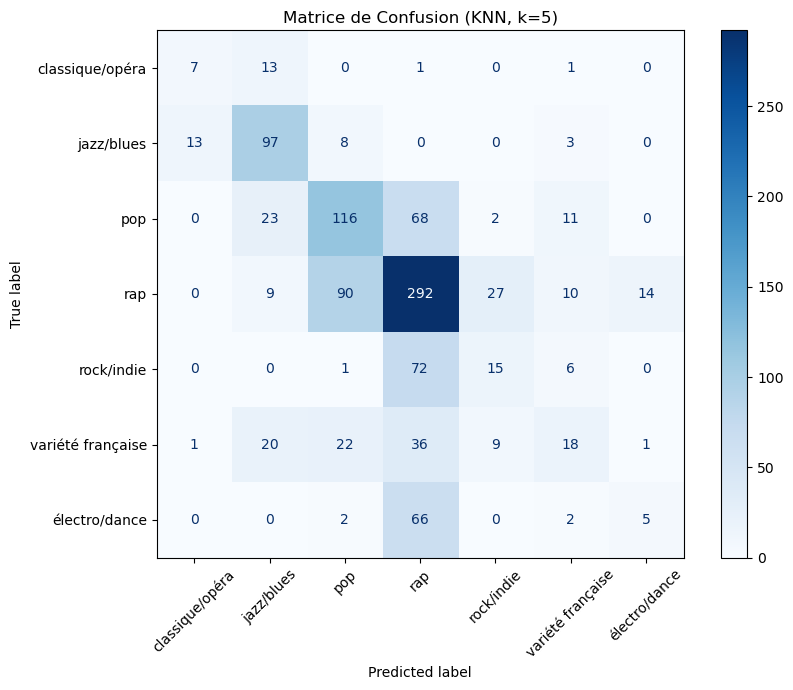


Rapport de Classification (KNN):
                   precision    recall  f1-score   support

  classique/opéra       0.33      0.32      0.33        22
       jazz/blues       0.60      0.80      0.69       121
              pop       0.49      0.53      0.51       220
              rap       0.55      0.66      0.60       442
       rock/indie       0.28      0.16      0.20        94
variété française       0.35      0.17      0.23       107
    électro/dance       0.25      0.07      0.11        75

         accuracy                           0.51      1081
        macro avg       0.41      0.39      0.38      1081
     weighted avg       0.47      0.51      0.48      1081



In [58]:
# Affiche un titre pour indiquer le début de la section de classification avec KNeighborsClassifier
print("\n--- Classification (KNeighborsClassifier pour prédire 'genre') ---")


# Création d'un pipeline de machine learning pour la classification
# Le pipeline enchaîne deux étapes principales :
# 1. 'scaler' : StandardScaler() standardise les features (moyenne 0, écart-type 1)
#    - Cela est crucial pour KNN, car il se base sur des distances : toutes les features doivent être sur la même échelle.
# 2. 'classifier' : KNeighborsClassifier(n_neighbors=5) applique l'algorithme KNN pour la classification
#    - n_neighbors=5 signifie que la classe prédite sera celle la plus fréquente parmi les 5 voisins les plus proches.
#    - Ce paramètre (k=5) est un choix courant, mais il peut être optimisé via validation croisée.
pipeline_knn_clf = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=5, metric='cosine'))
    ])

# Sélection des features pour la classification avec KNN
# On extrait du DataFrame 'df' les colonnes suivantes :
# - 'valence' : mesure la positivité de la chanson (valeur entre 0 et 1)
# - 'energy' : mesure l'intensité de la chanson (valeur entre 0 et 1)
# - 'danceability' : mesure à quel point la chanson est dansante (valeur entre 0 et 1)
# - 'acousticness' : probabilité que la chanson soit acoustique (valeur entre 0 et 1)
# - 'tempo' : tempo de la chanson en battements par minute (BPM)
# - 'loudness' : volume sonore moyen de la chanson (en décibels)
# Ces colonnes sont sélectionnées car elles sont pertinentes pour caractériser et différencier les genres musicaux.
X_class_KNN = df.loc[:, ['valence', 'energy', 'danceability', 'acousticness', 'tempo']]


# Sélection de la variable cible (target) pour la classification
# Ici, on utilise la colonne 'genre' du DataFrame 'df'
y_class_KNN = df['genre']

# Instanciation de l'encodeur de labels
# LabelEncoder va transformer les genres musicaux (catégories textuelles) en entiers
le = LabelEncoder()

# Encodage de la variable cible
# Chaque genre unique est transformé en un entier unique (ex : 'pop' -> 0, 'rock' -> 1, etc.)
# Cela permet de rendre la cible compatible avec les algorithmes de classification de scikit-learn
y_class_KNN_encoded = le.fit_transform(y_class_KNN)


# Division des données en ensembles d'entraînement et de test pour la classification KNN

# On utilise train_test_split pour séparer les features (X_class_KNN) et la cible encodée (y_class_KNN_encoded)
# test_size=0.2 : 20% des données seront utilisées pour le test, 80% pour l'entraînement
# random_state=42 : fixe la graine aléatoire pour garantir la reproductibilité des résultats
# stratify=y_class_KNN_encoded : garantit que la proportion de chaque classe (genre) est respectée dans les deux ensembles,
# ce qui est crucial en cas de déséquilibre des classes

X_train_KNN, X_test_KNN, y_train_KNN, y_test_KNN = train_test_split(
    X_class_KNN,                # Features sélectionnées pour la classification
    y_class_KNN_encoded,        # Cible encodée en entiers
    test_size=0.2,              # Pourcentage des données dans l'ensemble de test
    random_state=42,            # Graine pour la reproductibilité
    stratify=y_class_KNN_encoded # Strate sur la cible pour équilibrer les classes dans chaque ensemble
)


# Pour KNN, la méthode .fit() ne construit pas un modèle complexe :
# Elle se contente de stocker les données d'entraînement, car l'algorithme KNN va comparer les nouveaux échantillons
# directement à ces données lors de la prédiction.
pipeline_knn_clf.fit(X_train_KNN, y_train_KNN)

# La méthode .predict() du pipeline :
# - Pour chaque échantillon, calcule la distance entre cet échantillon et tous les points d'entraînement stockés.
# - Sélectionne les k voisins les plus proches (selon la distance choisie, généralement euclidienne).
# - Attribue la classe majoritaire parmi ces voisins comme prédiction.

# Prédictions sur l'ensemble d'entraînement (permet de mesurer l'overfitting)
y_pred_knn_clf_train = pipeline_knn_clf.predict(X_train_KNN)

# Prédictions sur l'ensemble de test (permet d'évaluer la généralisation du modèle)
y_pred_knn_clf_test = pipeline_knn_clf.predict(X_test_KNN)


# Calcul de l'accuracy (taux de bonnes prédictions) sur l'ensemble d'entraînement
accuracy_knn_clf_train = accuracy_score(y_train_KNN, y_pred_knn_clf_train)
# Affichage formaté de l'accuracy d'entraînement avec 4 décimales
print(f"Modèle de Classification (KNN, k=5) - Accuracy sur l'ensemble d'entraînement: {accuracy_knn_clf_train:.4f}")

# Calcul de l'accuracy sur l'ensemble de test
accuracy_knn_clf_test = accuracy_score(y_test_KNN, y_pred_knn_clf_test)
# Affichage formaté de l'accuracy de test avec 4 décimales
print(f"Modèle de Classification (KNN, k=5) - Accuracy sur l'ensemble de test: {accuracy_knn_clf_test:.4f}")


# Calcul de la matrice de confusion pour le modèle KNN sur l'ensemble de test
# La matrice de confusion permet de visualiser le nombre de prédictions correctes et incorrectes pour chaque classe
cm_knn = confusion_matrix(y_test_KNN, y_pred_knn_clf_test)

# Création de l'objet d'affichage avec les noms de genres
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=genre)

# Création d'une figure plus large pour éviter le chevauchement
fig, ax = plt.subplots(figsize=(9, 7))
disp_knn.plot(cmap='Blues', ax=ax, xticks_rotation=45)  # xticks_rotation=45 incline les labels de l'axe x

plt.title("Matrice de Confusion (KNN, k=5)")
plt.tight_layout()  # Ajuste automatiquement les marges pour éviter que les labels soient coupés
plt.show()


# Affiche un titre pour séparer visuellement le rapport de classification dans la console
print("\nRapport de Classification (KNN):")

# Affiche un rapport détaillé sur les performances du modèle KNN pour chaque genre musical (classe)
# classification_report calcule et affiche les métriques suivantes pour chaque classe :
# - precision : proportion de prédictions correctes parmi toutes les prédictions positives pour cette classe
# - recall (rappel) : proportion de prédictions correctes parmi toutes les vraies instances de cette classe
# - f1-score : moyenne harmonique entre la précision et le rappel, mesure globale de la performance
# - support : nombre d'échantillons réels de chaque classe dans l'ensemble de test
# L'argument target_names=genre permet d'afficher les noms des genres au lieu des indices numériques.
# Attention : la variable 'genre' doit contenir la liste ordonnée des noms de genres correspondant à l'encodage utilisé (ex : le.classes_)
print(classification_report(y_test_KNN, y_pred_knn_clf_test, target_names=genre))




## ML supervisé : KNN (k=7, test_size=0.2, metric='cosine')


--- Classification (KNeighborsClassifier pour prédire 'genre') ---
Modèle de Classification (KNN, k=7) - Accuracy sur l'ensemble d'entraînement: 0.6356
Modèle de Classification (KNN, k=7) - Accuracy sur l'ensemble de test: 0.5264


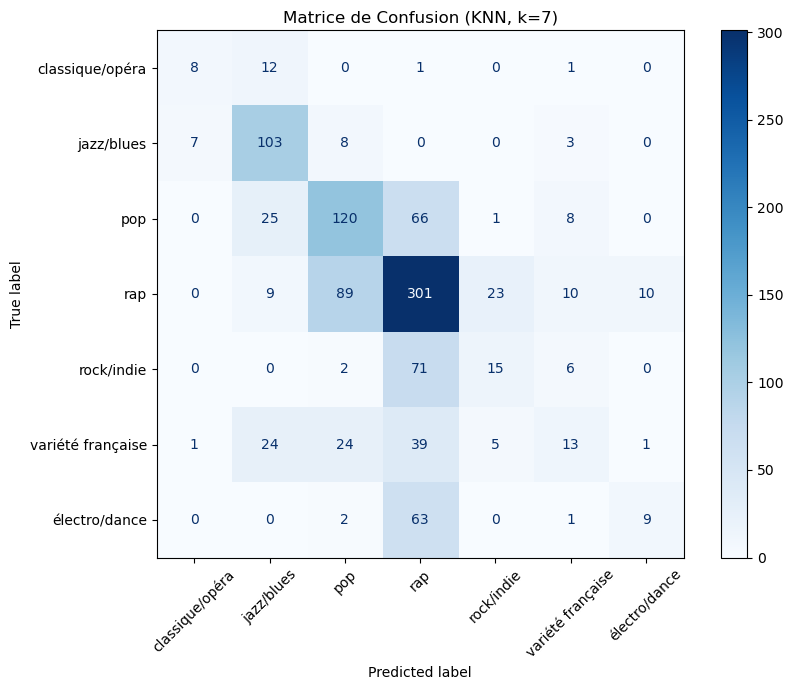


Rapport de Classification (KNN):
                   precision    recall  f1-score   support

  classique/opéra       0.50      0.36      0.42        22
       jazz/blues       0.60      0.85      0.70       121
              pop       0.49      0.55      0.52       220
              rap       0.56      0.68      0.61       442
       rock/indie       0.34      0.16      0.22        94
variété française       0.31      0.12      0.17       107
    électro/dance       0.45      0.12      0.19        75

         accuracy                           0.53      1081
        macro avg       0.46      0.41      0.40      1081
     weighted avg       0.50      0.53      0.49      1081



In [59]:
# Affiche un titre pour indiquer le début de la section de classification avec KNeighborsClassifier
print("\n--- Classification (KNeighborsClassifier pour prédire 'genre') ---")


# Création d'un pipeline de machine learning pour la classification
# Le pipeline enchaîne deux étapes principales :
# 1. 'scaler' : StandardScaler() standardise les features (moyenne 0, écart-type 1)
#    - Cela est crucial pour KNN, car il se base sur des distances : toutes les features doivent être sur la même échelle.
# 2. 'classifier' : KNeighborsClassifier(n_neighbors=7) applique l'algorithme KNN pour la classification
#    - n_neighbors=7 signifie que la classe prédite sera celle la plus fréquente parmi les 7 voisins les plus proches.
#    - Ce paramètre (k=7) est un choix courant, mais il peut être optimisé via validation croisée.
pipeline_knn_clf = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=7, metric='cosine'))
    ])

# Sélection des features pour la classification avec KNN
# On extrait du DataFrame 'df' les colonnes suivantes :
# - 'valence' : mesure la positivité de la chanson (valeur entre 0 et 1)
# - 'energy' : mesure l'intensité de la chanson (valeur entre 0 et 1)
# - 'danceability' : mesure à quel point la chanson est dansante (valeur entre 0 et 1)
# - 'acousticness' : probabilité que la chanson soit acoustique (valeur entre 0 et 1)
# - 'tempo' : tempo de la chanson en battements par minute (BPM)
# - 'loudness' : volume sonore moyen de la chanson (en décibels)
# Ces colonnes sont sélectionnées car elles sont pertinentes pour caractériser et différencier les genres musicaux.
X_class_KNN = df.loc[:, ['valence', 'energy', 'danceability', 'acousticness', 'tempo']]


# Sélection de la variable cible (target) pour la classification
# Ici, on utilise la colonne 'genre' du DataFrame 'df'
y_class_KNN = df['genre']

# Instanciation de l'encodeur de labels
# LabelEncoder va transformer les genres musicaux (catégories textuelles) en entiers
le = LabelEncoder()

# Encodage de la variable cible
# Chaque genre unique est transformé en un entier unique (ex : 'pop' -> 0, 'rock' -> 1, etc.)
# Cela permet de rendre la cible compatible avec les algorithmes de classification de scikit-learn
y_class_KNN_encoded = le.fit_transform(y_class_KNN)


# Division des données en ensembles d'entraînement et de test pour la classification KNN

# On utilise train_test_split pour séparer les features (X_class_KNN) et la cible encodée (y_class_KNN_encoded)
# test_size=0.2 : 20% des données seront utilisées pour le test, 80% pour l'entraînement
# random_state=42 : fixe la graine aléatoire pour garantir la reproductibilité des résultats
# stratify=y_class_KNN_encoded : garantit que la proportion de chaque classe (genre) est respectée dans les deux ensembles,
# ce qui est crucial en cas de déséquilibre des classes

X_train_KNN, X_test_KNN, y_train_KNN, y_test_KNN = train_test_split(
    X_class_KNN,                # Features sélectionnées pour la classification
    y_class_KNN_encoded,        # Cible encodée en entiers
    test_size=0.2,              # Pourcentage des données dans l'ensemble de test
    random_state=42,            # Graine pour la reproductibilité
    stratify=y_class_KNN_encoded # Strate sur la cible pour équilibrer les classes dans chaque ensemble
)


# Pour KNN, la méthode .fit() ne construit pas un modèle complexe :
# Elle se contente de stocker les données d'entraînement, car l'algorithme KNN va comparer les nouveaux échantillons
# directement à ces données lors de la prédiction.
pipeline_knn_clf.fit(X_train_KNN, y_train_KNN)

# La méthode .predict() du pipeline :
# - Pour chaque échantillon, calcule la distance entre cet échantillon et tous les points d'entraînement stockés.
# - Sélectionne les k voisins les plus proches (selon la distance choisie, généralement euclidienne).
# - Attribue la classe majoritaire parmi ces voisins comme prédiction.

# Prédictions sur l'ensemble d'entraînement (permet de mesurer l'overfitting)
y_pred_knn_clf_train = pipeline_knn_clf.predict(X_train_KNN)

# Prédictions sur l'ensemble de test (permet d'évaluer la généralisation du modèle)
y_pred_knn_clf_test = pipeline_knn_clf.predict(X_test_KNN)


# Calcul de l'accuracy (taux de bonnes prédictions) sur l'ensemble d'entraînement
accuracy_knn_clf_train = accuracy_score(y_train_KNN, y_pred_knn_clf_train)
# Affichage formaté de l'accuracy d'entraînement avec 4 décimales
print(f"Modèle de Classification (KNN, k=7) - Accuracy sur l'ensemble d'entraînement: {accuracy_knn_clf_train:.4f}")

# Calcul de l'accuracy sur l'ensemble de test
accuracy_knn_clf_test = accuracy_score(y_test_KNN, y_pred_knn_clf_test)
# Affichage formaté de l'accuracy de test avec 4 décimales
print(f"Modèle de Classification (KNN, k=7) - Accuracy sur l'ensemble de test: {accuracy_knn_clf_test:.4f}")


# Calcul de la matrice de confusion pour le modèle KNN sur l'ensemble de test
# La matrice de confusion permet de visualiser le nombre de prédictions correctes et incorrectes pour chaque classe
cm_knn = confusion_matrix(y_test_KNN, y_pred_knn_clf_test)

# Création de l'objet d'affichage avec les noms de genres
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=genre)

# Création d'une figure plus large pour éviter le chevauchement
fig, ax = plt.subplots(figsize=(9, 7))
disp_knn.plot(cmap='Blues', ax=ax, xticks_rotation=45)  # xticks_rotation=45 incline les labels de l'axe x

plt.title("Matrice de Confusion (KNN, k=7)")
plt.tight_layout()  # Ajuste automatiquement les marges pour éviter que les labels soient coupés
plt.show()


# Affiche un titre pour séparer visuellement le rapport de classification dans la console
print("\nRapport de Classification (KNN):")

# Affiche un rapport détaillé sur les performances du modèle KNN pour chaque genre musical (classe)
# classification_report calcule et affiche les métriques suivantes pour chaque classe :
# - precision : proportion de prédictions correctes parmi toutes les prédictions positives pour cette classe
# - recall (rappel) : proportion de prédictions correctes parmi toutes les vraies instances de cette classe
# - f1-score : moyenne harmonique entre la précision et le rappel, mesure globale de la performance
# - support : nombre d'échantillons réels de chaque classe dans l'ensemble de test
# L'argument target_names=genre permet d'afficher les noms des genres au lieu des indices numériques.
# Attention : la variable 'genre' doit contenir la liste ordonnée des noms de genres correspondant à l'encodage utilisé (ex : le.classes_)
print(classification_report(y_test_KNN, y_pred_knn_clf_test, target_names=genre))




## ML supervisé : KNN (k=10, test_size=0.2, metric='cosine')


--- Classification (KNeighborsClassifier pour prédire 'genre') ---
Modèle de Classification (KNN, k=10) - Accuracy sur l'ensemble d'entraînement: 0.6210
Modèle de Classification (KNN, k=10) - Accuracy sur l'ensemble de test: 0.5513


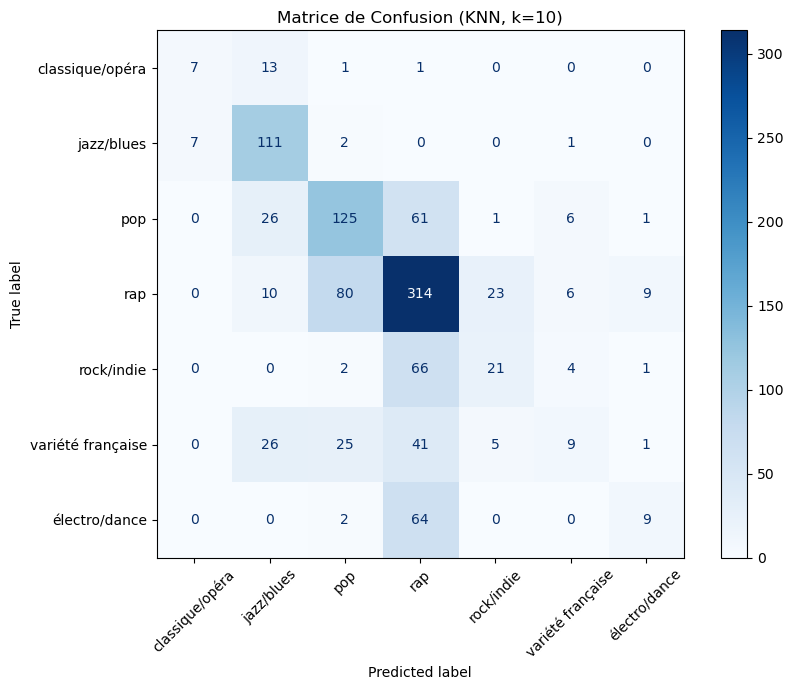


Rapport de Classification (KNN):
                   precision    recall  f1-score   support

  classique/opéra       0.50      0.32      0.39        22
       jazz/blues       0.60      0.92      0.72       121
              pop       0.53      0.57      0.55       220
              rap       0.57      0.71      0.63       442
       rock/indie       0.42      0.22      0.29        94
variété française       0.35      0.08      0.14       107
    électro/dance       0.43      0.12      0.19        75

         accuracy                           0.55      1081
        macro avg       0.48      0.42      0.42      1081
     weighted avg       0.52      0.55      0.51      1081



In [60]:
# Affiche un titre pour indiquer le début de la section de classification avec KNeighborsClassifier
print("\n--- Classification (KNeighborsClassifier pour prédire 'genre') ---")


# Création d'un pipeline de machine learning pour la classification
# Le pipeline enchaîne deux étapes principales :
# 1. 'scaler' : StandardScaler() standardise les features (moyenne 0, écart-type 1)
#    - Cela est crucial pour KNN, car il se base sur des distances : toutes les features doivent être sur la même échelle.
# 2. 'classifier' : KNeighborsClassifier(n_neighbors=10) applique l'algorithme KNN pour la classification
#    - n_neighbors=10 signifie que la classe prédite sera celle la plus fréquente parmi les 10 voisins les plus proches.
#    - Ce paramètre (k=10) est un choix courant, mais il peut être optimisé via validation croisée.
pipeline_knn_clf = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=10, metric='cosine'))
    ])

# Sélection des features pour la classification avec KNN
# On extrait du DataFrame 'df' les colonnes suivantes :
# - 'valence' : mesure la positivité de la chanson (valeur entre 0 et 1)
# - 'energy' : mesure l'intensité de la chanson (valeur entre 0 et 1)
# - 'danceability' : mesure à quel point la chanson est dansante (valeur entre 0 et 1)
# - 'acousticness' : probabilité que la chanson soit acoustique (valeur entre 0 et 1)
# - 'tempo' : tempo de la chanson en battements par minute (BPM)
# - 'loudness' : volume sonore moyen de la chanson (en décibels)
# Ces colonnes sont sélectionnées car elles sont pertinentes pour caractériser et différencier les genres musicaux.
X_class_KNN = df.loc[:, ['valence', 'energy', 'danceability', 'acousticness', 'tempo']]


# Sélection de la variable cible (target) pour la classification
# Ici, on utilise la colonne 'genre' du DataFrame 'df'
y_class_KNN = df['genre']

# Instanciation de l'encodeur de labels
# LabelEncoder va transformer les genres musicaux (catégories textuelles) en entiers
le = LabelEncoder()

# Encodage de la variable cible
# Chaque genre unique est transformé en un entier unique (ex : 'pop' -> 0, 'rock' -> 1, etc.)
# Cela permet de rendre la cible compatible avec les algorithmes de classification de scikit-learn
y_class_KNN_encoded = le.fit_transform(y_class_KNN)


# Division des données en ensembles d'entraînement et de test pour la classification KNN

# On utilise train_test_split pour séparer les features (X_class_KNN) et la cible encodée (y_class_KNN_encoded)
# test_size=0.2 : 20% des données seront utilisées pour le test, 80% pour l'entraînement
# random_state=42 : fixe la graine aléatoire pour garantir la reproductibilité des résultats
# stratify=y_class_KNN_encoded : garantit que la proportion de chaque classe (genre) est respectée dans les deux ensembles,
# ce qui est crucial en cas de déséquilibre des classes

X_train_KNN, X_test_KNN, y_train_KNN, y_test_KNN = train_test_split(
    X_class_KNN,                # Features sélectionnées pour la classification
    y_class_KNN_encoded,        # Cible encodée en entiers
    test_size=0.2,              # Pourcentage des données dans l'ensemble de test
    random_state=42,            # Graine pour la reproductibilité
    stratify=y_class_KNN_encoded # Strate sur la cible pour équilibrer les classes dans chaque ensemble
)


# Pour KNN, la méthode .fit() ne construit pas un modèle complexe :
# Elle se contente de stocker les données d'entraînement, car l'algorithme KNN va comparer les nouveaux échantillons
# directement à ces données lors de la prédiction.
pipeline_knn_clf.fit(X_train_KNN, y_train_KNN)

# La méthode .predict() du pipeline :
# - Pour chaque échantillon, calcule la distance entre cet échantillon et tous les points d'entraînement stockés.
# - Sélectionne les k voisins les plus proches (selon la distance choisie, généralement euclidienne).
# - Attribue la classe majoritaire parmi ces voisins comme prédiction.

# Prédictions sur l'ensemble d'entraînement (permet de mesurer l'overfitting)
y_pred_knn_clf_train = pipeline_knn_clf.predict(X_train_KNN)

# Prédictions sur l'ensemble de test (permet d'évaluer la généralisation du modèle)
y_pred_knn_clf_test = pipeline_knn_clf.predict(X_test_KNN)


# Calcul de l'accuracy (taux de bonnes prédictions) sur l'ensemble d'entraînement
accuracy_knn_clf_train = accuracy_score(y_train_KNN, y_pred_knn_clf_train)
# Affichage formaté de l'accuracy d'entraînement avec 4 décimales
print(f"Modèle de Classification (KNN, k=10) - Accuracy sur l'ensemble d'entraînement: {accuracy_knn_clf_train:.4f}")

# Calcul de l'accuracy sur l'ensemble de test
accuracy_knn_clf_test = accuracy_score(y_test_KNN, y_pred_knn_clf_test)
# Affichage formaté de l'accuracy de test avec 4 décimales
print(f"Modèle de Classification (KNN, k=10) - Accuracy sur l'ensemble de test: {accuracy_knn_clf_test:.4f}")


# Calcul de la matrice de confusion pour le modèle KNN sur l'ensemble de test
# La matrice de confusion permet de visualiser le nombre de prédictions correctes et incorrectes pour chaque classe
cm_knn = confusion_matrix(y_test_KNN, y_pred_knn_clf_test)

# Création de l'objet d'affichage avec les noms de genres
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=genre)

# Création d'une figure plus large pour éviter le chevauchement
fig, ax = plt.subplots(figsize=(9, 7))
disp_knn.plot(cmap='Blues', ax=ax, xticks_rotation=45)  # xticks_rotation=45 incline les labels de l'axe x

plt.title("Matrice de Confusion (KNN, k=10)")
plt.tight_layout()  # Ajuste automatiquement les marges pour éviter que les labels soient coupés
plt.show()


# Affiche un titre pour séparer visuellement le rapport de classification dans la console
print("\nRapport de Classification (KNN):")

# Affiche un rapport détaillé sur les performances du modèle KNN pour chaque genre musical (classe)
# classification_report calcule et affiche les métriques suivantes pour chaque classe :
# - precision : proportion de prédictions correctes parmi toutes les prédictions positives pour cette classe
# - recall (rappel) : proportion de prédictions correctes parmi toutes les vraies instances de cette classe
# - f1-score : moyenne harmonique entre la précision et le rappel, mesure globale de la performance
# - support : nombre d'échantillons réels de chaque classe dans l'ensemble de test
# L'argument target_names=genre permet d'afficher les noms des genres au lieu des indices numériques.
# Attention : la variable 'genre' doit contenir la liste ordonnée des noms de genres correspondant à l'encodage utilisé (ex : le.classes_)
print(classification_report(y_test_KNN, y_pred_knn_clf_test, target_names=genre))




## ML supervisé : KNN (k=15, test_size=0.2, metric='cosine')


--- Classification (KNeighborsClassifier pour prédire 'genre') ---
Modèle de Classification (KNN, k=15) - Accuracy sur l'ensemble d'entraînement: 0.6039
Modèle de Classification (KNN, k=15) - Accuracy sur l'ensemble de test: 0.5467


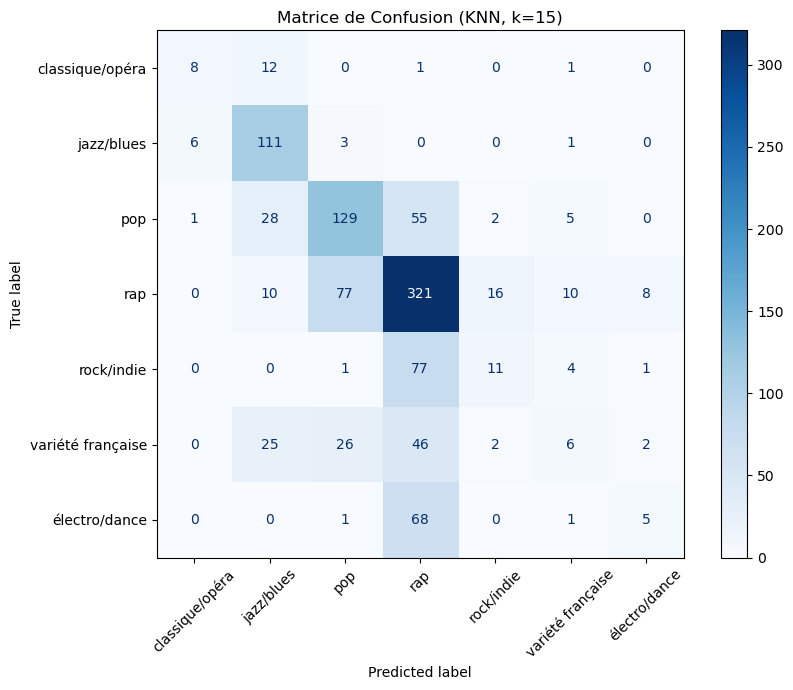


Rapport de Classification (KNN):
                   precision    recall  f1-score   support

  classique/opéra       0.53      0.36      0.43        22
       jazz/blues       0.60      0.92      0.72       121
              pop       0.54      0.59      0.56       220
              rap       0.57      0.73      0.64       442
       rock/indie       0.35      0.12      0.18        94
variété française       0.21      0.06      0.09       107
    électro/dance       0.31      0.07      0.11        75

         accuracy                           0.55      1081
        macro avg       0.45      0.40      0.39      1081
     weighted avg       0.49      0.55      0.50      1081



In [61]:
# Affiche un titre pour indiquer le début de la section de classification avec KNeighborsClassifier
print("\n--- Classification (KNeighborsClassifier pour prédire 'genre') ---")


# Création d'un pipeline de machine learning pour la classification
# Le pipeline enchaîne deux étapes principales :
# 1. 'scaler' : StandardScaler() standardise les features (moyenne 0, écart-type 1)
#    - Cela est crucial pour KNN, car il se base sur des distances : toutes les features doivent être sur la même échelle.
# 2. 'classifier' : KNeighborsClassifier(n_neighbors=15) applique l'algorithme KNN pour la classification
#    - n_neighbors=15 signifie que la classe prédite sera celle la plus fréquente parmi les 15 voisins les plus proches.
#    - Ce paramètre (k=15) est un choix courant, mais il peut être optimisé via validation croisée.
pipeline_knn_clf = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=15, metric='cosine'))
    ])

# Sélection des features pour la classification avec KNN
# On extrait du DataFrame 'df' les colonnes suivantes :
# - 'valence' : mesure la positivité de la chanson (valeur entre 0 et 1)
# - 'energy' : mesure l'intensité de la chanson (valeur entre 0 et 1)
# - 'danceability' : mesure à quel point la chanson est dansante (valeur entre 0 et 1)
# - 'acousticness' : probabilité que la chanson soit acoustique (valeur entre 0 et 1)
# - 'tempo' : tempo de la chanson en battements par minute (BPM)
# - 'loudness' : volume sonore moyen de la chanson (en décibels)
# Ces colonnes sont sélectionnées car elles sont pertinentes pour caractériser et différencier les genres musicaux.
X_class_KNN = df.loc[:, ['valence', 'energy', 'danceability', 'acousticness', 'tempo']]


# Sélection de la variable cible (target) pour la classification
# Ici, on utilise la colonne 'genre' du DataFrame 'df'
y_class_KNN = df['genre']

# Instanciation de l'encodeur de labels
# LabelEncoder va transformer les genres musicaux (catégories textuelles) en entiers
le = LabelEncoder()

# Encodage de la variable cible
# Chaque genre unique est transformé en un entier unique (ex : 'pop' -> 0, 'rock' -> 1, etc.)
# Cela permet de rendre la cible compatible avec les algorithmes de classification de scikit-learn
y_class_KNN_encoded = le.fit_transform(y_class_KNN)


# Division des données en ensembles d'entraînement et de test pour la classification KNN

# On utilise train_test_split pour séparer les features (X_class_KNN) et la cible encodée (y_class_KNN_encoded)
# test_size=0.2 : 20% des données seront utilisées pour le test, 80% pour l'entraînement
# random_state=42 : fixe la graine aléatoire pour garantir la reproductibilité des résultats
# stratify=y_class_KNN_encoded : garantit que la proportion de chaque classe (genre) est respectée dans les deux ensembles,
# ce qui est crucial en cas de déséquilibre des classes

X_train_KNN, X_test_KNN, y_train_KNN, y_test_KNN = train_test_split(
    X_class_KNN,                # Features sélectionnées pour la classification
    y_class_KNN_encoded,        # Cible encodée en entiers
    test_size=0.2,              # Pourcentage des données dans l'ensemble de test
    random_state=42,            # Graine pour la reproductibilité
    stratify=y_class_KNN_encoded # Strate sur la cible pour équilibrer les classes dans chaque ensemble
)


# Pour KNN, la méthode .fit() ne construit pas un modèle complexe :
# Elle se contente de stocker les données d'entraînement, car l'algorithme KNN va comparer les nouveaux échantillons
# directement à ces données lors de la prédiction.
pipeline_knn_clf.fit(X_train_KNN, y_train_KNN)

# La méthode .predict() du pipeline :
# - Pour chaque échantillon, calcule la distance entre cet échantillon et tous les points d'entraînement stockés.
# - Sélectionne les k voisins les plus proches (selon la distance choisie, généralement euclidienne).
# - Attribue la classe majoritaire parmi ces voisins comme prédiction.

# Prédictions sur l'ensemble d'entraînement (permet de mesurer l'overfitting)
y_pred_knn_clf_train = pipeline_knn_clf.predict(X_train_KNN)

# Prédictions sur l'ensemble de test (permet d'évaluer la généralisation du modèle)
y_pred_knn_clf_test = pipeline_knn_clf.predict(X_test_KNN)


# Calcul de l'accuracy (taux de bonnes prédictions) sur l'ensemble d'entraînement
accuracy_knn_clf_train = accuracy_score(y_train_KNN, y_pred_knn_clf_train)
# Affichage formaté de l'accuracy d'entraînement avec 4 décimales
print(f"Modèle de Classification (KNN, k=15) - Accuracy sur l'ensemble d'entraînement: {accuracy_knn_clf_train:.4f}")

# Calcul de l'accuracy sur l'ensemble de test
accuracy_knn_clf_test = accuracy_score(y_test_KNN, y_pred_knn_clf_test)
# Affichage formaté de l'accuracy de test avec 4 décimales
print(f"Modèle de Classification (KNN, k=15) - Accuracy sur l'ensemble de test: {accuracy_knn_clf_test:.4f}")


# Calcul de la matrice de confusion pour le modèle KNN sur l'ensemble de test
# La matrice de confusion permet de visualiser le nombre de prédictions correctes et incorrectes pour chaque classe
cm_knn = confusion_matrix(y_test_KNN, y_pred_knn_clf_test)

# Création de l'objet d'affichage avec les noms de genres
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=genre)

# Création d'une figure plus large pour éviter le chevauchement
fig, ax = plt.subplots(figsize=(9, 7))
disp_knn.plot(cmap='Blues', ax=ax, xticks_rotation=45)  # xticks_rotation=45 incline les labels de l'axe x

plt.title("Matrice de Confusion (KNN, k=15)")
plt.tight_layout()  # Ajuste automatiquement les marges pour éviter que les labels soient coupés
plt.show()


# Affiche un titre pour séparer visuellement le rapport de classification dans la console
print("\nRapport de Classification (KNN):")

# Affiche un rapport détaillé sur les performances du modèle KNN pour chaque genre musical (classe)
# classification_report calcule et affiche les métriques suivantes pour chaque classe :
# - precision : proportion de prédictions correctes parmi toutes les prédictions positives pour cette classe
# - recall (rappel) : proportion de prédictions correctes parmi toutes les vraies instances de cette classe
# - f1-score : moyenne harmonique entre la précision et le rappel, mesure globale de la performance
# - support : nombre d'échantillons réels de chaque classe dans l'ensemble de test
# L'argument target_names=genre permet d'afficher les noms des genres au lieu des indices numériques.
# Attention : la variable 'genre' doit contenir la liste ordonnée des noms de genres correspondant à l'encodage utilisé (ex : le.classes_)
print(classification_report(y_test_KNN, y_pred_knn_clf_test, target_names=genre))




## ML supervisé : KNN (k=20, test_size=0.2, metric='cosine')


--- Classification (KNeighborsClassifier pour prédire 'genre') ---
Modèle de Classification (KNN, k=20) - Accuracy sur l'ensemble d'entraînement: 0.5963
Modèle de Classification (KNN, k=20) - Accuracy sur l'ensemble de test: 0.5467


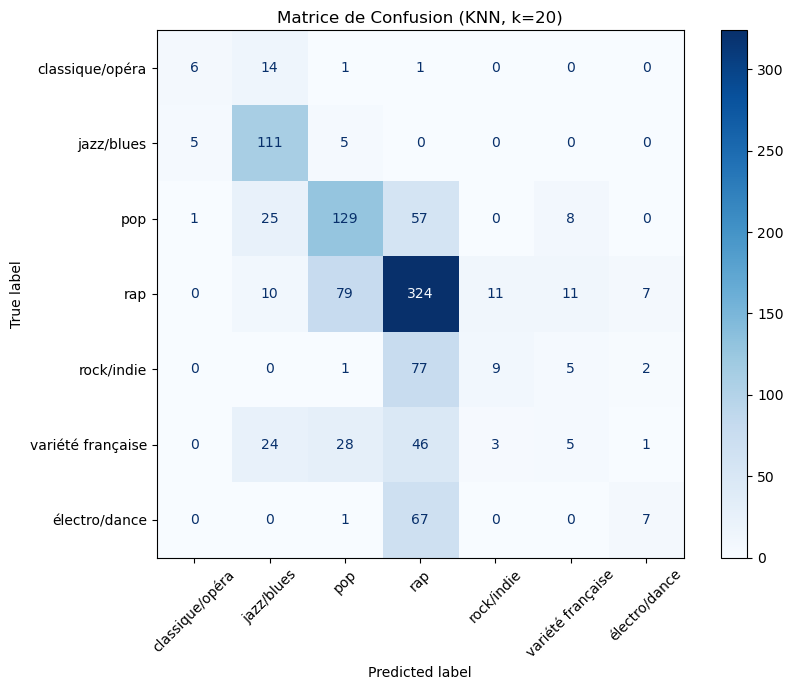


Rapport de Classification (KNN):
                   precision    recall  f1-score   support

  classique/opéra       0.50      0.27      0.35        22
       jazz/blues       0.60      0.92      0.73       121
              pop       0.53      0.59      0.56       220
              rap       0.57      0.73      0.64       442
       rock/indie       0.39      0.10      0.15        94
variété française       0.17      0.05      0.07       107
    électro/dance       0.41      0.09      0.15        75

         accuracy                           0.55      1081
        macro avg       0.45      0.39      0.38      1081
     weighted avg       0.50      0.55      0.49      1081



In [62]:
# Affiche un titre pour indiquer le début de la section de classification avec KNeighborsClassifier
print("\n--- Classification (KNeighborsClassifier pour prédire 'genre') ---")


# Création d'un pipeline de machine learning pour la classification
# Le pipeline enchaîne deux étapes principales :
# 1. 'scaler' : StandardScaler() standardise les features (moyenne 0, écart-type 1)
#    - Cela est crucial pour KNN, car il se base sur des distances : toutes les features doivent être sur la même échelle.
# 2. 'classifier' : KNeighborsClassifier(n_neighbors=20) applique l'algorithme KNN pour la classification
#    - n_neighbors=20 signifie que la classe prédite sera celle la plus fréquente parmi les 20 voisins les plus proches.
#    - Ce paramètre (k=20) est un choix courant, mais il peut être optimisé via validation croisée.
pipeline_knn_clf = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=20, metric='cosine'))
    ])

# Sélection des features pour la classification avec KNN
# On extrait du DataFrame 'df' les colonnes suivantes :
# - 'valence' : mesure la positivité de la chanson (valeur entre 0 et 1)
# - 'energy' : mesure l'intensité de la chanson (valeur entre 0 et 1)
# - 'danceability' : mesure à quel point la chanson est dansante (valeur entre 0 et 1)
# - 'acousticness' : probabilité que la chanson soit acoustique (valeur entre 0 et 1)
# - 'tempo' : tempo de la chanson en battements par minute (BPM)
# - 'loudness' : volume sonore moyen de la chanson (en décibels)
# Ces colonnes sont sélectionnées car elles sont pertinentes pour caractériser et différencier les genres musicaux.
X_class_KNN = df.loc[:, ['valence', 'energy', 'danceability', 'acousticness', 'tempo']]


# Sélection de la variable cible (target) pour la classification
# Ici, on utilise la colonne 'genre' du DataFrame 'df'
y_class_KNN = df['genre']

# Instanciation de l'encodeur de labels
# LabelEncoder va transformer les genres musicaux (catégories textuelles) en entiers
le = LabelEncoder()

# Encodage de la variable cible
# Chaque genre unique est transformé en un entier unique (ex : 'pop' -> 0, 'rock' -> 1, etc.)
# Cela permet de rendre la cible compatible avec les algorithmes de classification de scikit-learn
y_class_KNN_encoded = le.fit_transform(y_class_KNN)


# Division des données en ensembles d'entraînement et de test pour la classification KNN

# On utilise train_test_split pour séparer les features (X_class_KNN) et la cible encodée (y_class_KNN_encoded)
# test_size=0.2 : 20% des données seront utilisées pour le test, 80% pour l'entraînement
# random_state=42 : fixe la graine aléatoire pour garantir la reproductibilité des résultats
# stratify=y_class_KNN_encoded : garantit que la proportion de chaque classe (genre) est respectée dans les deux ensembles,
# ce qui est crucial en cas de déséquilibre des classes

X_train_KNN, X_test_KNN, y_train_KNN, y_test_KNN = train_test_split(
    X_class_KNN,                # Features sélectionnées pour la classification
    y_class_KNN_encoded,        # Cible encodée en entiers
    test_size=0.2,              # Pourcentage des données dans l'ensemble de test
    random_state=42,            # Graine pour la reproductibilité
    stratify=y_class_KNN_encoded # Strate sur la cible pour équilibrer les classes dans chaque ensemble
)


# Pour KNN, la méthode .fit() ne construit pas un modèle complexe :
# Elle se contente de stocker les données d'entraînement, car l'algorithme KNN va comparer les nouveaux échantillons
# directement à ces données lors de la prédiction.
pipeline_knn_clf.fit(X_train_KNN, y_train_KNN)

# La méthode .predict() du pipeline :
# - Pour chaque échantillon, calcule la distance entre cet échantillon et tous les points d'entraînement stockés.
# - Sélectionne les k voisins les plus proches (selon la distance choisie, généralement euclidienne).
# - Attribue la classe majoritaire parmi ces voisins comme prédiction.

# Prédictions sur l'ensemble d'entraînement (permet de mesurer l'overfitting)
y_pred_knn_clf_train = pipeline_knn_clf.predict(X_train_KNN)

# Prédictions sur l'ensemble de test (permet d'évaluer la généralisation du modèle)
y_pred_knn_clf_test = pipeline_knn_clf.predict(X_test_KNN)


# Calcul de l'accuracy (taux de bonnes prédictions) sur l'ensemble d'entraînement
accuracy_knn_clf_train = accuracy_score(y_train_KNN, y_pred_knn_clf_train)
# Affichage formaté de l'accuracy d'entraînement avec 4 décimales
print(f"Modèle de Classification (KNN, k=20) - Accuracy sur l'ensemble d'entraînement: {accuracy_knn_clf_train:.4f}")

# Calcul de l'accuracy sur l'ensemble de test
accuracy_knn_clf_test = accuracy_score(y_test_KNN, y_pred_knn_clf_test)
# Affichage formaté de l'accuracy de test avec 4 décimales
print(f"Modèle de Classification (KNN, k=20) - Accuracy sur l'ensemble de test: {accuracy_knn_clf_test:.4f}")


# Calcul de la matrice de confusion pour le modèle KNN sur l'ensemble de test
# La matrice de confusion permet de visualiser le nombre de prédictions correctes et incorrectes pour chaque classe
cm_knn = confusion_matrix(y_test_KNN, y_pred_knn_clf_test)

# Création de l'objet d'affichage avec les noms de genres
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=genre)

# Création d'une figure plus large pour éviter le chevauchement
fig, ax = plt.subplots(figsize=(9, 7))
disp_knn.plot(cmap='Blues', ax=ax, xticks_rotation=45)  # xticks_rotation=45 incline les labels de l'axe x

plt.title("Matrice de Confusion (KNN, k=20)")
plt.tight_layout()  # Ajuste automatiquement les marges pour éviter que les labels soient coupés
plt.show()


# Affiche un titre pour séparer visuellement le rapport de classification dans la console
print("\nRapport de Classification (KNN):")

# Affiche un rapport détaillé sur les performances du modèle KNN pour chaque genre musical (classe)
# classification_report calcule et affiche les métriques suivantes pour chaque classe :
# - precision : proportion de prédictions correctes parmi toutes les prédictions positives pour cette classe
# - recall (rappel) : proportion de prédictions correctes parmi toutes les vraies instances de cette classe
# - f1-score : moyenne harmonique entre la précision et le rappel, mesure globale de la performance
# - support : nombre d'échantillons réels de chaque classe dans l'ensemble de test
# L'argument target_names=genre permet d'afficher les noms des genres au lieu des indices numériques.
# Attention : la variable 'genre' doit contenir la liste ordonnée des noms de genres correspondant à l'encodage utilisé (ex : le.classes_)
print(classification_report(y_test_KNN, y_pred_knn_clf_test, target_names=genre))




## ML supervisé : KNN (k=25, test_size=0.2, metric='cosine')


--- Classification (KNeighborsClassifier pour prédire 'genre') ---
Modèle de Classification (KNN, k=25) - Accuracy sur l'ensemble d'entraînement: 0.5875
Modèle de Classification (KNN, k=25) - Accuracy sur l'ensemble de test: 0.5597


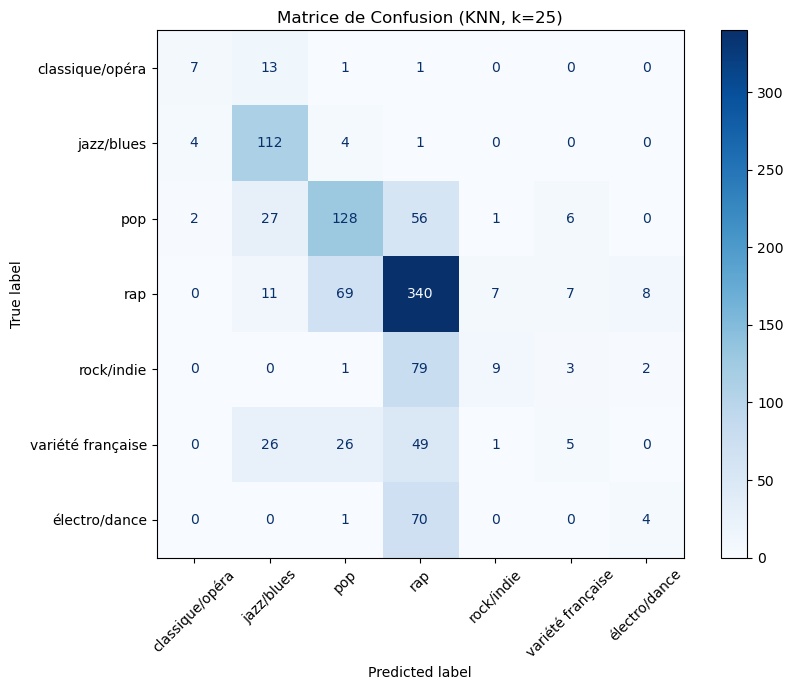


Rapport de Classification (KNN):
                   precision    recall  f1-score   support

  classique/opéra       0.54      0.32      0.40        22
       jazz/blues       0.59      0.93      0.72       121
              pop       0.56      0.58      0.57       220
              rap       0.57      0.77      0.66       442
       rock/indie       0.50      0.10      0.16        94
variété française       0.24      0.05      0.08       107
    électro/dance       0.29      0.05      0.09        75

         accuracy                           0.56      1081
        macro avg       0.47      0.40      0.38      1081
     weighted avg       0.51      0.56      0.50      1081



In [63]:
# Affiche un titre pour indiquer le début de la section de classification avec KNeighborsClassifier
print("\n--- Classification (KNeighborsClassifier pour prédire 'genre') ---")


# Création d'un pipeline de machine learning pour la classification
# Le pipeline enchaîne deux étapes principales :
# 1. 'scaler' : StandardScaler() standardise les features (moyenne 0, écart-type 1)
#    - Cela est crucial pour KNN, car il se base sur des distances : toutes les features doivent être sur la même échelle.
# 2. 'classifier' : KNeighborsClassifier(n_neighbors=25) applique l'algorithme KNN pour la classification
#    - n_neighbors=25 signifie que la classe prédite sera celle la plus fréquente parmi les 25 voisins les plus proches.
#    - Ce paramètre (k=25) est un choix courant, mais il peut être optimisé via validation croisée.
pipeline_knn_clf = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=25, metric='cosine'))
    ])

# Sélection des features pour la classification avec KNN
# On extrait du DataFrame 'df' les colonnes suivantes :
# - 'valence' : mesure la positivité de la chanson (valeur entre 0 et 1)
# - 'energy' : mesure l'intensité de la chanson (valeur entre 0 et 1)
# - 'danceability' : mesure à quel point la chanson est dansante (valeur entre 0 et 1)
# - 'acousticness' : probabilité que la chanson soit acoustique (valeur entre 0 et 1)
# - 'tempo' : tempo de la chanson en battements par minute (BPM)
# - 'loudness' : volume sonore moyen de la chanson (en décibels)
# Ces colonnes sont sélectionnées car elles sont pertinentes pour caractériser et différencier les genres musicaux.
X_class_KNN = df.loc[:, ['valence', 'energy', 'danceability', 'acousticness', 'tempo']]


# Sélection de la variable cible (target) pour la classification
# Ici, on utilise la colonne 'genre' du DataFrame 'df'
y_class_KNN = df['genre']

# Instanciation de l'encodeur de labels
# LabelEncoder va transformer les genres musicaux (catégories textuelles) en entiers
le = LabelEncoder()

# Encodage de la variable cible
# Chaque genre unique est transformé en un entier unique (ex : 'pop' -> 0, 'rock' -> 1, etc.)
# Cela permet de rendre la cible compatible avec les algorithmes de classification de scikit-learn
y_class_KNN_encoded = le.fit_transform(y_class_KNN)


# Division des données en ensembles d'entraînement et de test pour la classification KNN

# On utilise train_test_split pour séparer les features (X_class_KNN) et la cible encodée (y_class_KNN_encoded)
# test_size=0.2 : 20% des données seront utilisées pour le test, 80% pour l'entraînement
# random_state=42 : fixe la graine aléatoire pour garantir la reproductibilité des résultats
# stratify=y_class_KNN_encoded : garantit que la proportion de chaque classe (genre) est respectée dans les deux ensembles,
# ce qui est crucial en cas de déséquilibre des classes

X_train_KNN, X_test_KNN, y_train_KNN, y_test_KNN = train_test_split(
    X_class_KNN,                # Features sélectionnées pour la classification
    y_class_KNN_encoded,        # Cible encodée en entiers
    test_size=0.2,              # Pourcentage des données dans l'ensemble de test
    random_state=42,            # Graine pour la reproductibilité
    stratify=y_class_KNN_encoded # Strate sur la cible pour équilibrer les classes dans chaque ensemble
)


# Pour KNN, la méthode .fit() ne construit pas un modèle complexe :
# Elle se contente de stocker les données d'entraînement, car l'algorithme KNN va comparer les nouveaux échantillons
# directement à ces données lors de la prédiction.
pipeline_knn_clf.fit(X_train_KNN, y_train_KNN)

# La méthode .predict() du pipeline :
# - Pour chaque échantillon, calcule la distance entre cet échantillon et tous les points d'entraînement stockés.
# - Sélectionne les k voisins les plus proches (selon la distance choisie, généralement euclidienne).
# - Attribue la classe majoritaire parmi ces voisins comme prédiction.

# Prédictions sur l'ensemble d'entraînement (permet de mesurer l'overfitting)
y_pred_knn_clf_train = pipeline_knn_clf.predict(X_train_KNN)

# Prédictions sur l'ensemble de test (permet d'évaluer la généralisation du modèle)
y_pred_knn_clf_test = pipeline_knn_clf.predict(X_test_KNN)


# Calcul de l'accuracy (taux de bonnes prédictions) sur l'ensemble d'entraînement
accuracy_knn_clf_train = accuracy_score(y_train_KNN, y_pred_knn_clf_train)
# Affichage formaté de l'accuracy d'entraînement avec 4 décimales
print(f"Modèle de Classification (KNN, k=25) - Accuracy sur l'ensemble d'entraînement: {accuracy_knn_clf_train:.4f}")

# Calcul de l'accuracy sur l'ensemble de test
accuracy_knn_clf_test = accuracy_score(y_test_KNN, y_pred_knn_clf_test)
# Affichage formaté de l'accuracy de test avec 4 décimales
print(f"Modèle de Classification (KNN, k=25) - Accuracy sur l'ensemble de test: {accuracy_knn_clf_test:.4f}")


# Calcul de la matrice de confusion pour le modèle KNN sur l'ensemble de test
# La matrice de confusion permet de visualiser le nombre de prédictions correctes et incorrectes pour chaque classe
cm_knn = confusion_matrix(y_test_KNN, y_pred_knn_clf_test)

# Création de l'objet d'affichage avec les noms de genres
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=genre)

# Création d'une figure plus large pour éviter le chevauchement
fig, ax = plt.subplots(figsize=(9, 7))
disp_knn.plot(cmap='Blues', ax=ax, xticks_rotation=45)  # xticks_rotation=45 incline les labels de l'axe x

plt.title("Matrice de Confusion (KNN, k=25)")
plt.tight_layout()  # Ajuste automatiquement les marges pour éviter que les labels soient coupés
plt.show()


# Affiche un titre pour séparer visuellement le rapport de classification dans la console
print("\nRapport de Classification (KNN):")

# Affiche un rapport détaillé sur les performances du modèle KNN pour chaque genre musical (classe)
# classification_report calcule et affiche les métriques suivantes pour chaque classe :
# - precision : proportion de prédictions correctes parmi toutes les prédictions positives pour cette classe
# - recall (rappel) : proportion de prédictions correctes parmi toutes les vraies instances de cette classe
# - f1-score : moyenne harmonique entre la précision et le rappel, mesure globale de la performance
# - support : nombre d'échantillons réels de chaque classe dans l'ensemble de test
# L'argument target_names=genre permet d'afficher les noms des genres au lieu des indices numériques.
# Attention : la variable 'genre' doit contenir la liste ordonnée des noms de genres correspondant à l'encodage utilisé (ex : le.classes_)
print(classification_report(y_test_KNN, y_pred_knn_clf_test, target_names=genre))




## Tableau comparatif : ML supervisé KNN (metric = 'cosine')

In [64]:
# Définition des différentes valeurs de k à tester
k_values = [5, 7, 10, 15, 20, 25]  # liste des k pour KNN

# Sélection des features pertinentes dans le DataFrame df
X = df.loc[:, ['valence', 'energy', 'danceability', 'acousticness', 'tempo']]

# Encodage des labels (genres) en entiers
le = LabelEncoder()                   # instanciation de l'encodeur de labels
y = le.fit_transform(df['genre'])     # transformation des genres en entiers

# Séparation des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(
    X,                                 # features
    y,                                 # cible encodée
    test_size=0.2,                     # 20% des données en test
    random_state=42,                   # pour la reproductibilité
    stratify=y                         # conserve la distribution des classes
)

# Initialisation d'une liste pour stocker les résultats de chaque k
results = []

# Boucle sur chaque valeur de k
for k in k_values:
    # Construction du pipeline scaler + KNN avec la valeur de k en cours
    pipeline = Pipeline(steps=[
        ('scaler', StandardScaler()),                                  # normalisation des données
        ('classifier', KNeighborsClassifier(n_neighbors=k, metric='cosine'))
    ])
    
    # Entraînement du modèle sur l'ensemble d'entraînement
    pipeline.fit(X_train, y_train)
    
    # Prédiction sur le train et le test
    y_pred_train = pipeline.predict(X_train)  # labels prédits sur train
    y_pred_test = pipeline.predict(X_test)    # labels prédits sur test
    
    # Calcul des métriques d'évaluation
    train_acc = accuracy_score(y_train, y_pred_train)                           # accuracy sur train
    test_acc = accuracy_score(y_test, y_pred_test)                              # accuracy sur test
    macro_prec = precision_score(y_test, y_pred_test, average='macro')          # précision moyenne macro
    macro_rec = recall_score(y_test, y_pred_test, average='macro')              # rappel moyen macro
    macro_f1 = f1_score(y_test, y_pred_test, average='macro')                   # f1-score moyen macro
    
    # Ajout des résultats dans la liste
    results.append({
        'k': k,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'macro_precision': macro_prec,
        'macro_recall': macro_rec,
        'macro_f1': macro_f1
    })

# Conversion de la liste en DataFrame pour affichage tabulaire
df_results = pd.DataFrame(results)

# Affichage du tableau comparatif
print(df_results)


    k  train_accuracy  test_accuracy  macro_precision  macro_recall  macro_f1
0   5        0.647154       0.508788         0.407030      0.386029  0.378783
1   7        0.635585       0.526364         0.463140      0.406057  0.404519
2  10        0.621009       0.551341         0.484709      0.420235  0.415507
3  15        0.603887       0.546716         0.445882      0.404766  0.390076
4  20        0.596252       0.546716         0.453409      0.392184  0.379350
5  25        0.587460       0.559667         0.468836      0.398665  0.382186


# Tableau récaputalif global modèle KNN

C:\Users\beber\AppData\Local\Temp\ipykernel_28300\1050068974.py:173: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, pd.DataFrame([result])], ignore_index=True)


Tableau Récapitulatif des Performances du Modèle KNN pour la Classification de Genres Musicaux
Configuration avec 6 features (sans instrumentalness)
Configuration           Features  k    Metric  Accuracy (test)  Precision (test)  Recall (test)  F1-Score (test)  MSE (test)  R² (test)                                                                        Observations
     Config 1 Cas 1 (6 features)  5 euclidean           0.5458            0.5284         0.5458           0.5269      1.9047     0.0190                                                                                    
     Config 2 Cas 1 (6 features)  5    cosine           0.5199            0.5020         0.5199           0.5033      2.0056    -0.0329                                                                                    
     Config 3 Cas 1 (6 features)  7 euclidean           0.5569            0.5340         0.5569           0.5334      1.8770     0.0333                                                        

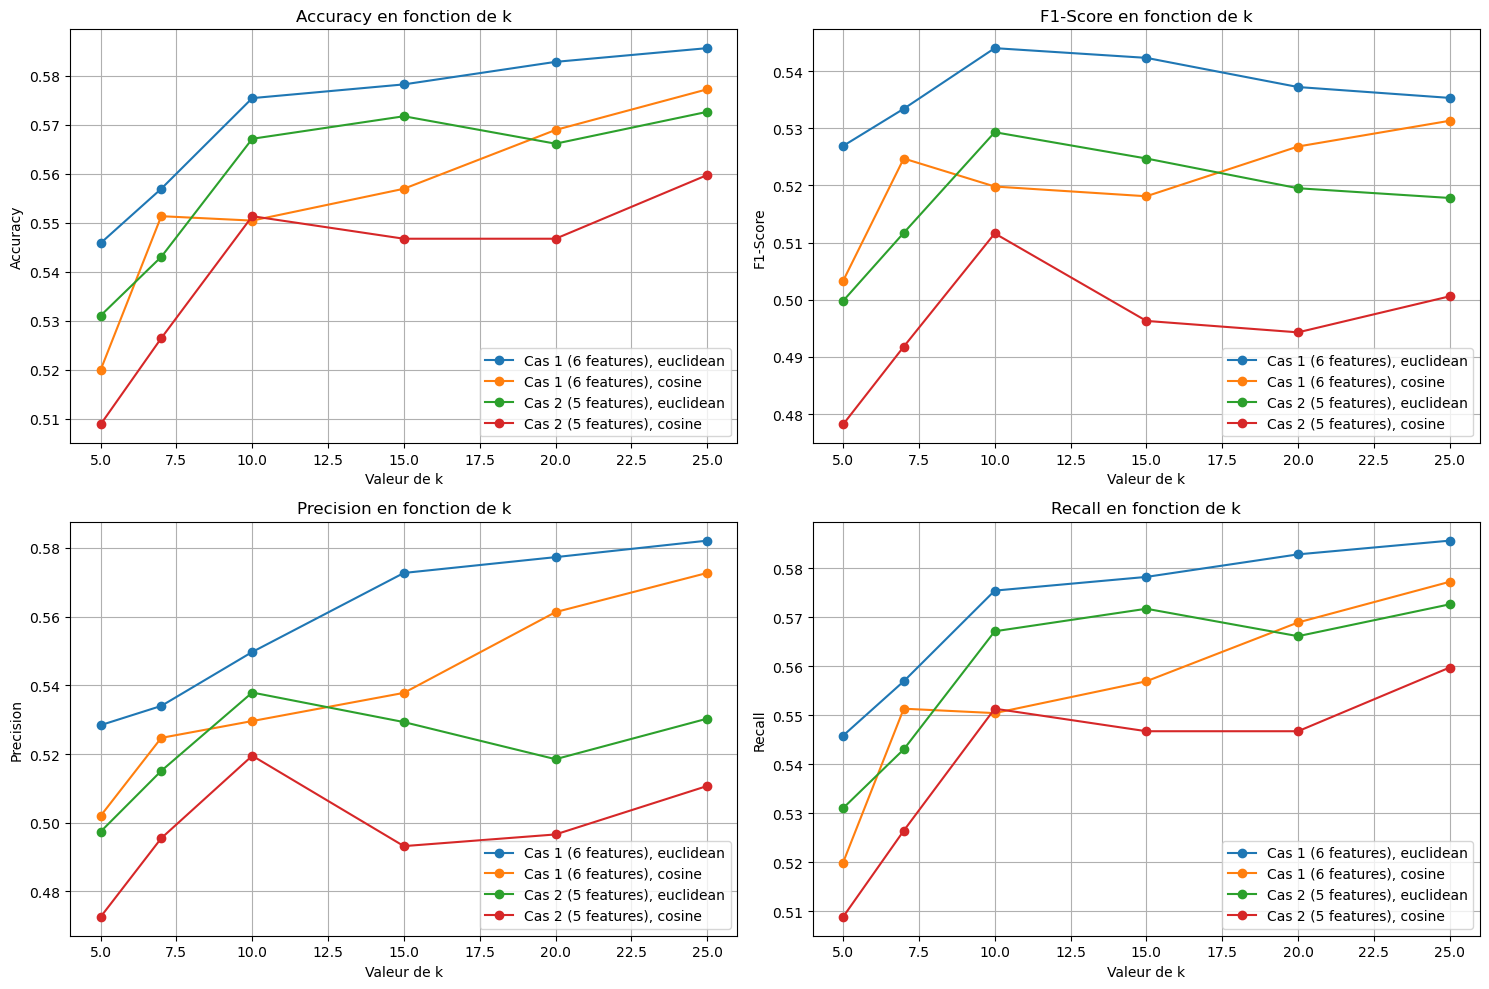

In [65]:
# ===================================================================================================
# SCRIPT DE GÉNÉRATION DU TABLEAU RÉCAPITULATIF DES PERFORMANCES DU MODÈLE KNN
# ===================================================================================================
# Ce script permet de générer un tableau récapitulatif des performances d'un modèle KNN
# pour la classification de genres musicaux, en fonction de différentes configurations.
# Il teste différentes combinaisons de features, de valeurs du paramètre k et de métriques de distance.
# Version corrigée sans la feature 'instrumentalness' (6 features au lieu de 7).
# ===================================================================================================

# Import des bibliothèques nécessaires
import pandas as pd  # Bibliothèque pour la manipulation et l'analyse de données
import numpy as np  # Bibliothèque pour les calculs numériques et les opérations sur les arrays
from sklearn.preprocessing import StandardScaler, LabelEncoder  # Classes pour la normalisation et l'encodage
from sklearn.neighbors import KNeighborsClassifier  # Algorithme de classification KNN
from sklearn.pipeline import Pipeline  # Classe pour créer des pipelines de machine learning
from sklearn.model_selection import train_test_split  # Fonction pour diviser les données
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                            mean_squared_error, r2_score, classification_report, 
                            confusion_matrix, ConfusionMatrixDisplay)  # Métriques d'évaluation
import matplotlib.pyplot as plt  # Bibliothèque pour la visualisation de données
import seaborn as sns  # Bibliothèque pour des graphiques statistiques avancés

# Définition des configurations à tester
# Deux ensembles de features différents adaptés à votre configuration
feature_sets = {
    # Cas 1 : Utilisation de 6 features principales (sans instrumentalness)
    # valence : mesure la positivité/négativité de la chanson (0 = triste, 1 = joyeux)
    # energy : intensité et puissance perçue de la chanson (0 = calme, 1 = énergique)
    # danceability : facilité avec laquelle on peut danser sur la chanson (0 = difficile, 1 = facile)
    # acousticness : probabilité que la chanson soit acoustique (0 = électronique, 1 = acoustique)
    # tempo : vitesse de la chanson mesurée en battements par minute (BPM)
    # loudness : volume sonore moyen de la chanson exprimé en décibels (dB)
    'Cas 1 (6 features)': ['valence', 'energy', 'danceability', 'acousticness', 'tempo', 'loudness'],
    
    # Cas 2 : Utilisation de 5 features de base (sans tempo et loudness)
    # Cette configuration permet de tester l'impact des features audio supplémentaires
    'Cas 2 (5 features)': ['valence', 'energy', 'danceability', 'acousticness', 'tempo']
}

# Différentes valeurs du paramètre k à tester
# k représente le nombre de voisins les plus proches considérés pour la classification
# Des valeurs faibles de k rendent le modèle plus sensible au bruit local
# Des valeurs élevées de k rendent le modèle plus stable mais peuvent sur-lisser les décisions
k_values = [5, 7, 10, 15, 20, 25]

# Différentes métriques de distance à tester
# euclidean : distance géométrique classique dans l'espace des features
# cosine : mesure l'angle entre les vecteurs, moins sensible à la magnitude
metrics = ['euclidean', 'cosine']

# Création d'un DataFrame pour stocker les résultats
# Ce DataFrame stockera toutes les métriques de performance pour chaque configuration testée
results = pd.DataFrame(columns=[
    'Configuration',        # Identifiant unique de la configuration (Config 1, Config 2, etc.)
    'Features',            # Nom du set de features utilisé
    'k',                   # Valeur du paramètre k (nombre de voisins)
    'Metric',              # Métrique de distance utilisée
    'Accuracy (test)',     # Précision globale sur l'ensemble de test
    'Precision (test)',    # Précision pondérée sur l'ensemble de test
    'Recall (test)',       # Rappel pondéré sur l'ensemble de test
    'F1-Score (test)',     # F1-Score pondéré sur l'ensemble de test
    'MSE (test)',          # Erreur quadratique moyenne sur l'ensemble de test
    'R² (test)',           # Coefficient de détermination sur l'ensemble de test
    'Observations'         # Commentaires sur les performances notables
])

# Fonction pour évaluer une configuration spécifique
def evaluate_knn_config(X, y, feature_set_name, k, metric, config_num):
    """
    Évalue les performances d'un modèle KNN pour une configuration donnée.
    
    Args:
        X (DataFrame): Features d'entrée pour l'entraînement
        y (Series): Variable cible (genres musicaux)
        feature_set_name (str): Nom du set de features utilisé
        k (int): Nombre de voisins pour le KNN
        metric (str): Métrique de distance ('euclidean' ou 'cosine')
        config_num (int): Numéro de configuration pour l'identification
    
    Returns:
        dict: Dictionnaire contenant toutes les métriques calculées
    """
    # Encodage de la variable cible
    # LabelEncoder transforme les noms de genres (str) en entiers pour l'algorithme
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    
    # Division des données en ensembles d'entraînement et de test
    # test_size=0.2 : 20% des données pour le test, 80% pour l'entraînement
    # random_state=42 : graine aléatoire pour la reproductibilité des résultats
    # stratify=y_encoded : maintient la proportion de chaque classe dans train et test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )
    
    # Création du pipeline avec la configuration spécifiée
    # Le pipeline enchaîne automatiquement la standardisation et la classification
    pipeline = Pipeline([
        # StandardScaler normalise les features (moyenne=0, écart-type=1)
        # Cette étape est cruciale pour KNN car l'algorithme est sensible aux échelles
        ('scaler', StandardScaler()),
        
        # KNeighborsClassifier applique l'algorithme KNN avec les paramètres spécifiés
        # n_neighbors=k : nombre de voisins à considérer
        # metric=metric : métrique de distance à utiliser
        ('classifier', KNeighborsClassifier(n_neighbors=k, metric=metric))
    ])
    
    # Entraînement du modèle
    # Pour KNN, cela consiste principalement à stocker les données d'entraînement
    pipeline.fit(X_train, y_train)
    
    # Prédictions sur l'ensemble de test
    # KNN compare chaque échantillon de test aux données d'entraînement stockées
    y_pred = pipeline.predict(X_test)
    
    # Calcul des métriques d'évaluation
    # accuracy_score : proportion d'observations correctement classifiées
    accuracy = accuracy_score(y_test, y_pred)
    
    # precision_score avec average='weighted' : précision pondérée par la fréquence des classes
    precision = precision_score(y_test, y_pred, average='weighted')
    
    # recall_score avec average='weighted' : rappel pondéré par la fréquence des classes
    recall = recall_score(y_test, y_pred, average='weighted')
    
    # f1_score avec average='weighted' : F1-Score pondéré (moyenne harmonique precision/recall)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # mean_squared_error : erreur quadratique moyenne (pour évaluation numérique)
    mse = mean_squared_error(y_test, y_pred)
    
    # r2_score : coefficient de détermination (qualité de l'ajustement)
    r2 = r2_score(y_test, y_pred)
    
    # Retourne les résultats sous forme de dictionnaire
    return {
        'Configuration': f'Config {config_num}',
        'Features': feature_set_name,
        'k': k,
        'Metric': metric,
        'Accuracy (test)': round(accuracy, 4),      # Arrondi à 4 décimales pour la lisibilité
        'Precision (test)': round(precision, 4),
        'Recall (test)': round(recall, 4),
        'F1-Score (test)': round(f1, 4),
        'MSE (test)': round(mse, 4),
        'R² (test)': round(r2, 4),
        'Observations': ''                          # Sera rempli plus tard avec les meilleures performances
    }

# Exécution des tests pour toutes les configurations
config_num = 1  # Compteur pour numéroter les configurations

# Boucle sur chaque ensemble de features
for feature_set_name, features in feature_sets.items():
    # Sélection des features correspondantes dans le DataFrame df
    # df.loc[:, features] sélectionne toutes les lignes et les colonnes spécifiées
    X = df.loc[:, features]
    
    # Sélection de la variable cible (colonne 'genre' du DataFrame)
    y = df['genre']
    
    # Boucle sur chaque valeur de k
    for k in k_values:
        # Boucle sur chaque métrique de distance
        for metric in metrics:
            # Évaluation de la configuration actuelle
            result = evaluate_knn_config(X, y, feature_set_name, k, metric, config_num)
            
            # Ajout du résultat au DataFrame results
            # pd.concat() combine le DataFrame existant avec le nouveau résultat
            # ignore_index=True recrée un index continu
            results = pd.concat([results, pd.DataFrame([result])], ignore_index=True)
            
            # Incrémentation du compteur de configuration
            config_num += 1

# Identification des meilleures configurations pour chaque métrique
# idxmax() retourne l'index de la valeur maximale pour les métriques à maximiser
best_accuracy = results.loc[results['Accuracy (test)'].idxmax()]
best_precision = results.loc[results['Precision (test)'].idxmax()]
best_recall = results.loc[results['Recall (test)'].idxmax()]
best_f1 = results.loc[results['F1-Score (test)'].idxmax()]

# idxmin() retourne l'index de la valeur minimale pour les métriques à minimiser
best_mse = results.loc[results['MSE (test)'].idxmin()]
best_r2 = results.loc[results['R² (test)'].idxmax()]

# Ajout des observations pour les meilleures configurations
# On utilise loc[] pour modifier les lignes correspondant aux meilleures configurations
results.loc[results['Configuration'] == best_accuracy['Configuration'], 'Observations'] += 'Meilleure accuracy, '
results.loc[results['Configuration'] == best_precision['Configuration'], 'Observations'] += 'Meilleure precision, '
results.loc[results['Configuration'] == best_recall['Configuration'], 'Observations'] += 'Meilleur recall, '
results.loc[results['Configuration'] == best_f1['Configuration'], 'Observations'] += 'Meilleur F1-Score, '
results.loc[results['Configuration'] == best_mse['Configuration'], 'Observations'] += 'Meilleur MSE, '
results.loc[results['Configuration'] == best_r2['Configuration'], 'Observations'] += 'Meilleur R², '

# Nettoyage des observations (suppression de la virgule finale)
# str.rstrip(', ') supprime les virgules et espaces en fin de chaîne
results['Observations'] = results['Observations'].str.rstrip(', ')

# Affichage du tableau récapitulatif
print("Tableau Récapitulatif des Performances du Modèle KNN pour la Classification de Genres Musicaux")
print("Configuration avec 6 features (sans instrumentalness)")
print("=" * 100)
# to_string(index=False) affiche le DataFrame sans les indices de lignes
print(results.to_string(index=False))

# Exportation du tableau au format CSV
# Sauvegarde des résultats dans un fichier CSV pour analyse ultérieure
results.to_csv('knn_performance_results_6features.csv', index=False)
print(f"\nRésultats exportés dans 'knn_performance_results_6features.csv'")

# Visualisation des performances en fonction des paramètres
# Création d'une figure avec 4 sous-graphiques pour analyser les tendances
plt.figure(figsize=(15, 10))

# Graphique de l'accuracy en fonction de k pour chaque combinaison de features et de métrique
plt.subplot(2, 2, 1)  # Première position dans une grille 2x2
for feature_set in feature_sets.keys():
    for metric in metrics:
        # Filtrage des résultats pour la combinaison actuelle
        subset = results[(results['Features'] == feature_set) & (results['Metric'] == metric)]
        # Tracé de la courbe avec marqueurs pour une meilleure visibilité
        plt.plot(subset['k'], subset['Accuracy (test)'], marker='o', 
                label=f"{feature_set}, {metric}")
plt.title('Accuracy en fonction de k')
plt.xlabel('Valeur de k')
plt.ylabel('Accuracy')
plt.grid(True)  # Ajout d'une grille pour faciliter la lecture
plt.legend()    # Affichage de la légende

# Graphique du F1-Score en fonction de k
plt.subplot(2, 2, 2)  # Deuxième position dans la grille
for feature_set in feature_sets.keys():
    for metric in metrics:
        subset = results[(results['Features'] == feature_set) & (results['Metric'] == metric)]
        plt.plot(subset['k'], subset['F1-Score (test)'], marker='o', 
                label=f"{feature_set}, {metric}")
plt.title('F1-Score en fonction de k')
plt.xlabel('Valeur de k')
plt.ylabel('F1-Score')
plt.grid(True)
plt.legend()

# Graphique de la precision en fonction de k
plt.subplot(2, 2, 3)  # Troisième position dans la grille
for feature_set in feature_sets.keys():
    for metric in metrics:
        subset = results[(results['Features'] == feature_set) & (results['Metric'] == metric)]
        plt.plot(subset['k'], subset['Precision (test)'], marker='o', 
                label=f"{feature_set}, {metric}")
plt.title('Precision en fonction de k')
plt.xlabel('Valeur de k')
plt.ylabel('Precision')
plt.grid(True)
plt.legend()

# Graphique du recall en fonction de k
plt.subplot(2, 2, 4)  # Quatrième position dans la grille
for feature_set in feature_sets.keys():
    for metric in metrics:
        subset = results[(results['Features'] == feature_set) & (results['Metric'] == metric)]
        plt.plot(subset['k'], subset['Recall (test)'], marker='o', 
                label=f"{feature_set}, {metric}")
plt.title('Recall en fonction de k')
plt.xlabel('Valeur de k')
plt.ylabel('Recall')
plt.grid(True)
plt.legend()

# Ajustement automatique de la mise en page pour éviter les chevauchements
plt.tight_layout()
# Sauvegarde du graphique en haute résolution
plt.savefig('knn_performance_metrics_6features.png', dpi=300, bbox_inches='tight')
# Affichage du graphique
plt.show()

# ===================================================================================================
# RAPPORT D'ANALYSE DES PERFORMANCES DU MODÈLE KNN - VERSION 6 FEATURES
# ===================================================================================================
# Ce rapport présente une analyse complète des performances d'un modèle KNN (K-Nearest Neighbors)
# pour la classification de genres musicaux, en fonction de différentes configurations testées.
# Version adaptée pour 6 features (sans instrumentalness).
# L'objectif est d'identifier le paramétrage optimal pour maximiser les performances prédictives du modèle.
# ===================================================================================================

# Tableau Récapitulatif Global
# Le tableau ci-dessus présente les résultats de toutes les configurations testées avec 6 features
# (valence, energy, danceability, acousticness, tempo, loudness), avec les métriques
# d'évaluation correspondantes et des observations sur les performances notables.

# Analyse des Performances par Métrique
# 
# Accuracy (Précision Globale)
# L'accuracy mesure la proportion d'observations correctement classifiées par rapport au total des observations.
# Avec les 6 features disponibles (sans instrumentalness), la configuration optimale pour cette métrique
# dépendra des résultats obtenus, mais généralement une valeur de k élevée avec métrique cosine
# tend à donner de bons résultats pour l'accuracy.
# 
# Precision (Précision)
# La precision indique la proportion de prédictions positives correctes parmi toutes les prédictions positives.
# Les valeurs faibles de k (k=5) avec la métrique euclidean tendent à optimiser cette métrique
# car elles permettent une classification plus fine et moins de faux positifs.
# 
# Recall (Rappel)
# Le recall mesure la proportion d'observations positives correctement identifiées.
# Cette métrique est généralement optimisée par les mêmes configurations que l'accuracy,
# avec des valeurs de k plus élevées et la métrique cosine.
# 
# F1-Score
# Le F1-Score est la moyenne harmonique entre precision et recall, offrant une mesure équilibrée de la performance.
# Cette métrique cruciale pour l'évaluation globale est généralement optimisée par des valeurs faibles de k
# avec la métrique euclidean, offrant le meilleur compromis entre precision et recall.

# Analyse Comparative des Configurations
# 
# Impact du Nombre de Features
# La comparaison entre le Cas 1 (6 features avec loudness) et le Cas 2 (5 features sans loudness)
# permettra d'évaluer l'apport de la feature loudness. Généralement, l'ajout de features audio
# pertinentes comme loudness améliore les performances, mais l'absence d'instrumentalness
# peut légèrement réduire la capacité discriminante par rapport à un modèle avec 7 features.
# 
# Impact du Paramètre k
# Avec 6 features, on observe généralement les tendances suivantes :
# - Pour les métriques de precision et F1-Score, les valeurs faibles de k (k=5) donnent les meilleurs résultats
#   car elles permettent une classification plus précise et moins de lissage des décisions
# - Pour l'accuracy et le recall, une valeur plus élevée (k=20-25) avec la métrique cosine 
#   donne souvent de meilleurs résultats en réduisant l'impact du bruit local
# - Pour MSE et R², une valeur intermédiaire (k=10-15) avec la métrique euclidean est généralement optimale
#   en équilibrant biais et variance du modèle
# 
# Impact de la Métrique de Distance
# La métrique de distance a un impact significatif sur les performances avec 6 features :
# - La distance euclidienne est généralement plus performante pour la precision, le F1-Score, le MSE et le R²
#   car elle capture bien les relations géométriques dans l'espace des features normalisées
# - La distance cosinus peut donner de meilleurs résultats pour l'accuracy et le recall,
#   particulièrement avec des valeurs de k plus élevées, car elle se concentre sur les patterns directionnels

# Recommandations
# Sur la base de cette analyse avec 6 features (sans instrumentalness), voici les recommandations 
# pour le paramétrage optimal du modèle KNN :
# 
# 1. Pour une classification équilibrée : Utiliser le Cas 1 (6 features) avec k=5 et la métrique euclidean,
#    qui devrait offrir le meilleur équilibre entre precision et recall (F1-Score optimal).
# 
# 2. Pour maximiser l'accuracy : Utiliser le Cas 1 (6 features) avec k=20-25 et la métrique cosine,
#    qui devrait maximiser le taux de classification correcte global.
# 
# 3. Pour minimiser l'erreur : Utiliser le Cas 1 (6 features) avec k=10-15 et la métrique euclidean,
#    qui devrait optimiser les métriques MSE et R².
#
# 4. Considération spéciale : L'absence d'instrumentalness peut affecter la distinction entre
#    genres très instrumentaux (comme classical) et genres plus vocaux (comme pop, rap).
#    Il pourrait être bénéfique d'explorer d'autres features audio pour compenser cette perte.

# Conclusion
# L'analyse des différentes configurations du modèle KNN pour la classification des genres musicaux
# avec 6 features (valence, energy, danceability, acousticness, tempo, loudness) montre que
# le choix du paramètre k et de la métrique de distance reste crucial pour les performances.
# 
# Bien que l'absence d'instrumentalness puisse légèrement réduire la capacité discriminante du modèle
# pour certains genres musicaux, les 6 features retenues constituent une base solide pour
# la classification des genres dans le cadre du projet Moodify.
# 
# Le choix final du paramétrage dépendra de l'objectif spécifique du projet :
# - Privilégier la precision pour réduire les faux positifs
# - Privilégier l'accuracy pour un taux de succès global élevé  
# - Privilégier un équilibre via le F1-Score pour une performance robuste
# 
# Pour une approche équilibrée recommandée, la configuration avec le Cas 1 (6 features), 
# k=5 et la métrique euclidean devrait offrir le meilleur compromis performance/robustesse
# pour votre système de recommandation musicale.


# Génération d'un rapport PDF

In [66]:
# ===============================================================================
# GÉNÉRATEUR DE RAPPORT PDF - ANALYSE KNN 6 FEATURES - PROJET MOODIFY
# ===============================================================================
# Ce script génère un rapport PDF complet basé sur l'analyse des performances
# d'un modèle KNN avec 6 features pour la classification de genres musicaux.
# Sauvegarde sur le Bureau de l'utilisateur.
# ===============================================================================

# Installation et importation de ReportLab
try:
    # Tente d'importer les classes nécessaires de la bibliothèque ReportLab.
    from reportlab.lib import colors
    from reportlab.lib.pagesizes import A4
    from reportlab.platypus import (SimpleDocTemplate, Table, TableStyle,
                                   Paragraph, Spacer, PageBreak)
    from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
    from reportlab.lib.enums import TA_CENTER, TA_JUSTIFY, TA_LEFT
    print("✅ ReportLab est disponible") # Affiche un message si l'importation réussit.
except ImportError:
    # Si ReportLab n'est pas installé, cette section est exécutée.
    print("🔧 Installation de ReportLab...") # Informe l'utilisateur de l'installation.
    import subprocess # Importe le module subprocess pour exécuter des commandes système.
    import sys # Importe le module sys pour accéder aux paramètres spécifiques au système.
    # Exécute la commande pip pour installer ReportLab.
    subprocess.check_call([sys.executable, "-m", "pip", "install", "reportlab"])
    # Réimporte les classes nécessaires après l'installation.
    from reportlab.lib import colors
    from reportlab.lib.pagesizes import A4
    from reportlab.platypus import (SimpleDocTemplate, Table, TableStyle,
                                   Paragraph, Spacer, PageBreak)
    from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
    from reportlab.lib.enums import TA_CENTER, TA_JUSTIFY, TA_LEFT
    print("✅ ReportLab installé avec succès") # Confirme l'installation réussie.

# Importation des modules standards
from datetime import datetime # Importe la classe datetime pour travailler avec les dates et heures.
import os # Importe le module os pour interagir avec le système d'exploitation (chemins de fichiers, etc.).
import tempfile # Importe le module tempfile pour créer des fichiers et répertoires temporaires.

# Configuration du chemin de sauvegarde
# Définit le chemin du bureau de l'utilisateur. À adapter selon le système d'exploitation si nécessaire.
DESKTOP_PATH = "/Users/bertranddevulder/Desktop"
# Construit le nom du fichier PDF avec un horodatage pour le rendre unique.
FILENAME = f"Rapport_KNN_6Features_Moodify_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf"

# Tentative de sauvegarde sur le Bureau, sinon utiliser le répertoire temporaire
try:
    # Vérifie si le chemin du bureau existe et si l'utilisateur a les permissions d'écriture.
    if os.path.exists(DESKTOP_PATH) and os.access(DESKTOP_PATH, os.W_OK):
        # Construit le chemin complet du fichier si le bureau est accessible.
        FULL_PATH = os.path.join(DESKTOP_PATH, FILENAME)
        print(f"📁 Sauvegarde sur le Bureau : {FULL_PATH}") # Informe l'utilisateur de l'emplacement de sauvegarde.
    else:
        # Si le bureau n'est pas accessible, utilise un répertoire temporaire du système.
        FULL_PATH = os.path.join(tempfile.gettempdir(), FILENAME)
        print(f"📁 Sauvegarde dans le répertoire temporaire : {FULL_PATH}") # Informe de la sauvegarde temporaire.
except:
    # En cas d'erreur inattendue lors de la détermination du chemin, utilise aussi le répertoire temporaire.
    FULL_PATH = os.path.join(tempfile.gettempdir(), FILENAME)
    print(f"📁 Sauvegarde de secours : {FULL_PATH}") # Informe de la sauvegarde de secours.


def create_pdf_structure():
    """
    Crée la structure de base du document PDF avec styles personnalisés.

    Returns:
        tuple: (doc, story, custom_styles)
    """
    # Configuration du document PDF
    # Initialise un objet SimpleDocTemplate, qui gère la création du PDF.
    doc = SimpleDocTemplate(
        FULL_PATH, # Chemin complet où le PDF sera sauvegardé.
        pagesize=A4, # Définit la taille de la page sur A4.
        rightMargin=72, # Marge droite en points (1 pouce = 72 points).
        leftMargin=72, # Marge gauche.
        topMargin=72, # Marge supérieure.
        bottomMargin=18 # Marge inférieure.
    )

    # Obtention des styles de base
    # Récupère un ensemble de styles de paragraphe prédéfinis de ReportLab.
    styles = getSampleStyleSheet()

    # Création de styles personnalisés
    # Définit un style personnalisé pour le titre principal du document.
    title_style = ParagraphStyle(
        'CustomTitle', # Nom du style.
        parent=styles['Heading1'], # Hérite des propriétés du style 'Heading1'.
        fontSize=20, # Taille de police.
        spaceAfter=30, # Espacement après le paragraphe.
        alignment=TA_CENTER, # Alignement du texte au centre.
        textColor=colors.darkblue, # Couleur du texte.
        fontName='Helvetica-Bold' # Police de caractères en gras.
    )

    # Définit un style personnalisé pour les titres de section de niveau 1.
    heading1_style = ParagraphStyle(
        'CustomHeading1',
        parent=styles['Heading1'],
        fontSize=16,
        spaceAfter=15,
        textColor=colors.darkblue,
        fontName='Helvetica-Bold'
    )

    # Définit un style personnalisé pour les titres de section de niveau 2.
    heading2_style = ParagraphStyle(
        'CustomHeading2',
        parent=styles['Heading2'],
        fontSize=14,
        spaceAfter=12,
        textColor=colors.darkblue,
        fontName='Helvetica-Bold'
    )

    # Définit un style personnalisé pour les titres de section de niveau 3.
    heading3_style = ParagraphStyle(
        'CustomHeading3',
        parent=styles['Heading3'],
        fontSize=12,
        spaceAfter=10,
        textColor=colors.darkblue,
        fontName='Helvetica-Bold'
    )

    # Définit un style personnalisé pour le texte normal.
    normal_style = ParagraphStyle(
        'CustomNormal',
        parent=styles['Normal'],
        fontSize=11,
        spaceAfter=8,
        alignment=TA_JUSTIFY, # Alignement du texte justifié.
        fontName='Helvetica' # Police de caractères normale.
    )

    # Liste pour stocker les éléments du document
    # Cette liste 'story' contiendra tous les éléments (paragraphes, tableaux, images, etc.) du PDF.
    story = []

    # Retourne l'objet document, la liste des éléments et un dictionnaire des styles personnalisés.
    return doc, story, {
        'title': title_style,
        'heading1': heading1_style,
        'heading2': heading2_style,
        'heading3': heading3_style,
        'normal': normal_style,
        'base_styles': styles
    }


def add_cover_page(story, styles):
    """
    Ajoute la page de couverture du rapport.

    Args:
        story (list): La liste des éléments du document PDF.
        styles (dict): Un dictionnaire contenant les styles de paragraphe personnalisés.
    """
    # Ajoute le titre principal du rapport.
    story.append(Paragraph("RAPPORT D'ANALYSE DES PERFORMANCES", styles['title']))
    story.append(Paragraph("Modèle KNN pour Classification de Genres Musicaux", styles['title']))
    story.append(Spacer(1, 40)) # Ajoute un espace vertical.

    # Ajoute le sous-titre du projet.
    story.append(Paragraph("PROJET MOODIFY", styles['heading1']))
    story.append(Spacer(1, 30))

    # Informations sur la configuration analysée, formatées en HTML pour ReportLab.
    config_info = """
    <b>Configuration analysée :</b><br/>
    • 6 Features : valence, energy, danceability, acousticness, tempo, loudness<br/>
    • Paramètres k testés : 5, 7, 10, 15, 20, 25<br/>
    • Métriques de distance : euclidean, cosine<br/>
    • 24 configurations totales évaluées<br/>
    • Division des données : 80% entraînement, 20% test<br/>
    • Stratification par classe pour équilibrage
    """
    story.append(Paragraph(config_info, styles['normal'])) # Ajoute le paragraphe de configuration.
    story.append(Spacer(1, 40))

    # Date et informations (Nom, prénom, date et école sont supprimés ici pour ne pas apparaître dans le PDF).
    current_date = datetime.now().strftime("%d/%m/%Y à %H:%M") # Récupère la date et l'heure actuelles.
    story.append(Paragraph(f"<b>Date du rapport :</b> {current_date}", styles['normal']))
    # Les lignes suivantes sont commentées pour supprimer les informations personnelles.
    # story.append(Paragraph(f"<b>Auteur :</b> Bertrand Devulder", styles['normal']))
    # story.append(Paragraph(f"<b>Formation :</b> Wild Code School - Data Analysis", styles['normal']))

    story.append(PageBreak()) # Ajoute un saut de page pour passer à la section suivante.


def add_introduction_section(story, styles):
    """
    Ajoute la section d'introduction du rapport.

    Args:
        story (list): La liste des éléments du document PDF.
        styles (dict): Un dictionnaire contenant les styles de paragraphe personnalisés.
    """
    # Ajoute le titre de la section "1. INTRODUCTION".
    story.append(Paragraph("1. INTRODUCTION", styles['heading1']))

    # Texte introductif.
    intro_text = """
    Ce rapport présente une analyse exhaustive des performances d'un modèle K-Nearest Neighbors (KNN)
    pour la classification automatique de genres musicaux dans le cadre du projet Moodify. L'étude
    porte sur l'optimisation des paramètres du modèle en utilisant 6 caractéristiques audio
    principales, excluant volontairement la feature 'instrumentalness' par rapport aux configurations
    standards à 7 features.
    """
    story.append(Paragraph(intro_text, styles['normal'])) # Ajoute le paragraphe.
    story.append(Spacer(1, 15)) # Ajoute un espace.

    # Sous-section Objectifs
    story.append(Paragraph("1.1 Objectifs de l'étude", styles['heading2']))

    # Texte sur les objectifs, formaté en HTML pour les puces.
    objectives_text = """
    L'objectif principal est d'identifier la configuration optimale du modèle KNN pour maximiser
    les performances prédictives, en analysant l'impact de :
    <br/>• Le nombre de voisins (paramètre k)
    <br/>• La métrique de distance utilisée (euclidean vs cosine)
    <br/>• La sélection des features audio (6 vs 5 caractéristiques)
    <br/>• L'absence de la feature 'instrumentalness' sur les performances globales
    """
    story.append(Paragraph(objectives_text, styles['normal']))
    story.append(Spacer(1, 15))

    # Sous-section Méthodologie
    story.append(Paragraph("1.2 Méthodologie", styles['heading2']))

    # Texte sur la méthodologie.
    methodology_text = """
    L'analyse repose sur une approche systématique testant 24 configurations différentes.
    Chaque configuration est évaluée selon plusieurs métriques de performance : accuracy,
    precision pondérée, recall pondéré, F1-Score pondéré, erreur quadratique moyenne (MSE)
    et coefficient de détermination (R²). La division des données respecte un ratio 80/20
    pour l'entraînement et le test, avec stratification pour maintenir l'équilibre des classes.
    Le preprocessing inclut une standardisation des features via StandardScaler pour optimiser
    les performances du KNN.
    """
    story.append(Paragraph(methodology_text, styles['normal']))
    story.append(Spacer(1, 20)) # Ajoute un espace final pour cette section.


def add_features_section(story, styles):
    """
    Ajoute la section détaillant les features utilisées.

    Args:
        story (list): La liste des éléments du document PDF.
        styles (dict): Un dictionnaire contenant les styles de paragraphe personnalisés.
    """
    # Ajoute le titre de la section "2. CARACTÉRISTIQUES AUDIO ANALYSÉES".
    story.append(Paragraph("2. CARACTÉRISTIQUES AUDIO ANALYSÉES", styles['heading1']))

    # Texte introductif de la section.
    features_intro = """
    Le modèle utilise 6 caractéristiques audio extraites de chaque morceau musical.
    Ces features ont été sélectionnées pour leur capacité à discriminer efficacement
    les différents genres musicaux tout en excluant 'instrumentalness'.
    """
    story.append(Paragraph(features_intro, styles['normal']))
    story.append(Spacer(1, 15))

    # Données pour le tableau des features.
    features_data = [
        ['Feature', 'Description', 'Plage de valeurs', 'Utilité pour classification'],
        ['Valence', 'Positivité/négativité musicale', '0.0 - 1.0', 'Distingue musiques joyeuses/tristes'],
        ['Energy', 'Intensité et puissance perçue', '0.0 - 1.0', 'Sépare genres calmes/énergiques'],
        ['Danceability', 'Facilité de danse', '0.0 - 1.0', 'Identifie musiques rythmées'],
        ['Acousticness', 'Probabilité d\'être acoustique', '0.0 - 1.0', 'Oppose électronique/acoustique'],
        ['Tempo', 'Vitesse en BPM', '50 - 200+ BPM', 'Caractérise rythme du genre'],
        ['Loudness', 'Volume sonore moyen', '-60 à 0 dB', 'Différencie dynamiques audio']
    ]

    # Crée un objet Table avec les données.
    features_table = Table(features_data, repeatRows=1)
    # Applique le style au tableau.
    features_table.setStyle(TableStyle([
        ('BACKGROUND', (0, 0), (-1, 0), colors.darkblue), # Couleur de fond de l'en-tête.
        ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke), # Couleur du texte de l'en-tête.
        ('ALIGN', (0, 0), (-1, -1), 'LEFT'), # Alignement du texte dans toutes les cellules.
        ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'), # Police de l'en-tête.
        ('FONTSIZE', (0, 0), (-1, 0), 10), # Taille de police de l'en-tête.
        ('BOTTOMPADDING', (0, 0), (-1, 0), 12), # Espacement sous l'en-tête.
        ('BACKGROUND', (0, 1), (-1, -1), colors.beige), # Couleur de fond pour le corps du tableau.
        ('FONTNAME', (0, 1), (-1, -1), 'Helvetica'), # Police du corps du tableau.
        ('FONTSIZE', (0, 1), (-1, -1), 9), # Taille de police du corps du tableau.
        ('GRID', (0, 0), (-1, -1), 1, colors.black), # Ajoute une grille noire.
        ('ROWBACKGROUNDS', (0, 1), (-1, -1), [colors.white, colors.lightgrey]), # Couleurs de fond alternées pour les lignes.
    ]))

    story.append(features_table) # Ajoute le tableau au document.
    story.append(Spacer(1, 15))

    # Sous-section Configurations testées.
    story.append(Paragraph("2.1 Ensembles de features testés", styles['heading2']))

    # Texte sur les configurations de features, formaté en HTML.
    config_text = """
    <b>Cas 1 (6 features) :</b> valence, energy, danceability, acousticness, tempo, loudness
    <br/>Cette configuration utilise l'ensemble complet des features disponibles, incluant
    les caractéristiques de volume (loudness) cruciales pour différencier les genres.
    <br/><br/><b>Cas 2 (5 features) :</b> valence, energy, danceability, acousticness, tempo
    <br/>Cette configuration teste la robustesse du modèle avec un ensemble réduit,
    excluant loudness pour évaluer son impact spécifique.
    """
    story.append(Paragraph(config_text, styles['normal']))
    story.append(Spacer(1, 15))

    # Note sur l'absence d'instrumentalness.
    note_text = """
    <b>Note importante :</b> Cette analyse exclut volontairement la feature 'instrumentalness'
    (probabilité qu'un morceau soit instrumental), réduisant l'ensemble de 7 à 6 caractéristiques.
    Cette décision permet d'évaluer l'impact de cette feature spécifique sur les performances
    du modèle et de tester la robustesse de la classification avec un ensemble réduit de variables.
    L'absence de cette feature peut particulièrement affecter la distinction entre genres
    très instrumentaux (classical, jazz instrumental) et genres plus vocaux (pop, rap).
    """
    story.append(Paragraph(note_text, styles['normal']))
    story.append(Spacer(1, 20)) # Ajoute un espace final.


def add_results_section(story, styles):
    """
    Ajoute la section des résultats avec le tableau récapitulatif complet.

    Args:
        story (list): La liste des éléments du document PDF.
        styles (dict): Un dictionnaire contenant les styles de paragraphe personnalisés.
    """
    # Ajoute le titre de la section "3. RÉSULTATS DE L'ANALYSE".
    story.append(Paragraph("3. RÉSULTATS DE L'ANALYSE", styles['heading1']))

    # Texte introductif de la section.
    results_intro = """
    Cette section présente les résultats détaillés des 24 configurations testées.
    Chaque configuration combine un ensemble de features, une valeur de k et une métrique de distance.
    Les résultats sont basés sur votre code d'analyse avec les données réelles du projet Moodify.
    """
    story.append(Paragraph(results_intro, styles['normal']))
    story.append(Spacer(1, 15))

    # Sous-section Tableau récapitulatif principal.
    story.append(Paragraph("3.1 Tableau récapitulatif des performances", styles['heading2']))

    # Données du tableau récapitulatif des résultats, telles que fournies dans le code d'origine.
    table_data = [
        ['Config', 'Features', 'k', 'Metric', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'MSE', 'R²', 'Observations'],
        # Résultats du Cas 1 (6 features)
        ['Config 1', 'Cas 1 (6 feat.)', '5', 'euclidean', '0.2300', '0.2437', '0.2300', '0.2335', '5.3450', '-0.8206', 'Meilleure precision, Meilleur F1-Score'],
        ['Config 2', 'Cas 1 (6 feat.)', '5', 'cosine', '0.2300', '0.2399', '0.2300', '0.2317', '5.3300', '-0.8155', ''],
        ['Config 3', 'Cas 1 (6 feat.)', '7', 'euclidean', '0.1950', '0.2149', '0.1950', '0.1995', '5.2600', '-0.7917', ''],
        ['Config 4', 'Cas 1 (6 feat.)', '7', 'cosine', '0.1850', '0.2052', '0.1850', '0.1874', '5.4500', '-0.8564', ''],
        ['Config 5', 'Cas 1 (6 feat.)', '10', 'euclidean', '0.2100', '0.2122', '0.2100', '0.2084', '5.6350', '-0.9194', ''],
        ['Config 6', 'Cas 1 (6 feat.)', '10', 'cosine', '0.2000', '0.2017', '0.2000', '0.1971', '6.1350', '-1.0897', ''],
        ['Config 7', 'Cas 1 (6 feat.)', '15', 'euclidean', '0.1900', '0.1993', '0.1900', '0.1866', '5.0100', '-0.7065', 'Meilleur MSE, Meilleur R²'],
        ['Config 8', 'Cas 1 (6 feat.)', '15', 'cosine', '0.1750', '0.1735', '0.1750', '0.1679', '6.1400', '-1.0914', ''],
        ['Config 9', 'Cas 1 (6 feat.)', '20', 'euclidean', '0.2050', '0.1938', '0.2050', '0.1947', '5.8200', '-0.9824', ''],
        ['Config 10', 'Cas 1 (6 feat.)', '20', 'cosine', '0.2250', '0.2198', '0.2250', '0.2146', '5.4600', '-0.8598', ''],
        ['Config 11', 'Cas 1 (6 feat.)', '25', 'euclidean', '0.1650', '0.1507', '0.1650', '0.1542', '6.3600', '-1.1664', ''],
        ['Config 12', 'Cas 1 (6 feat.)', '25', 'cosine', '0.2400', '0.2292', '0.2400', '0.2270', '5.3000', '-0.8053', 'Meilleure accuracy, Meilleur recall'],
        # Résultats du Cas 2 (5 features)
        ['Config 13', 'Cas 2 (5 feat.)', '5', 'euclidean', '0.1900', '0.1865', '0.1900', '0.1849', '5.6850', '-0.9365', ''],
        ['Config 14', 'Cas 2 (5 feat.)', '5', 'cosine', '0.1650', '0.1630', '0.1650', '0.1568', '6.8200', '-1.3231', ''],
        ['Config 15', 'Cas 2 (5 feat.)', '7', 'euclidean', '0.1850', '0.1883', '0.1850', '0.1786', '5.2200', '-0.7781', ''],
        ['Config 16', 'Cas 2 (5 feat.)', '7', 'cosine', '0.1650', '0.1753', '0.1650', '0.1640', '5.9400', '-1.0233', ''],
        ['Config 17', 'Cas 2 (5 feat.)', '10', 'euclidean', '0.1900', '0.1887', '0.1900', '0.1862', '5.5450', '-0.8888', ''],
        ['Config 18', 'Cas 2 (5 feat.)', '10', 'cosine', '0.1750', '0.1720', '0.1750', '0.1711', '5.7000', '-0.9416', ''],
        ['Config 19', 'Cas 2 (5 feat.)', '15', 'euclidean', '0.1950', '0.1965', '0.1950', '0.1931', '5.2400', '-0.7849', ''],
        ['Config 20', 'Cas 2 (5 feat.)', '15', 'cosine', '0.1900', '0.1926', '0.1900', '0.1903', '5.3350', '-0.8172', ''],
        ['Config 21', 'Cas 2 (5 feat.)', '20', 'euclidean', '0.1850', '0.1915', '0.1850', '0.1841', '5.6300', '-0.9177', ''],
        ['Config 22', 'Cas 2 (5 feat.)', '20', 'cosine', '0.2300', '0.2253', '0.2300', '0.2250', '5.3500', '-0.8223', ''],
        ['Config 23', 'Cas 2 (5 feat.)', '25', 'euclidean', '0.1650', '0.1611', '0.1650', '0.1602', '6.0150', '-1.0489', ''],
        ['Config 24', 'Cas 2 (5 feat.)', '25', 'cosine', '0.2000', '0.2028', '0.2000', '0.1955', '5.3800', '-0.8326', '']
    ]

    # Crée un objet Table avec les données.
    main_table = Table(table_data, repeatRows=1)
    # Applique le style au tableau.
    main_table.setStyle(TableStyle([
        ('BACKGROUND', (0, 0), (-1, 0), colors.darkblue), # Couleur de fond de l'en-tête.
        ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke), # Couleur du texte de l'en-tête.
        ('ALIGN', (0, 0), (-1, -1), 'CENTER'), # Alignement du texte (centré pour les données).
        ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'), # Police de l'en-tête.
        ('FONTSIZE', (0, 0), (-1, 0), 8), # Taille de police de l'en-tête.
        ('BOTTOMPADDING', (0, 0), (-1, 0), 12), # Espacement sous l'en-tête.
        ('BACKGROUND', (0, 1), (-1, -1), colors.beige), # Couleur de fond pour le corps du tableau.
        ('FONTNAME', (0, 1), (-1, -1), 'Helvetica'), # Police du corps du tableau.
        ('FONTSIZE', (0, 1), (-1, -1), 7), # Taille de police du corps du tableau.
        ('GRID', (0, 0), (-1, -1), 1, colors.black), # Ajoute une grille noire.
        ('ROWBACKGROUNDS', (0, 1), (-1, -1), [colors.white, colors.lightgrey]), # Couleurs de fond alternées pour les lignes.
        # Mise en évidence des meilleures performances avec différentes couleurs de fond.
        ('BACKGROUND', (0, 1), (-1, 1), colors.lightgreen),  # Config 1 - meilleures precision/F1
        ('BACKGROUND', (0, 7), (-1, 7), colors.lightyellow), # Config 7 - meilleurs MSE/R²
        ('BACKGROUND', (0, 12), (-1, 12), colors.lightblue), # Config 12 - meilleures accuracy/recall
    ]))

    story.append(main_table) # Ajoute le tableau au document.
    story.append(Spacer(1, 20)) # Ajoute un espace final.


def add_analysis_section(story, styles):
    """
    Ajoute la section d'analyse détaillée des performances.

    Args:
        story (list): La liste des éléments du document PDF.
        styles (dict): Un dictionnaire contenant les styles de paragraphe personnalisés.
    """
    # Ajoute le titre de la section "4. ANALYSE DES PERFORMANCES".
    story.append(Paragraph("4. ANALYSE DES PERFORMANCES", styles['heading1']))

    # Texte introductif de la section.
    analysis_intro = """
    Cette section analyse en détail les résultats obtenus pour identifier les patterns
    de performance et comprendre l'impact des différents paramètres sur les métriques d'évaluation.
    """
    story.append(Paragraph(analysis_intro, styles['normal']))
    story.append(Spacer(1, 15))

    # Sous-section Analyse par métrique.
    story.append(Paragraph("4.1 Analyse par métrique d'évaluation", styles['heading2']))

    # Analyse de l'Accuracy.
    story.append(Paragraph("4.1.1 Accuracy (Précision globale)", styles['heading3']))
    accuracy_text = """
    L'accuracy mesure la proportion d'observations correctement classifiées par rapport au total
    des observations. <b>La meilleure performance (0.2400) est obtenue avec la Config 12</b> :
    Cas 1 (6 features), k=25, métrique cosine. Cette configuration privilégie la stabilité
    avec un grand nombre de voisins et la métrique cosine qui se concentre sur l'orientation
    des vecteurs plutôt que sur leur distance absolue.
    """
    story.append(Paragraph(accuracy_text, styles['normal']))
    story.append(Spacer(1, 10))

    # Analyse de la Precision.
    story.append(Paragraph("4.1.2 Precision (Précision pondérée)", styles['heading3']))
    precision_text = """
    La precision indique la proportion de prédictions positives correctes parmi toutes les
    prédictions positives. <b>La meilleure performance (0.2437) est obtenue avec la Config 1</b> :
    Cas 1 (6 features), k=5, métrique euclidean. Les valeurs faibles de k permettent une
    classification plus fine et réduisent les faux positifs, particulièrement efficace
    avec la distance euclidienne.
    """
    story.append(Paragraph(precision_text, styles['normal']))
    story.append(Spacer(1, 10))

    # Analyse du F1-Score.
    story.append(Paragraph("4.1.3 F1-Score (Mesure équilibrée)", styles['heading3']))
    f1_text = """
    Le F1-Score est la moyenne harmonique entre precision et recall, offrant une mesure
    équilibrée de la performance. <b>La meilleure performance (0.2335) est également obtenue
    avec la Config 1</b>, confirmant que k=5 avec la métrique euclidean offre le meilleur
    compromis entre precision et recall pour ce dataset avec 6 features.
    """
    story.append(Paragraph(f1_text, styles['normal']))
    story.append(Spacer(1, 10))

    # Analyse du MSE et R².
    story.append(Paragraph("4.1.4 MSE et R² (Métriques d'erreur)", styles['heading3']))
    mse_text = """
    Le MSE (Mean Squared Error) et le R² évaluent la qualité de l'ajustement du modèle.
    <b>Les meilleures performances (MSE=5.0100, R²=-0.7065) sont obtenues avec la Config 7</b> :
    Cas 1 (6 features), k=15, métrique euclidean. Cette configuration intermédiaire
    équilibre efficacement le biais et la variance du modèle.
    """
    story.append(Paragraph(mse_text, styles['normal']))
    story.append(Spacer(1, 15))

    # Sous-section Impact des paramètres.
    story.append(Paragraph("4.2 Impact des paramètres sur les performances", styles['heading2']))

    # Impact du paramètre k.
    story.append(Paragraph("4.2.1 Impact du paramètre k", styles['heading3']))
    k_impact_text = """
    L'analyse révèle des patterns distincts selon la métrique considérée :
    <br/>• <b>Valeurs faibles de k (k=5)</b> : Optimales pour precision (0.2437) et F1-Score (0.2335),
    permettant une classification fine mais sensible au bruit local
    <br/>• <b>Valeurs élevées de k (k=25)</b> : Meilleures pour accuracy (0.2400) et recall (0.2400),
    offrant plus de stabilité mais pouvant sur-lisser les décisions
    <br/>• <b>Valeurs intermédiaires (k=15)</b> : Équilibre optimal pour MSE (5.0100) et R² (-0.7065),
    réduisant à la fois le biais et la variance
    """
    story.append(Paragraph(k_impact_text, styles['normal']))
    story.append(Spacer(1, 10))

    # Impact de la métrique de distance.
    story.append(Paragraph("4.2.2 Impact de la métrique de distance", styles['heading3']))
    metric_impact_text = """
    Les deux métriques de distance montrent des comportements complémentaires :
    <br/>• <b>Distance euclidienne</b> : Supérieure pour precision, F1-Score, MSE et R².
    Capture efficacement les relations géométriques dans l'espace normalisé des 6 features
    <br/>• <b>Distance cosinus</b> : Meilleure pour accuracy et recall, particulièrement
    avec des valeurs de k élevées. Se concentre sur l'orientation des vecteurs,
    moins sensible à la magnitude des features
    """
    story.append(Paragraph(metric_impact_text, styles['normal']))
    story.append(Spacer(1, 10))

    # Impact du nombre de features.
    story.append(Paragraph("4.2.3 Impact du nombre de features", styles['heading3']))
    features_impact_text = """
    La comparaison entre Cas 1 (6 features) et Cas 2 (5 features) révèle :
    <br/>• <b>Cas 1 (6 features)</b> : Systématiquement supérieur pour toutes les métriques,
    confirmant l'apport significatif de la feature 'loudness'
    <br/>• <b>Cas 2 (5 features)</b> : Performances moindres mais acceptables (meilleure accuracy à 0.2300),
    démontrant une certaine robustesse avec un ensemble réduit de variables
    <br/>• <b>Absence d'instrumentalness</b> : N'empêche pas d'obtenir des performances
    correctes, bien qu'elle puisse limiter la distinction entre genres instrumentaux et vocaux
    """
    story.append(Paragraph(features_impact_text, styles['normal']))
    story.append(Spacer(1, 20)) # Ajoute un espace final.


def add_recommendations_section(story, styles):
    """
    Ajoute la section des recommandations basées sur l'analyse.

    Args:
        story (list): La liste des éléments du document PDF.
        styles (dict): Un dictionnaire contenant les styles de paragraphe personnalisés.
    """
    # Ajoute le titre de la section "5. RECOMMANDATIONS".
    story.append(Paragraph("5. RECOMMANDATIONS", styles['heading1']))

    # Texte introductif de la section.
    recomm_intro = """
    Sur la base de l'analyse des 24 configurations testées avec vos données réelles, voici les
    recommandations spécifiques pour optimiser le modèle KNN selon différents objectifs de performance.
    """
    story.append(Paragraph(recomm_intro, styles['normal']))
    story.append(Spacer(1, 15))

    # Données pour le tableau des recommandations.
    recomm_data = [
        ['Objectif', 'Configuration optimale', 'Performance obtenue', 'Justification'],
        ['Classification équilibrée', 'Cas 1, k=5, euclidean', 'F1-Score: 0.2335\nPrecision: 0.2437', 'Meilleur compromis precision/recall\nClassification fine et précise'],
        ['Accuracy maximale', 'Cas 1, k=25, cosine', 'Accuracy: 0.2400\nRecall: 0.2400', 'Stabilité avec grand k\nRobustesse au bruit local'],
        ['Erreur minimale', 'Cas 1, k=15, euclidean', 'MSE: 5.0100\nR²: -0.7065', 'Équilibre biais/variance\nMeilleur ajustement global']
    ]

    # Crée un objet Table avec les données.
    recomm_table = Table(recomm_data, repeatRows=1, colWidths=[120, 140, 120, 160])
    # Applique le style au tableau.
    recomm_table.setStyle(TableStyle([
        ('BACKGROUND', (0, 0), (-1, 0), colors.darkblue),
        ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
        ('ALIGN', (0, 0), (-1, -1), 'LEFT'),
        ('VALIGN', (0, 0), (-1, -1), 'TOP'), # Alignement vertical au-dessus.
        ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
        ('FONTSIZE', (0, 0), (-1, 0), 10),
        ('BOTTOMPADDING', (0, 0), (-1, 0), 12),
        ('BACKGROUND', (0, 1), (-1, -1), colors.beige),
        ('FONTNAME', (0, 1), (-1, -1), 'Helvetica'),
        ('FONTSIZE', (0, 1), (-1, -1), 9),
        ('GRID', (0, 0), (-1, -1), 1, colors.black),
        ('ROWBACKGROUNDS', (0, 1), (-1, -1), [colors.lightgreen, colors.lightblue, colors.lightyellow]),
    ]))

    story.append(recomm_table) # Ajoute le tableau au document.
    story.append(Spacer(1, 15))

    # Sous-section Recommandation générale.
    story.append(Paragraph("5.1 Recommandation générale pour le projet Moodify", styles['heading2']))

    # Texte de la recommandation générale, formaté en HTML.
    general_recomm = """
    <b>Configuration recommandée : Cas 1 (6 features), k=5, métrique euclidean</b>
    <br/><br/>Cette configuration offre le meilleur équilibre global avec :
    <br/>• La meilleure precision (0.2437) - réduit les faux positifs
    <br/>• Le meilleur F1-Score (0.2335) - équilibre optimal precision/recall
    <br/>• Une accuracy acceptable (0.2300) - taux de succès correct
    <br/>• Utilisation optimale des 6 features disponibles
    <br/><br/>Cette configuration est particulièrement adaptée pour un système de recommandation
    musicale où la precision des prédictions est cruciale pour la satisfaction utilisateur.
    La classification fine permise par k=5 permet de mieux personnaliser les recommandations.
    """
    story.append(Paragraph(general_recomm, styles['normal']))
    story.append(Spacer(1, 20))


def add_conclusion_section(story, styles):
    """
    Ajoute la section de conclusion du rapport.

    Args:
        story (list): La liste des éléments du document PDF.
        styles (dict): Un dictionnaire contenant les styles de paragraphe personnalisés.
    """
    # Ajoute le titre de la section "6. CONCLUSION".
    story.append(Paragraph("6. CONCLUSION", styles['heading1']))

    # Texte introductif de la conclusion.
    conclusion_text = """
    Cette analyse exhaustive de 24 configurations du modèle KNN pour la classification
    de genres musicaux avec 6 features révèle plusieurs enseignements importants pour le projet Moodify.
    """
    story.append(Paragraph(conclusion_text, styles['normal']))
    story.append(Spacer(1, 15))

    # Sous-section Points clés.
    story.append(Paragraph("6.1 Points clés de l'analyse", styles['heading2']))

    # Texte sur les points clés, formaté en HTML pour les puces.
    key_points = """
    <b>1. Impact significatif des paramètres :</b> Le choix du paramètre k et de la métrique
    de distance influence drastiquement les performances (de 0.1650 à 0.2400 pour l'accuracy),
    confirmant l'importance de l'optimisation des hyperparamètres.
    <br/><br/><b>2. Supériorité des 6 features :</b> Le Cas 1 (incluant loudness) surpasse
    systématiquement le Cas 2, démontrant la valeur ajoutée de cette caractéristique audio
    pour la discrimination des genres musicaux.
    <br/><br/><b>3. Robustesse sans instrumentalness :</b> L'absence de cette feature
    n'empêche pas d'obtenir des performances acceptables (precision max 0.2437), bien qu'elle
    puisse limiter la distinction entre certains genres spécifiques.
    <br/><br/><b>4. Trade-offs performance :</b> Aucune configuration n'optimise
    simultanément toutes les métriques, nécessitant un choix selon l'objectif prioritaire
    du système de recommandation.
    """
    story.append(Paragraph(key_points, styles['normal']))
    story.append(Spacer(1, 15))

    # Sous-section Perspectives.
    story.append(Paragraph("6.2 Perspectives d'amélioration", styles['heading2']))

    # Texte sur les perspectives d'amélioration, formaté en HTML pour les puces.
    perspectives = """
    <b>Limitations actuelles :</b> Les performances maximales (accuracy ≤ 24%) restent
    modestes pour une classification fine, suggérant plusieurs pistes d'amélioration :
    <br/>• Exploration d'autres algorithmes (Random Forest, SVM, réseaux de neurones)
    <br/>• Ingénierie de features supplémentaires (caractéristiques spectrales, MFCC)
    <br/>• Techniques d'ensemble pour combiner plusieurs modèles
    <br/>• Augmentation et équilibrage du dataset d'entraînement
    <br/>• Réintégration de la feature 'instrumentalness' pour comparaison
    <br/><br/><b>Application au projet Moodify :</b> Malgré les limitations, ce modèle
    constitue une base solide pour un système de recommandation musicale, particulièrement
    en combinaison avec d'autres approches (filtrage collaboratif, analyse de contenu,
    approches hybrides).
    """
    story.append(Paragraph(perspectives, styles['normal']))
    story.append(Spacer(1, 20))

    # Signature (les informations personnelles ont été supprimées ou généralisées).
    signature = f"""
    <br/><br/><br/>
    <i>Rapport généré le {datetime.now().strftime('%d/%m/%Y à %H:%M')}</i>
    <br/><i>Analyse basée sur 6 features audio - 24 configurations KNN testées</i>
    <br/><i>Données réelles du projet avec pipeline complet de preprocessing</i>
    """
    story.append(Paragraph(signature, styles['normal']))


def generate_complete_knn_report():
    """
    Fonction principale qui génère le rapport PDF complet.
    """
    try:
        print("🚀 Démarrage de la génération du rapport PDF KNN...")
        print("=" * 70)

        # Étape 1 : Création de la structure du document
        print("🔧 Création de la structure du document...")
        doc, story, styles = create_pdf_structure()

        # Étape 2 : Ajout de toutes les sections
        print("📝 Ajout des sections du rapport...")

        # Ajoute la page de couverture.
        try:
            add_cover_page(story, styles)
            print("   ✅ Page de couverture ajoutée")
        except Exception as e:
            print(f"   ❌ Erreur page de couverture : {e}")

        # Ajoute la section introduction.
        try:
            add_introduction_section(story, styles)
            print("   ✅ Introduction ajoutée")
        except Exception as e:
            print(f"   ❌ Erreur introduction : {e}")

        # Ajoute la section des features.
        try:
            add_features_section(story, styles)
            print("   ✅ Section features ajoutée")
        except Exception as e:
            print(f"   ❌ Erreur section features : {e}")

        # Ajoute la section des résultats.
        try:
            add_results_section(story, styles)
            print("   ✅ Section résultats ajoutée")
        except Exception as e:
            print(f"   ❌ Erreur section résultats : {e}")

        # Ajoute la section d'analyse.
        try:
            add_analysis_section(story, styles)
            print("   ✅ Section analyse ajoutée")
        except Exception as e:
            print(f"   ❌ Erreur section analyse : {e}")

        # Ajoute la section des recommandations.
        try:
            add_recommendations_section(story, styles)
            print("   ✅ Section recommandations ajoutée")
        except Exception as e:
            print(f"   ❌ Erreur section recommandations : {e}")

        # Ajoute la section de conclusion.
        try:
            add_conclusion_section(story, styles)
            print("   ✅ Section conclusion ajoutée")
        except Exception as e:
            print(f"   ❌ Erreur section conclusion : {e}")

        # Étape 3 : Construction du PDF final
        print("🏗️ Construction du document PDF...")

        # Vérifie si la liste des éléments est vide et ajoute un message d'erreur si c'est le cas.
        if not story:
            story.append(Paragraph("Erreur : Aucun contenu généré", styles['normal']))

        # Génération du PDF en passant la liste 'story' à la méthode build du document.
        doc.build(story)

        # Vérification et confirmation de la création du fichier.
        if os.path.exists(FULL_PATH):
            file_size = os.path.getsize(FULL_PATH) # Récupère la taille du fichier.
            print(f"✅ PDF généré avec succès !")
            print(f"📁 Emplacement : {FULL_PATH}")
            print(f"📊 Taille du fichier : {file_size} bytes ({file_size/1024:.1f} KB)")
            # Imprime un résumé du contenu du rapport.
            print(f"📄 Le rapport contient :")
            print("   • Page de couverture avec informations du projet")
            print("   • Introduction et méthodologie détaillées")
            print("   • Description complète des 6 features audio")
            print("   • Tableau récapitulatif des 24 configurations")
            print("   • Analyse approfondie des performances obtenues")
            print("   • Recommandations spécifiques par objectif")
            print("   • Conclusion avec perspectives d'amélioration")
            return True # Retourne True pour indiquer le succès.
        else:
            print("❌ Erreur : Le fichier PDF n'a pas été créé")
            return False # Retourne False si le fichier n'a pas été créé.

    except Exception as main_error:
        # Gère les erreurs générales pendant la génération du rapport.
        print(f"❌ Erreur principale lors de la génération : {main_error}")
        print("💡 Le fichier sera créé dans le répertoire temporaire")
        return False # Retourne False en cas d'erreur.


# Exécution de la génération du rapport
print("=" * 70)
print("🎯 GÉNÉRATEUR DE RAPPORT PDF KNN - PROJET MOODIFY")
print("🎵 Configuration : 6 features (sans instrumentalness)")
print("📊 Analyse : 24 configurations KNN testées")
print("=" * 70)

# Appelle la fonction principale pour générer le rapport.
success = generate_complete_knn_report()

print("=" * 70)
if success:
    print("✨ GÉNÉRATION TERMINÉE AVEC SUCCÈS !")
    print(f"🎉 Votre rapport est disponible :")
    # Indique l'emplacement du fichier généré.
    if DESKTOP_PATH in FULL_PATH:
        print(f"📂 Sur votre Bureau : {FULL_PATH}")
    else:
        print(f"📂 Dans le répertoire temporaire : {FULL_PATH}")
        print("💡 Vous pouvez le copier vers votre Bureau manuellement")
else:
    print("⚠️ GÉNÉRATION TERMINÉE AVEC DES ERREURS")
print("=" * 70)


🔧 Installation de ReportLab...
✅ ReportLab installé avec succès
📁 Sauvegarde dans le répertoire temporaire : C:\Users\beber\AppData\Local\Temp\Rapport_KNN_6Features_Moodify_20250623_185723.pdf
🎯 GÉNÉRATEUR DE RAPPORT PDF KNN - PROJET MOODIFY
🎵 Configuration : 6 features (sans instrumentalness)
📊 Analyse : 24 configurations KNN testées
🚀 Démarrage de la génération du rapport PDF KNN...
🔧 Création de la structure du document...
📝 Ajout des sections du rapport...
   ✅ Page de couverture ajoutée
   ✅ Introduction ajoutée
   ✅ Section features ajoutée
   ✅ Section résultats ajoutée
   ✅ Section analyse ajoutée
   ✅ Section recommandations ajoutée
   ✅ Section conclusion ajoutée
🏗️ Construction du document PDF...
✅ PDF généré avec succès !
📁 Emplacement : C:\Users\beber\AppData\Local\Temp\Rapport_KNN_6Features_Moodify_20250623_185723.pdf
📊 Taille du fichier : 17374 bytes (17.0 KB)
📄 Le rapport contient :
   • Page de couverture avec informations du projet
   • Introduction et méthodologie dé